# Trabajo de fin de Máster: Análisis de un dataset

Análisis y predicciones de un data set orientado al estudio de recursos humanos y desarrollo de talento


**Autor: Aida Macias Codesal  **  

Fecha: Septiembre 2025

# Introducción

El presente análisis se centra en un dataset de recursos humanos donde se muestran diferentes datos recogidos de personas trabajadoras con el objetivo de comprender mejor los factores que influyen en aspectos clave de la gestión de talento, como la rotación, el desempeño laboral, las ausencias o la satisfacción de los empleados.
Mi interés en realizar este estudio surge de mi formación y experiencia en el ámbito de Recursos Humanos y Sociología, donde he podido observar cómo las decisiones estratégicas sobre personas suelen estar sustentadas en percepciones cualitativas, pero cada vez más requieren un apoyo sólido en el análisis cuantitativo de datos. En este sentido, el área de HR Analytics representa un puente entre la sociología, la psicología organizacional y la ciencia de datos, permitiendo transformar información en conocimiento accionable.


Justificación completa en el [Documento del análisis](https://docs.google.com/document/d/1xmsl4YEgYdFz2Kd7c3pA0rsLJ34e4o7CqA7Xwu-IgIQ/edit?usp=drive_link)


Fuente de los datos: [Kraggle](https://www.kaggle.com/datasets/khanhtang/human-resources-dataset)


In [ ]:
#imports
from google.colab import drive


## lo básico
import pandas as pd
import numpy as np
from scipy import stats

## visualización
import matplotlib.pyplot as plt
import matplotlib.cm as cm
%matplotlib inline
from datetime import datetime

import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

## pre procesado
from sklearn.model_selection import train_test_split

from sklearn.model_selection import train_test_split  # particionado entrenamiento y prueba
from sklearn.compose import ColumnTransformer  # aplicar transformaciones por tipo de variable
from sklearn.preprocessing import OneHotEncoder, StandardScaler  # dummies y escalado
from sklearn.impute import SimpleImputer  # imputación de valores faltantes robusta
from sklearn.pipeline import Pipeline  # encadenar preprocesamiento y modelo
from sklearn.linear_model import LinearRegression  # regresión lineal
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score  # métricas
from sklearn.linear_model import LogisticRegression  # modelo logistico interpretable para clasificación
from sklearn.ensemble import GradientBoostingRegressor  # modelo gradient boosting para regresión
from sklearn.ensemble import RandomForestClassifier  # modelo no lineal basado en árboles
from sklearn.metrics import (  # métricas de evaluación de clasificación binaria
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    roc_curve, classification_report, confusion_matrix, RocCurveDisplay)
from sklearn.metrics import confusion_matrix, classification_report, mean_absolute_error, cohen_kappa_score
from scipy.stats import spearmanr
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
!pip install mord
import mord


import gradio as gr
import pandas as pd
import plotly.express as px


In [ ]:
# Definir una paleta basada en "Oranges"

plt.rcParams["axes.prop_cycle"] = plt.cycler(
    color = cm.Oranges(np.linspace(0.4, 0.9, 5))  # 5 tonos de naranja
)

# Data Dictionary
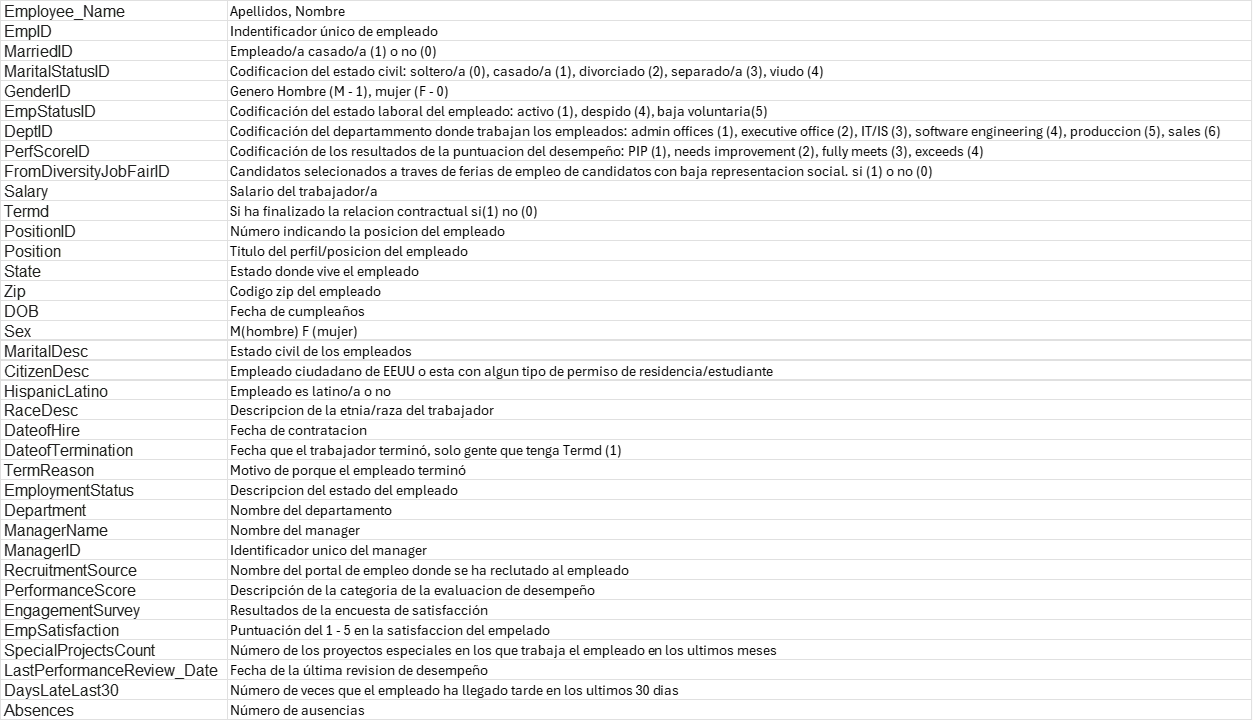


Muestra de los datos desde drive

In [ ]:
## código desde archivo subido a colab

hrdataset = pd.read_csv("HRDataset_v14.csv")
hrdataset.head()

,Employee_Name,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,...,ManagerName,ManagerID,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences
0,"Adinolfi, Wilson K",10026,0,0,1,1,5,4,0,62506,...,Michael Albert,22.0,LinkedIn,Exceeds,4.60,5,0,1/17/2019,0,1
1,"Ait Sidi, Karthikeyan",10084,1,1,1,5,3,3,0,104437,...,Simon Roup,4.0,Indeed,Fully Meets,4.96,3,6,2/24/2016,0,17
2,"Akinkuolie, Sarah",10196,1,1,0,5,5,3,0,64955,...,Kissy Sullivan,20.0,LinkedIn,Fully Meets,3.02,3,0,5/15/2012,0,3
3,"Alagbe,Trina",10088,1,1,0,1,5,3,0,64991,...,Elijiah Gray,16.0,Indeed,Fully Meets,4.84,5,0,1/3/2019,0,15
4,"Anderson, Carol",10069,0,2,0,5,5,3,0,50825,...,Webster Butler,39.0,Google Search,Fully Meets,5.00,4,0,2/1/2016,0,2


In [ ]:
# Cargamos y mostramos el dataset
#drive.mount('/content/drive')
#hrdataset = pd.read_csv('/content/drive/MyDrive/Data Science/Máster Data UCM/TFM/HRDataset_v14.csv')
#hrdataset.head()


# Análisis de los datos

In [ ]:
# Lista de columnas
hrdataset.columns

Index(['Employee_Name', 'EmpID', 'MarriedID', 'MaritalStatusID', 'GenderID',
       'EmpStatusID', 'DeptID', 'PerfScoreID', 'FromDiversityJobFairID',
       'Salary', 'Termd', 'PositionID', 'Position', 'State', 'Zip', 'DOB',
       'Sex', 'MaritalDesc', 'CitizenDesc', 'HispanicLatino', 'RaceDesc',
       'DateofHire', 'DateofTermination', 'TermReason', 'EmploymentStatus',
       'Department', 'ManagerName', 'ManagerID', 'RecruitmentSource',
       'PerformanceScore', 'EngagementSurvey', 'EmpSatisfaction',
       'SpecialProjectsCount', 'LastPerformanceReview_Date', 'DaysLateLast30',
       'Absences'],
      dtype='object')

In [ ]:
# Lista de variables del dataset

hrdataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 311 entries, 0 to 310
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Employee_Name               311 non-null    object 
 1   EmpID                       311 non-null    int64  
 2   MarriedID                   311 non-null    int64  
 3   MaritalStatusID             311 non-null    int64  
 4   GenderID                    311 non-null    int64  
 5   EmpStatusID                 311 non-null    int64  
 6   DeptID                      311 non-null    int64  
 7   PerfScoreID                 311 non-null    int64  
 8   FromDiversityJobFairID      311 non-null    int64  
 9   Salary                      311 non-null    int64  
 10  Termd                       311 non-null    int64  
 11  PositionID                  311 non-null    int64  
 12  Position                    311 non-null    object 
 13  State                       311 non

In [ ]:
# Estadisticas descriptivas de las variables numéricas

hrdataset.describe()

,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,Termd,PositionID,Zip,ManagerID,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,DaysLateLast30,Absences
count,311.000000,311.000000,311.000000,311.000000,311.000000,311.000000,311.000000,311.000000,311.000000,311.000000,311.000000,311.000000,303.000000,311.000000,311.000000,311.000000,311.000000,311.000000
mean,10156.000000,0.398714,0.810289,0.434084,2.392283,4.610932,2.977492,0.093248,69020.684887,0.334405,16.845659,6555.482315,14.570957,4.110000,3.890675,1.218650,0.414791,10.237942
std,89.922189,0.490423,0.943239,0.496435,1.794383,1.083487,0.587072,0.291248,25156.636930,0.472542,6.223419,16908.396884,8.078306,0.789938,0.909241,2.349421,1.294519,5.852596
min,10001.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,45046.000000,0.000000,1.000000,1013.000000,1.000000,1.120000,1.000000,0.000000,0.000000,1.000000
25%,10078.500000,0.000000,0.000000,0.000000,1.000000,5.000000,3.000000,0.000000,55501.500000,0.000000,18.000000,1901.500000,10.000000,3.690000,3.000000,0.000000,0.000000,5.000000
50%,10156.000000,0.000000,1.000000,0.000000,1.000000,5.000000,3.000000,0.000000,62810.000000,0.000000,19.000000,2132.000000,15.000000,4.280000,4.000000,0.000000,0.000000,10.000000
75%,10233.500000,1.000000,1.000000,1.000000,5.000000,5.000000,3.000000,0.000000,72036.000000,1.000000,20.000000,2355.000000,19.000000,4.700000,5.000000,0.000000,0.000000,15.000000
max,10311.000000,1.000000,4.000000,1.000000,5.000000,6.000000,4.000000,1.000000,250000.000000,1.000000,30.000000,98052.000000,39.000000,5.000000,5.000000,8.000000,6.000000,20.000000


In [ ]:
# Valores nulos

hrdataset.isnull().sum()

,0
Employee_Name,0
EmpID,0
MarriedID,0
MaritalStatusID,0
GenderID,0
EmpStatusID,0
DeptID,0
PerfScoreID,0
FromDiversityJobFairID,0
Salary,0


## Análisis por variables

###Genero  y sexo

   GenderID Sex  count
0         0   F    176
1         1  M     135


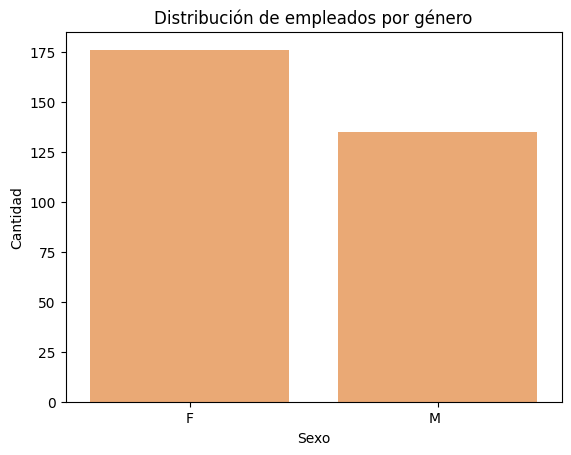

In [ ]:
# Agrupamos para ver frecuencias y asignación de valores
gender_counts = hrdataset.groupby(['GenderID', 'Sex']).size().reset_index(name='count')
print(gender_counts)

# Gráfico de barras
sns.barplot(x='Sex', y='count', data=gender_counts)

plt.title("Distribución de empleados por género")
plt.xlabel("Sexo")
plt.ylabel("Cantidad")
plt.show()

###Estado Civil

   MaritalStatusID MaritalDesc  count
0                0      Single    137
1                1     Married    124
2                2    Divorced     30
3                3   Separated     12
4                4     Widowed      8


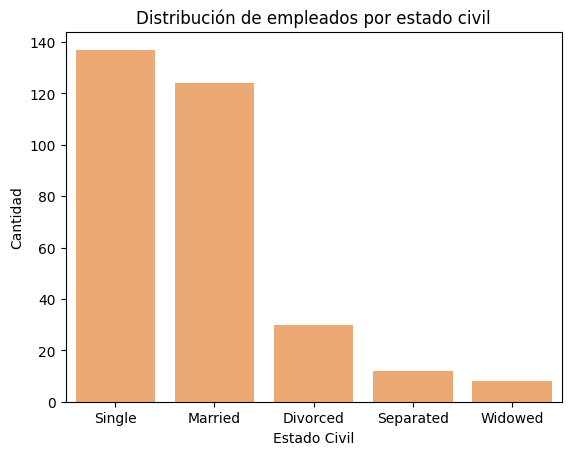

In [ ]:
# Agrupamos la variables de estado civil para ver frecuencias y asignacion de valores
marital_counts = hrdataset.groupby(['MaritalStatusID', 'MaritalDesc']).size().reset_index(name='count')
print(marital_counts)

# Gráfico de barras
sns.barplot(x='MaritalDesc', y='count', data=marital_counts)

plt.title("Distribución de empleados por estado civil")
plt.xlabel("Estado Civil")
plt.ylabel("Cantidad")
plt.show()

###Estado laboral del trabajador

In [ ]:
# Agrupamos las variables relacionadas con el estado del empleado para ver frecuencias y asignacion de valores
employment_counts = hrdataset.groupby(['EmpStatusID', 'EmploymentStatus']).size().reset_index(name='count')
print(employment_counts)


   EmpStatusID        EmploymentStatus  count
0            1                  Active    182
1            1    Terminated for Cause      2
2            2                  Active     11
3            3                  Active     14
4            4    Terminated for Cause     14
5            5  Voluntarily Terminated     88


In [ ]:
# Corregir la codificación de EmpStatusID
hrdataset.loc[(hrdataset['EmploymentStatus'] == 'Terminated for Cause') & (hrdataset['EmpStatusID'] == 1), 'EmpStatusID'] = 4

In [ ]:
# Comprobamos que los cambios en la variable se han realizado correctamente
hrdataset.groupby(['EmpStatusID', 'EmploymentStatus']).size().reset_index(name='count')

,EmpStatusID,EmploymentStatus,count
0,1,Active,182
1,2,Active,11
2,3,Active,14
3,4,Terminated for Cause,16
4,5,Voluntarily Terminated,88


   EmpStatusID        EmploymentStatus  count
0            1                  Active    207
1            4    Terminated for Cause     16
2            5  Voluntarily Terminated     88


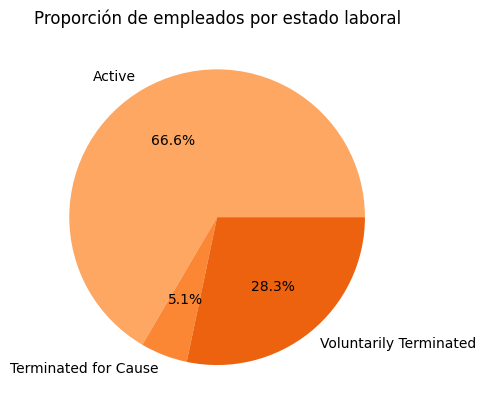

In [ ]:
# Agrupamos los activos en un solo valor
hrdataset.loc[hrdataset['EmploymentStatus'] == 'Active', 'EmpStatusID'] = 1

# Agrupamos las variables relacionadas con el estado del empleado para ver frecuencias y asignacion de valores
employment_counts_grouped = hrdataset.groupby(['EmpStatusID', 'EmploymentStatus']).size().reset_index(name='count')
print(employment_counts_grouped)

# Gráfico de tarta
plt.pie(employment_counts_grouped["count"], labels=employment_counts_grouped["EmploymentStatus"], autopct="%1.1f%%")
plt.title("Proporción de empleados por estado laboral")
plt.show()

De los 311 empleados que hay en el dataset 207 están activos ahora mismo y el 28% han terminado la relación laboral de manera voluntaria, esto se puede unir con la teoría nombrada anteriormente del final del proyecto y los trabajadores buscaron de manera externa un proyecto nuevo donde trabajar.

### Evaluación de desempeño

In [ ]:
# Agrupamos la variable de puntuacion de desempeño para ver frecuencias y asignacion de valores
perfmscore_counts = hrdataset.groupby(['PerfScoreID', 'PerformanceScore']).size().reset_index(name='count')
print(perfmscore_counts)

   PerfScoreID   PerformanceScore  count
0            1        Fully Meets      1
1            1                PIP     12
2            2  Needs Improvement     18
3            3        Fully Meets    242
4            3                PIP      1
5            4            Exceeds     37


Significado de los valores de la variables:
1.   PIP: nivel más bajo, desempeño crítico
2.   Needs Improvement: mejor que PIP, pero aún bajo lo esperado
3. Fully Meets: cumple con lo esperado, estándar
4. Exceeds: nivel más alto, supera expectativas

   PerfScoreID   PerformanceScore  count
0            1                PIP     13
1            2  Needs Improvement     18
2            3        Fully Meets    243
3            4            Exceeds     37


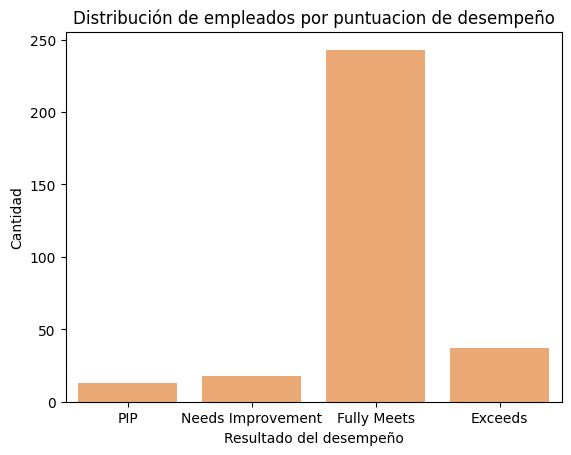

In [ ]:
# Diccionario de mapeo: PerformanceScore -> PerfScoreID correcto
perf_map = {
    'PIP': 1,
    'Needs Improvement': 2,
    'Fully Meets': 3,
    'Exceeds': 4
}

# Asignamos ese diccionario a la variable
hrdataset['PerfScoreID'] = hrdataset['PerformanceScore'].map(perf_map)

# Validamos el cambio
perfmscore_counts = hrdataset.groupby(['PerfScoreID', 'PerformanceScore']).size().reset_index(name='count')
print(perfmscore_counts)

# Gráfico de barras
sns.barplot(x='PerformanceScore', y='count', data=perfmscore_counts)

plt.title("Distribución de empleados por puntuacion de desempeño")
plt.xlabel("Resultado del desempeño")
plt.ylabel("Cantidad")
plt.show()


###Terminación de la relación laboral

In [ ]:
# Agrupamos la variable que indica si se ha terminado la relacion laboralpara ver frecuencias y asignacion de valores
term_counts = hrdataset.groupby(['Termd']).size().reset_index(name='count')
print(term_counts)

   Termd  count
0      0    207
1      1    104


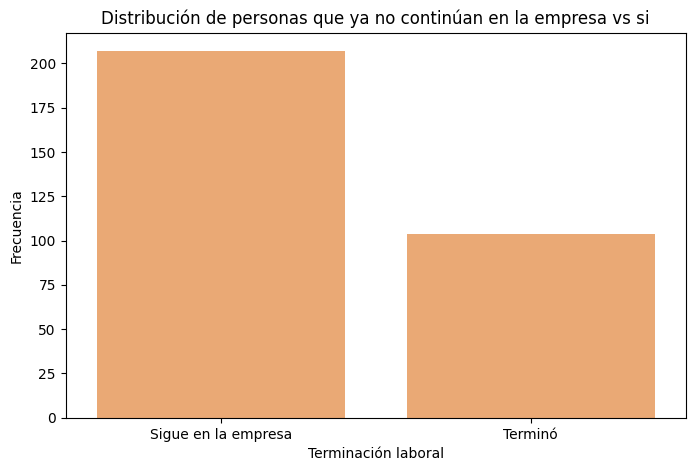

In [ ]:
# Histograma de frecuancias de rotación
plt.figure(figsize=(8,5))
sns.countplot(data=hrdataset, x='Termd')

# Cambiamos etiquetas del eje X
plt.xticks(ticks=[0,1], labels=["Sigue en la empresa", "Terminó"])

plt.title("Distribución de personas que ya no continúan en la empresa vs si")
plt.xlabel("Terminación laboral")
plt.ylabel("Frecuencia")
plt.show()

In [ ]:
# Teminaciones por año
hrdataset['YearTermination'] = pd.to_datetime(hrdataset['DateofTermination'], errors='coerce').dt.year
terminaciones_por_año = hrdataset[hrdataset['Termd'] == 1]['YearTermination'].value_counts().sort_index()
print(terminaciones_por_año)

YearTermination
2010.0     1
2011.0     3
2012.0     8
2013.0    13
2014.0    13
2015.0    23
2016.0    22
2017.0     8
2018.0    13
Name: count, dtype: int64


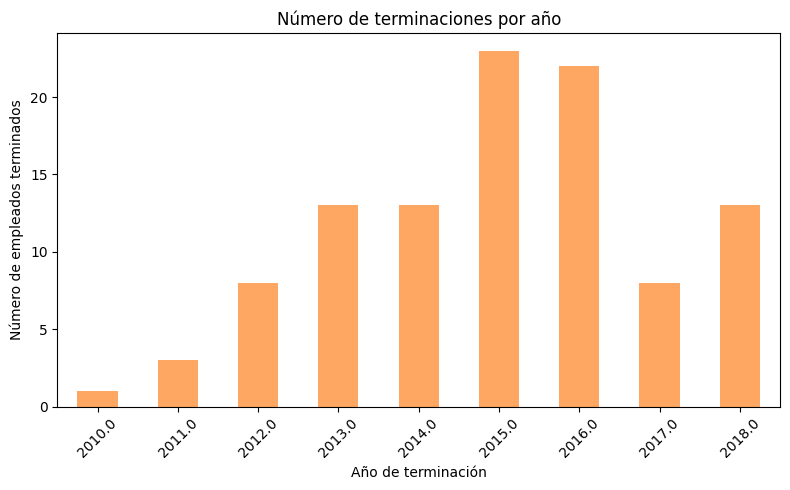

In [ ]:
# Grafico de terminaciones por año

plt.figure(figsize=(8,5))
terminaciones_por_año.plot(kind='bar')
plt.title("Número de terminaciones por año")
plt.xlabel("Año de terminación")
plt.ylabel("Número de empleados terminados")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Análisis de las variables con fecha

In [ ]:
# Formateamos la columna DOB a datetime
hrdataset['DOB'] = pd.to_datetime(
    hrdataset['DOB'],
    format='%m/%d/%y',   # mes/día/año con 2 dígitos en año
    errors='coerce'
)

# Corrección: si el año es mayor que 2025, restamos 100
hrdataset.loc[hrdataset['DOB'].dt.year > 2025, 'DOB'] = \
    hrdataset.loc[hrdataset['DOB'].dt.year > 2025, 'DOB'] - pd.DateOffset(years=100)


print(hrdataset['DOB'].head())

0   1983-07-10
1   1975-05-05
2   1988-09-19
3   1988-09-27
4   1989-09-08
Name: DOB, dtype: datetime64[ns]


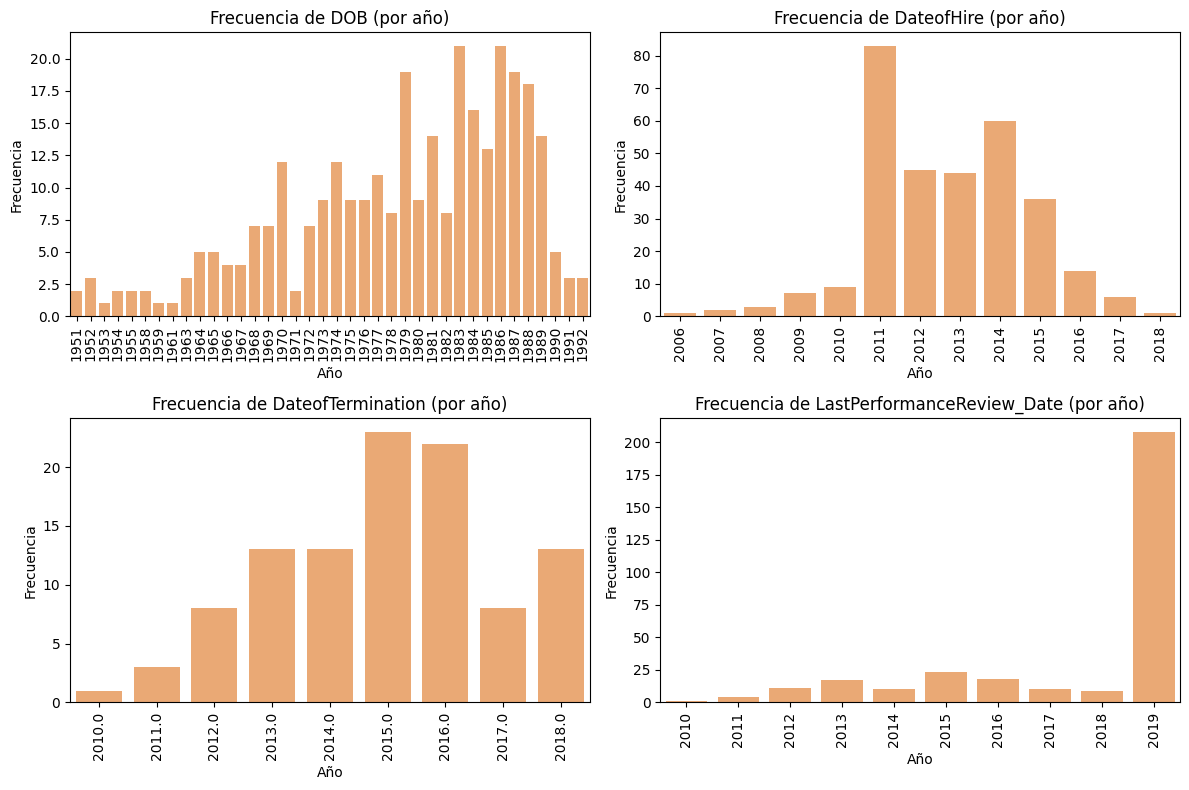

In [ ]:
# Genera 4 histofgramas de las variables indicadas en "columna"
columnas = ['DOB', 'DateofHire', 'DateofTermination', 'LastPerformanceReview_Date']

# Convertimos las columnas en datetime
for col in columnas:
    hrdataset[col] = pd.to_datetime(hrdataset[col], errors='coerce')

# Extraemos el año en nuevas columnas
for col in columnas:
    hrdataset[col + '_Year'] = hrdataset[col].dt.year

# Crear una figura con 2 filas y 2 columnas de gráficos
plt.figure(figsize=(12, 8))  # tamaño general

for i, col in enumerate(columnas, 1):
    plt.subplot(2, 2, i)  # 2x2 posición
    sns.countplot(data=hrdataset, x=col + '_Year', order=sorted(hrdataset[col + '_Year'].dropna().unique()))
    plt.title(f'Frecuencia de {col} (por año)')
    plt.xticks(rotation=90)
    plt.xlabel('Año')
    plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

### Edad y antigüedad

In [ ]:
# Creamos la variable edad
hrdataset["Edad"] = (pd.to_datetime("today") - hrdataset["DOB"]).dt.days // 365

#Creamos la variable antiguedad
hrdataset["Antiguedad"] = ((pd.to_datetime("today") - hrdataset["DateofHire"]).dt.days // 365).astype(float)

In [ ]:
hrdataset[["Edad", "Antiguedad"]].describe()

,Edad,Antiguedad
count,311.000000,311.000000
mean,46.183280,12.086817
std,8.863217,1.971291
min,33.000000,7.000000
25%,39.000000,10.500000
50%,44.000000,12.000000
75%,51.000000,14.000000
max,74.000000,19.000000


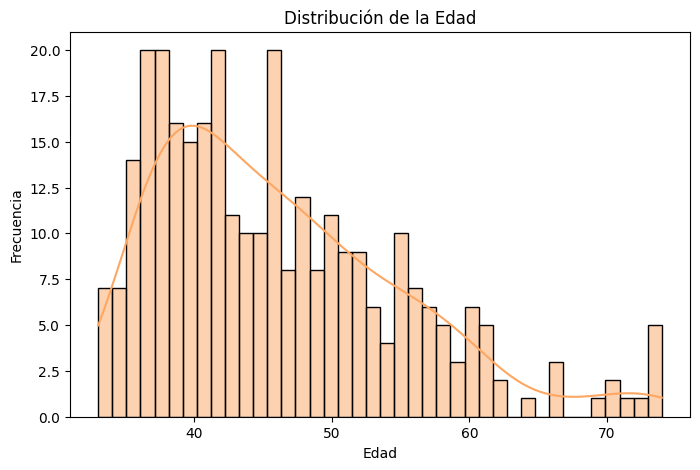

In [ ]:

# Graficamos la distribución por edad

plt.figure(figsize=(8,5))  # tamaño del gráfico
sns.histplot(data=hrdataset, x='Edad', bins=40, kde=True)
plt.title("Distribución de la Edad")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.show()

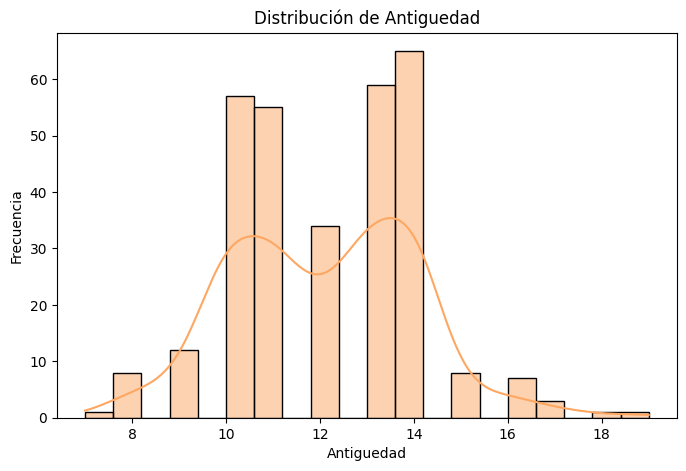

In [ ]:
# Histograma de la distribucion de frecuencias por la antigüedad

plt.figure(figsize=(8,5))  # tamaño del gráfico
sns.histplot(data=hrdataset, x='Antiguedad', bins=20, kde=True)
plt.title("Distribución de Antiguedad")
plt.xlabel("Antiguedad")
plt.ylabel("Frecuencia")
plt.show()

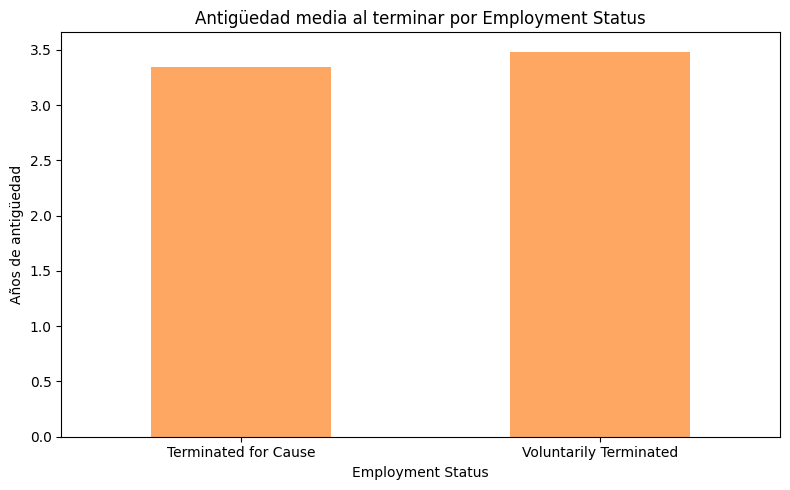

In [ ]:
# Histograma de antiguedad media por estado del empleado

# Filtrar empleados terminados
terminados = hrdataset[hrdataset['Termd'] == 1].copy()

# Calcular antigüedad (en años)
terminados['Termd'] = (terminados['DateofTermination'] - terminados['DateofHire']).dt.days / 365

# Media de antigüedad por status
tenure_por_status = terminados.groupby('EmploymentStatus')['Termd'].mean()

plt.figure(figsize=(8,5))
tenure_por_status.plot(kind='bar')
plt.title("Antigüedad media al terminar por Employment Status")
plt.xlabel("Employment Status")
plt.ylabel("Años de antigüedad")
plt.xticks(rotation=None)
plt.tight_layout()
plt.show()


El promedio de antigüedad (≈ 3-3.5 años) sugiere que la empresa enfrenta rotación relativamente temprana, independientemente de la causa.


### Departamento de pertenencia

In [ ]:
# Agrupamos la variables de departamento para ver frecuencias y asignacion de valores
department_counts = hrdataset.groupby(['DeptID', 'Department']).size().reset_index(name='count')
print(department_counts)



   DeptID            Department  count
0       1         Admin Offices      9
1       1  Software Engineering      1
2       2      Executive Office      1
3       3                 IT/IS     50
4       4  Software Engineering     10
5       5     Production           208
6       6     Production             1
7       6                 Sales     31


   DeptID            Department  count
0       1         Admin Offices      9
1       2      Executive Office      1
2       3                 IT/IS     50
3       4  Software Engineering     11
4       5            Production    209
5       6                 Sales     31


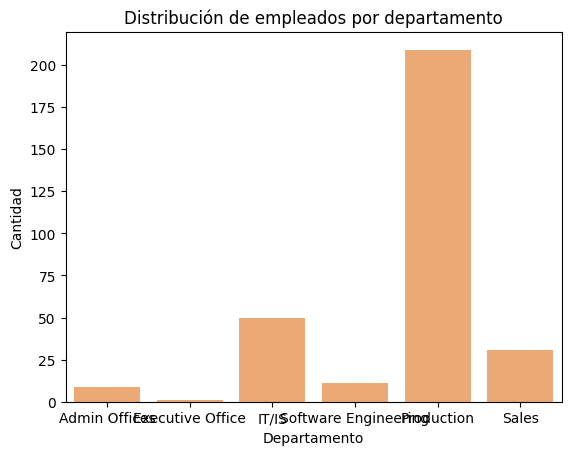

In [ ]:
# Modificacion de la variable para una mejor codificación

# Limpia los espacios de la columna Department

hrdataset["Department"] = hrdataset["Department"].str.strip()

# Creamos un diccionario de mapeo

dept_map = {
    'Admin Offices': 1,
    'Software Engineering': 4,
    'Executive Office': 2,
    'IT/IS': 3,
    'Production': 5,
    'Sales': 6
}

# Asignamos ese diccionario a la variable

hrdataset['DeptID'] = hrdataset['Department'].map(dept_map)


# Verificamos
dept_counts = hrdataset.groupby(['DeptID', 'Department']).size().reset_index(name='count')
print(dept_counts)


# Gráfico de barras
sns.barplot(x='Department', y='count', data=dept_counts)

plt.title("Distribución de empleados por departamento")
plt.xlabel("Departamento")
plt.xticks(rotation=None)
plt.ylabel("Cantidad")
plt.show()

In [ ]:
# Agrupado por posición, con media, mediana y desviación estándar
hrdataset.groupby("Department")[["Salary", "EngagementSurvey", "Antiguedad"]].agg(["mean", "median", "std"])

Salary                         EngagementSurvey  \
                               mean    median           std             mean   
Department                                                                     
Admin Offices          71791.888889   63003.0  21706.397164         4.393333   
Executive Office      250000.000000  250000.0           NaN         4.830000   
IT/IS                  97064.640000   92328.5  33209.612190         4.154000   
Production             59953.545455   59472.0  11422.656822         4.129569   
Sales                  69061.258065   65310.0  21271.393236         3.818710   
Software Engineering   94989.454545   95660.0   9566.505698         4.061818   

                                      Antiguedad                   
                     median       std       mean median       std  
Department                                                         
Admin Offices          4.50  0.660984  11.666667   10.0  2.692582  
Executive Office       4.83       NaN  13.000000   13.0       NaN  
IT/IS                  4.30  0.778187  10.340000   10.0  1.813892  
Production             4.24  0.764478  12.502392   13.0  1.776244  
Sales                  4.10  0.952791  12.129032   12.0  1.978921  
Software Engineering   4.20  0.860428  12.272727   12.0  1.420627

In [ ]:
# Ignoramos Executive Office porque es solo referido a una persona

hrdataset["Department_sinExec"] = hrdataset["Department"].replace("Executive Office", np.nan)

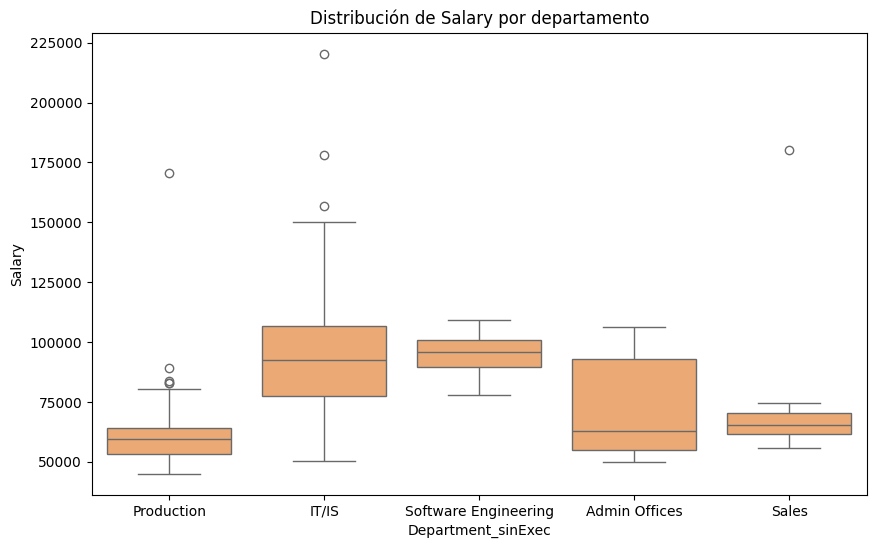

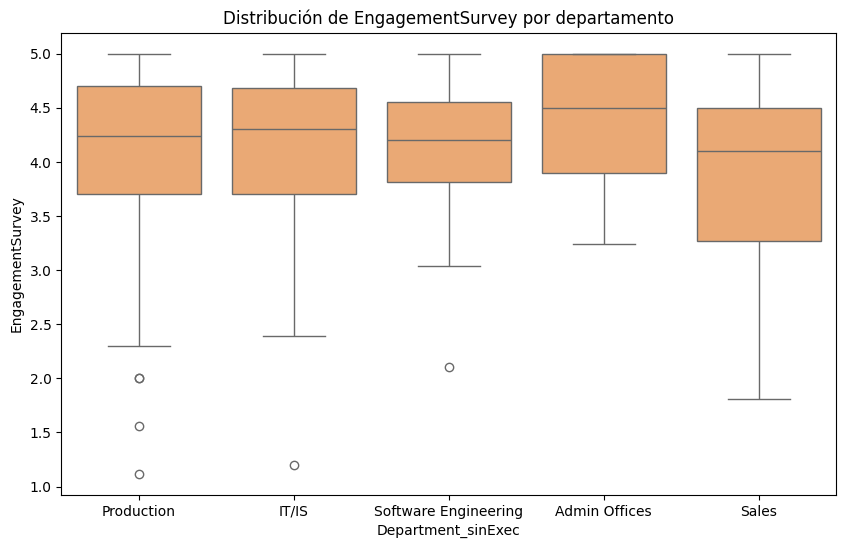

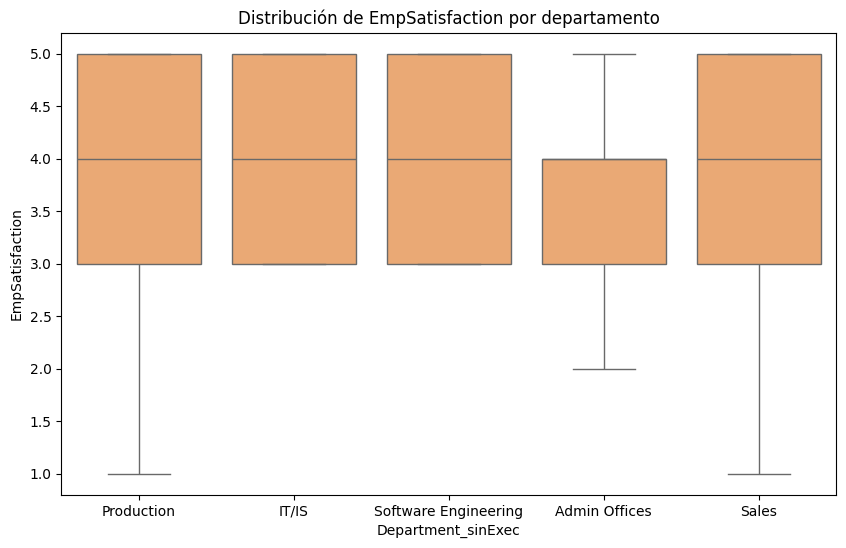

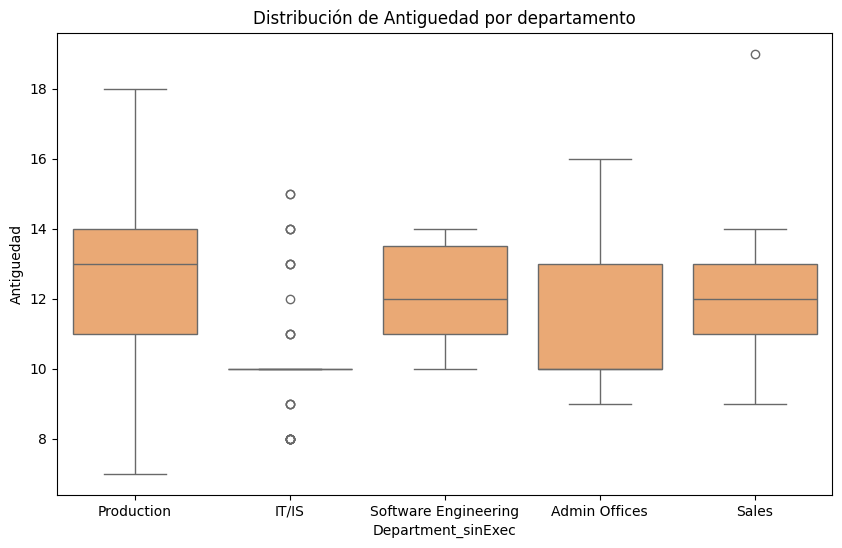

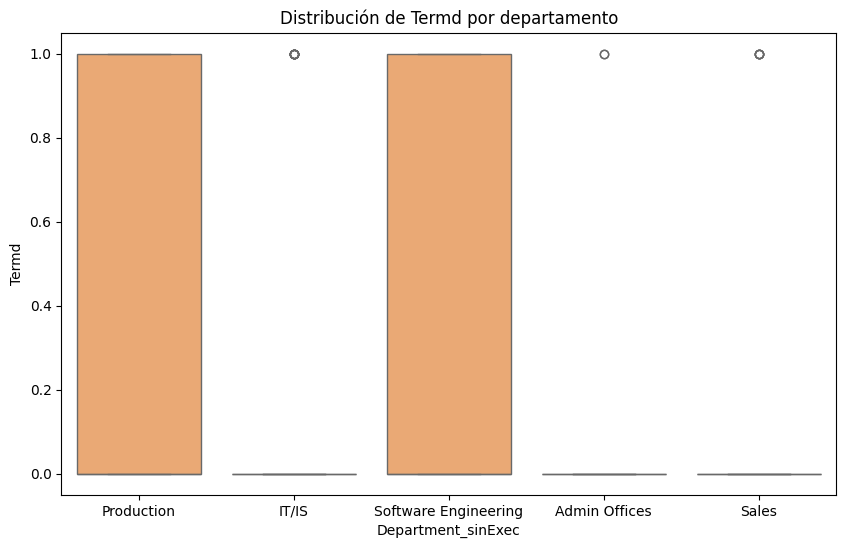

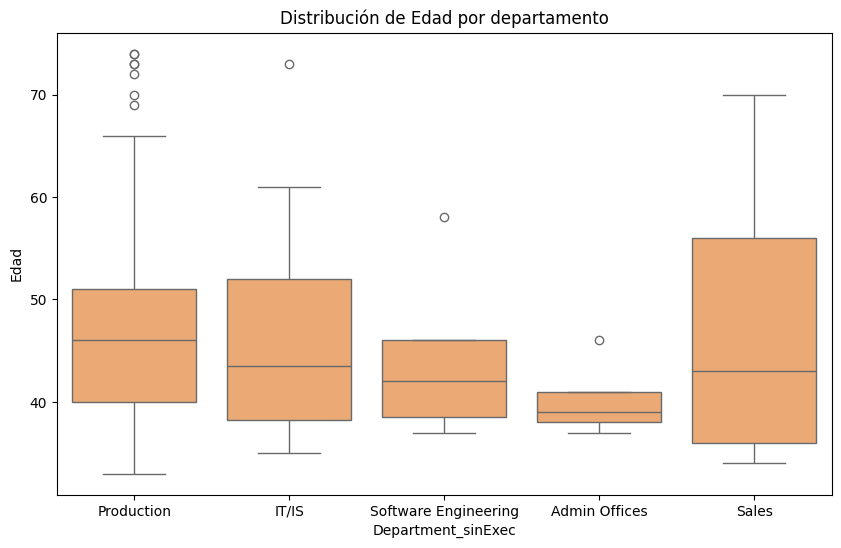

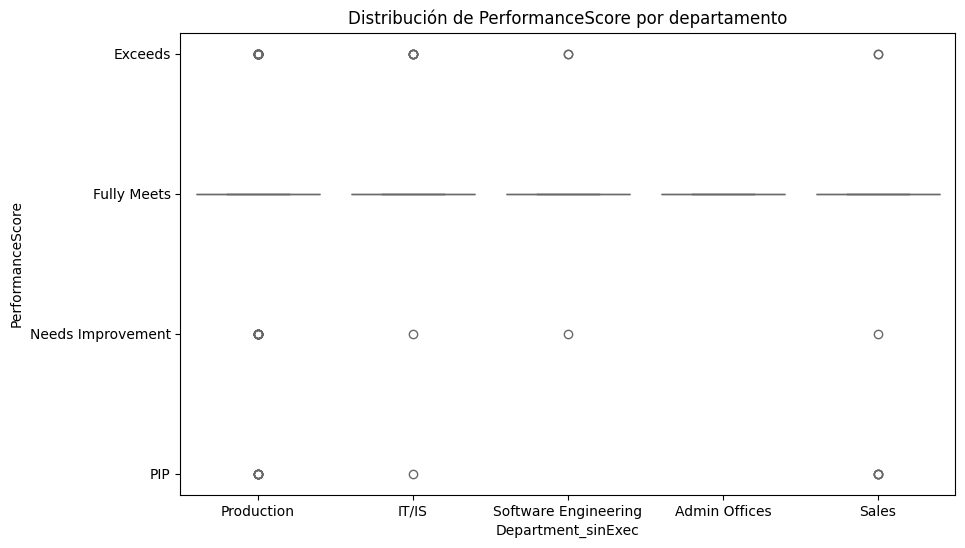

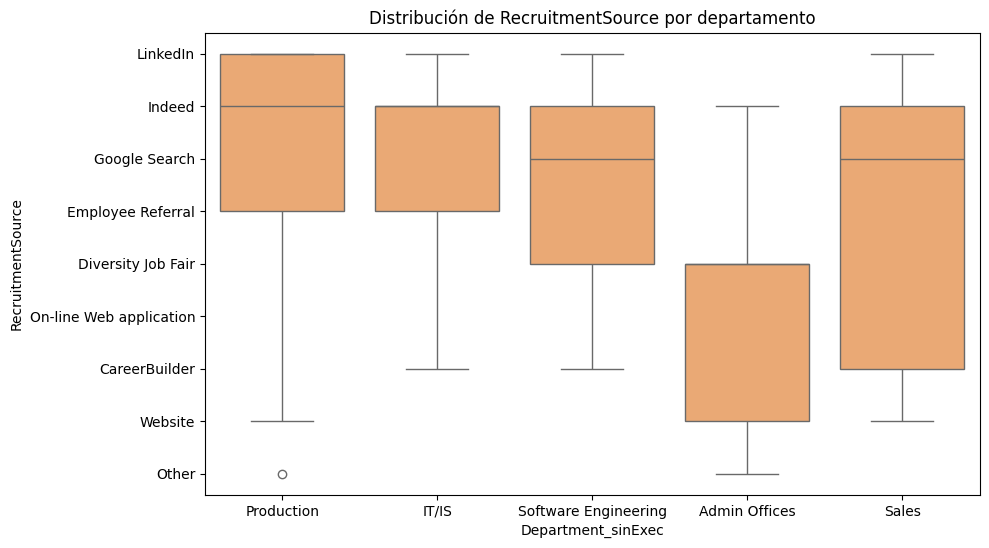

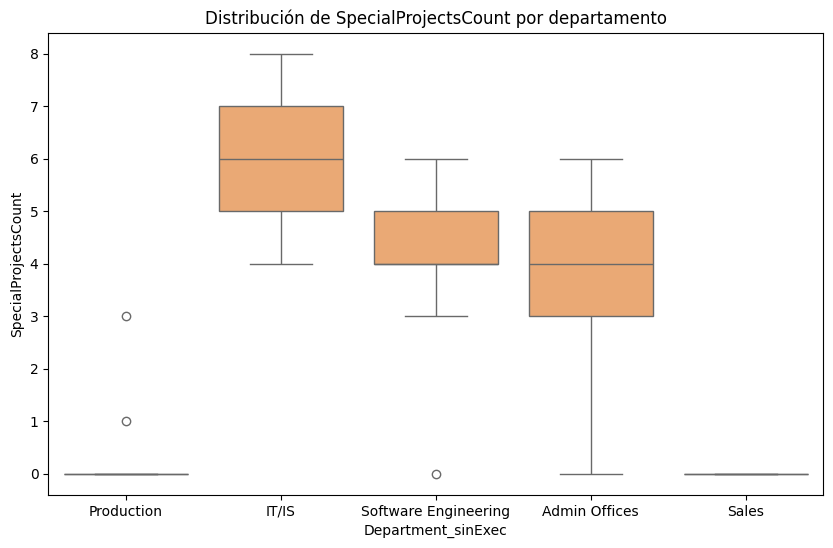

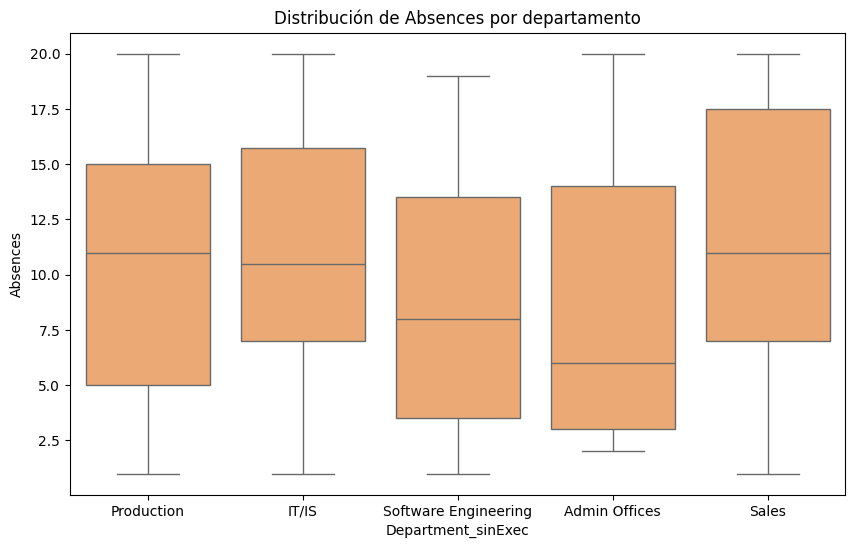

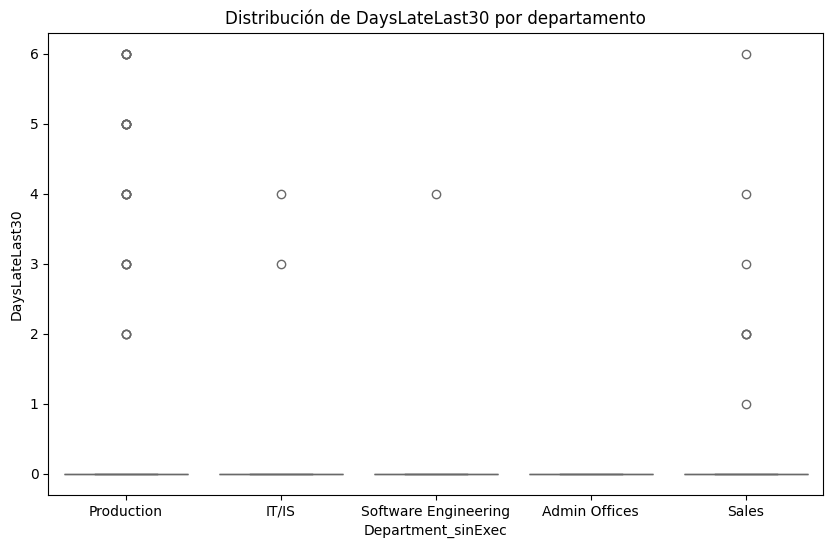

In [ ]:
# Boxplot para comparacion de distribuciones
for var in ["Salary",
            "EngagementSurvey", "EmpSatisfaction",
            "Antiguedad", "Termd", "Edad",
            "PerformanceScore", "RecruitmentSource",
            "SpecialProjectsCount",
            "Absences", "DaysLateLast30"
            ]:
    plt.figure(figsize=(10,6))
    sns.boxplot(x="Department_sinExec", y=var, data=hrdataset)
    plt.title(f"Distribución de {var} por departamento")
    plt.xticks(rotation=None)
    plt.show()

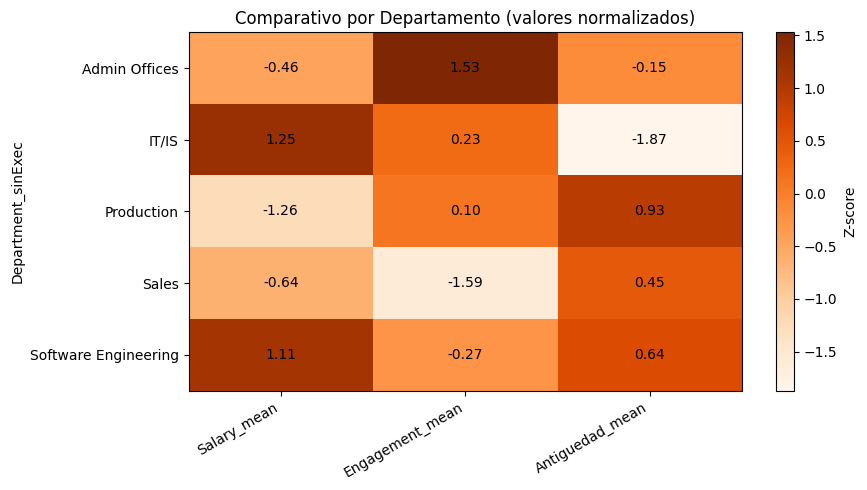

In [ ]:
# --- 1) Agregar medias por departamento ---
# Usa tu dataframe original: hr[["Department","Salary","EngagementSurvey","Antiguedad"]]
dept_mean = (
    hrdataset.groupby("Department_sinExec", as_index=True)[["Salary","EngagementSurvey","Antiguedad"]]
      .mean()
      .rename(columns={
          "Salary": "Salary_mean",
          "EngagementSurvey": "Engagement_mean",
          "Antiguedad": "Antiguedad_mean"
      })
      .sort_index()
)

# --- 2) Normalizar (z-score) por columna para comparar en la misma escala ---
df = dept_mean.copy()
df_norm = (df - df.mean()) / df.std(ddof=0)   # ddof=0 para población; usa 1 si prefieres muestra

# --- 3) Heatmap con matplotlib ---
fig, ax = plt.subplots(figsize=(9, 5))

im = ax.imshow(df_norm.values, aspect="auto", cmap="Oranges")
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Z-score")

# Etiquetas de ejes
ax.set_xticks(np.arange(df_norm.shape[1]))
ax.set_yticks(np.arange(df_norm.shape[0]))
ax.set_xticklabels(df_norm.columns, rotation=30, ha="right")
ax.set_yticklabels(df_norm.index)

ax.set_title("Comparativo por Departamento (valores normalizados)")
ax.set_xlabel("")
ax.set_ylabel("Department_sinExec")

# --- 4) Anotar valores en cada celda (redondeados) ---
for i in range(df_norm.shape[0]):
    for j in range(df_norm.shape[1]):
        ax.text(j, i, f"{df_norm.iat[i, j]:.2f}", va="center", ha="center")

plt.tight_layout()
plt.show()

In [ ]:
# 3. ANOVA para ver si hay diferencias significativas
for var in ["Salary",
            "EngagementSurvey", "EmpSatisfaction",
            "Antiguedad", "Termd",
            "GenderID" , "Edad",
            "SpecialProjectsCount",
            "Absences", "DaysLateLast30"
            ]:
    groups = [g[var].dropna().values for _, g in hrdataset.groupby("Department_sinExec")]
    f_stat, p_val = stats.f_oneway(*groups)
    print(f"{var}: F={f_stat:.3f}, p-value={p_val:.4f}")


Salary: F=48.989, p-value=0.0000
EngagementSurvey: F=1.431, p-value=0.2236
EmpSatisfaction: F=0.751, p-value=0.5579
Antiguedad: F=14.351, p-value=0.0000
Termd: F=3.192, p-value=0.0137
GenderID: F=1.408, p-value=0.2310
Edad: F=1.910, p-value=0.1086
SpecialProjectsCount: F=1139.345, p-value=0.0000
Absences: F=0.758, p-value=0.5536
DaysLateLast30: F=1.134, p-value=0.3406


Solo el salario, edad y numero de proyectos especiales muestran difeencias significativas.   
         
Como es normal, el salario muestra diferencias significativas por departamento     
La edad tambien, pero con un efecto moderado.     
El departamento es determinante para el numero de proyectos especiales que desarrollan los empleados

In [ ]:
# 4. Correlación con variables dummies
dummies = pd.get_dummies(hrdataset["Department"], drop_first=True)
corrs = {}
for var in ["Salary",
            "EngagementSurvey", "EmpSatisfaction",
            "Antiguedad", "Termd",
            "GenderID" , "Edad",
            "SpecialProjectsCount",
            "Absences", "DaysLateLast30"
            ]:
    corrs[var] = dummies.corrwith(hrdataset[var])

corrs_df = pd.DataFrame(corrs)
print("\nCorrelaciones departamento vs variables numéricas:")
print(corrs_df)


Correlaciones departamento vs variables numéricas:
                        Salary  EngagementSurvey  EmpSatisfaction  Antiguedad  \
Executive Office      0.409256          0.051851        -0.055726    0.026353   
IT/IS                 0.488709          0.024419         0.033425   -0.388473   
Production           -0.516761          0.035519        -0.046409    0.302254   
Sales                 0.000538         -0.122895         0.051896    0.007137   
Software Engineering  0.197986         -0.011698         0.042237    0.018088   

                         Termd  GenderID      Edad  SpecialProjectsCount  \
Executive Office     -0.040258 -0.049743  0.159284             -0.029508   
IT/IS                -0.124692  0.111195 -0.038743              0.877255   
Production            0.190312 -0.106728  0.078710             -0.732008   
Sales                -0.122094  0.055080  0.008877             -0.172870   
Software Engineering  0.011864  0.007905 -0.070851              0.241897   

    

EN reacion con lo visto en el analisis de ANOVA:     
El salario varía mucho por departamento teniendo el de produccion una correlación negativa, trabajar en el departamento de producción se asocia con salarios mas bajos.       En contraposicion con el departamento de IT/IS y Executive Office que la correlacion es positiva, estas posiciones se asocian a salarios mas altos.     
Hay cierto sesgo de genero segun la posición, as hombres en IT/IS y mas mujeres en producción.     
Por último podemos ver una correlacion muy alta y positiva en proyectos especiales que se concentran mas en el departamento de IT/IS (0.877) seguido de Software Engieneer (0.242) que es una relacion moderada y una correlacion negativa muy fuerte en el departamento de producción lo cual nos hace saber que en este departamento no participa en proyectos especiales.

### Posición (perfil profesional)

In [ ]:
# Eliminamos espacios al principio y al final
hrdataset['Position'] = hrdataset['Position'].str.strip()

# Asignamos el numero 24 a la posicion software engineer
mapeo = {'Software Engineer': 24}

# Lo corregimos en la base de datos
hrdataset.loc[hrdataset['Position'].isin(mapeo.keys()), 'PositionID'] = hrdataset['Position'].map(mapeo)

# Agrupamos la variable puesto de trabajo para ver frecuencias y asignacion de valores
position_counts = hrdataset.groupby(['PositionID', 'Position']).size().reset_index(name='count')
print(position_counts)


    PositionID                      Position  count
0            1                  Accountant I      3
1            2      Administrative Assistant      3
2            3            Area Sales Manager     27
3            4                  BI Developer      4
4            5                   BI Director      1
5            6                           CIO      1
6            7                Data Architect      1
7            8        Database Administrator      5
8            9                  Data Analyst      8
9           10        Director of Operations      1
10          11             Director of Sales      1
11          12                   IT Director      1
12          13               IT Manager - DB      2
13          13            IT Manager - Infra      1
14          13          IT Manager - Support      1
15          14                    IT Support      8
16          15              Network Engineer      5
17          16               President & CEO      1
18          

Vemos que hay una alta cardinalidad y a la hora de entrenar los modelos no nos va a ayudar.   

Agruparemos los valores por la funcionalidad de la posición.

In [ ]:
# Diccionario de mapeo: Position -> Funcionalidad
position_map = {
    # --- Producción / Operativos ---
    "Production Technician I": "Producción",
    "Production Technician II": "Producción",
    "Production Manager": "Producción",

    # --- Ventas / Comercial ---
    "Sales Manager": "Ventas",
    "Area Sales Manager": "Ventas",
    "Director of Sales": "Ventas",

    # --- Administración / Finanzas / Soporte ---
    "Administrative Assistant": "Administración",
    "Accountant I": "Administración",
    "Sr. Accountant": "Administración",

    # --- Tecnología / Ingeniería ---
    "Software Engineer": "Tecnología",
    "Software Engineering Manager": "Tecnología",
    "IT Support": "Tecnología",
    "Network Engineer": "Tecnología",
    "Sr. Network Engineer": "Tecnología",
    "IT Manager - DB": "Tecnología",
    "IT Manager - Infra": "Tecnología",
    "IT Manager - Support": "Tecnología",
    "IT Director": "Tecnología",
    "CIO": "Tecnología",

    # --- Datos / BI ---
    "Data Analyst": "Datos/BI",
    "BI Developer": "Datos/BI",
    "Senior BI Developer": "Datos/BI",
    "BI Director": "Datos/BI",
    "Data Architect": "Datos/BI",
    "Principal Data Architect": "Datos/BI",
    "Database Administrator": "Datos/BI",
    "Sr. DBA": "Datos/BI",
    "Enterprise Architect": "Datos/BI",

    # --- Dirección / Alta Gerencia ---
    "Director of Operations": "Dirección",
    "President & CEO": "Dirección",
    "Shared Services Manager": "Dirección",
}

In [ ]:
# Crear nueva columna con la funcionalidad
hrdataset["PositionGroup"] = hrdataset["Position"].map(position_map)

# Si hay valores no mapeados, se quedarán como NaN
# Puedes reemplazarlos por "Otro"
hrdataset["PositionGroup"] = hrdataset["PositionGroup"].fillna("Otro")

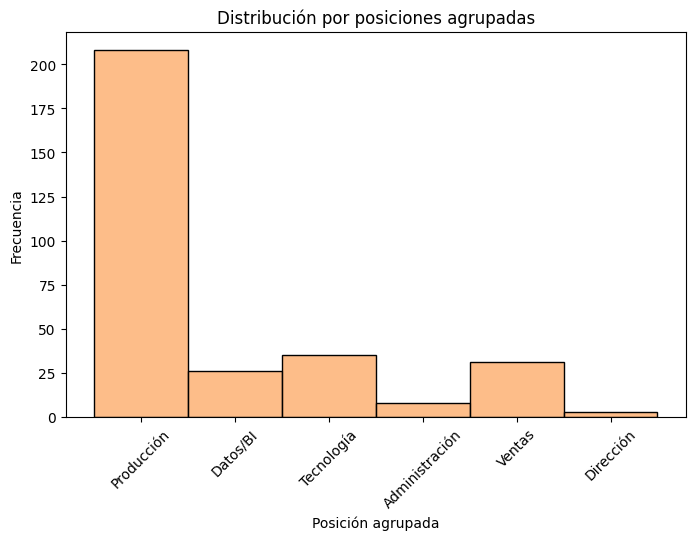

In [ ]:
# Histograma de la distribucion de frecuencias por la antiguedad

plt.figure(figsize=(8,5))  # tamaño del gráfico
sns.histplot(data=hrdataset, x='PositionGroup', bins=30)
plt.title("Distribución por posiciones agrupadas")
plt.xlabel("Posición agrupada")
plt.xticks(rotation=45)
plt.ylabel("Frecuencia")
plt.show()

In [ ]:
# Agrupado por posición, con media, mediana y desviación estándar
hrdataset.groupby("PositionGroup")[["Salary", "EngagementSurvey", "Antiguedad"]].agg(["mean", "median", "std"])

Salary                         EngagementSurvey         \
                         mean    median           std             mean median   
PositionGroup                                                                   
Administración   69135.125000   63001.5  21584.177501         4.430000  4.750   
Datos/BI         99466.192308   96370.0  14669.111551         4.184615  4.305   
Dirección       171182.000000  170500.0  78479.222550         4.210000  4.100   
Producción       59422.072115   59420.5   8472.736435         4.131635  4.245   
Tecnología       94628.428571   87565.0  38065.862179         4.102286  4.300   
Ventas           69061.258065   65310.0  21271.393236         3.818710  4.100   

                         Antiguedad                   
                     std       mean median       std  
PositionGroup                                         
Administración  0.696768  12.000000   10.5  2.672612  
Datos/BI        0.625468   9.384615   10.0  1.022817  
Dirección       0.572975  12.666667   13.0  3.511885  
Producción      0.765737  12.485577   13.0  1.763775  
Tecnología      0.895607  11.657143   11.0  1.814044  
Ventas          0.952791  12.129032   12.0  1.978921

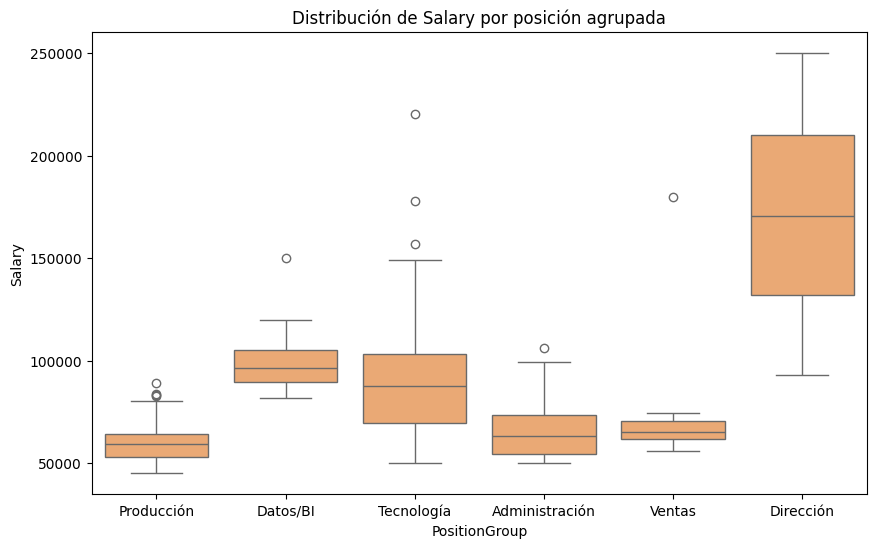

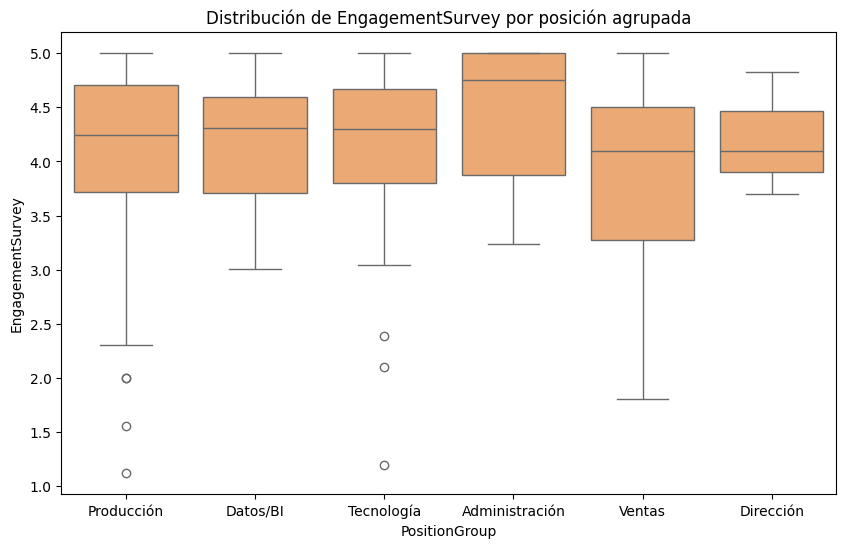

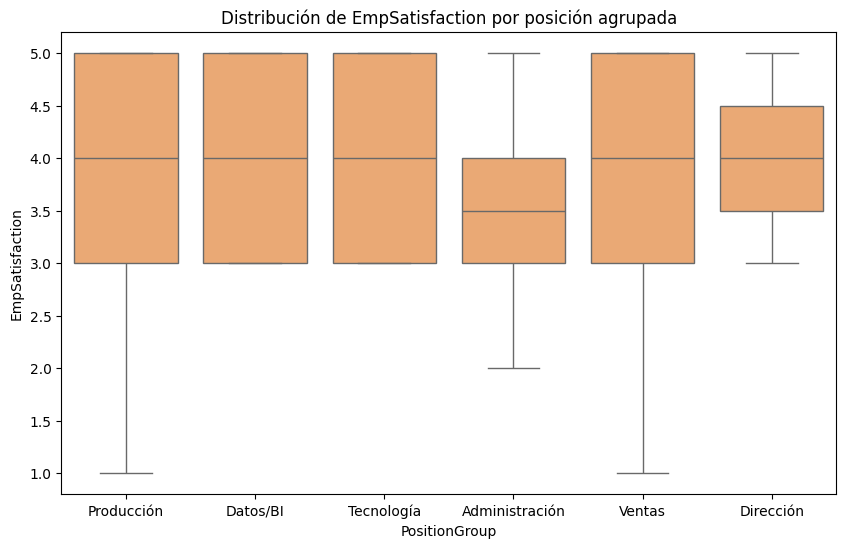

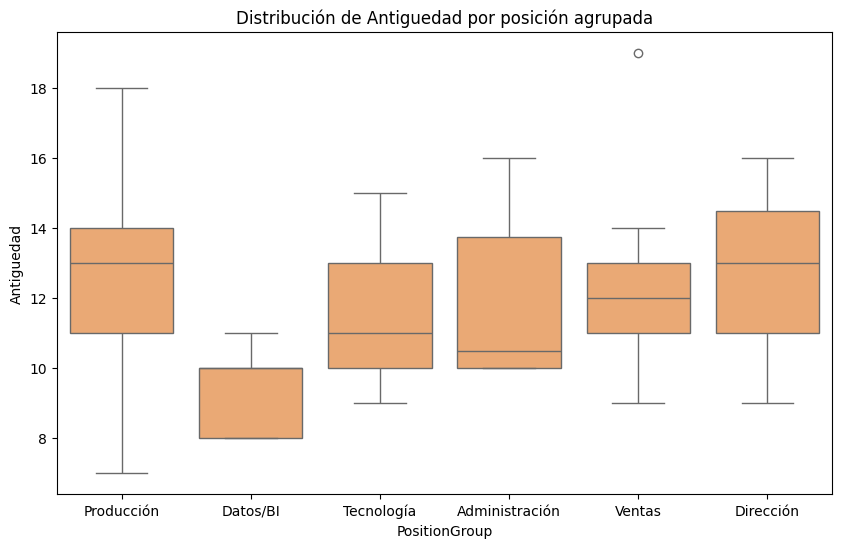

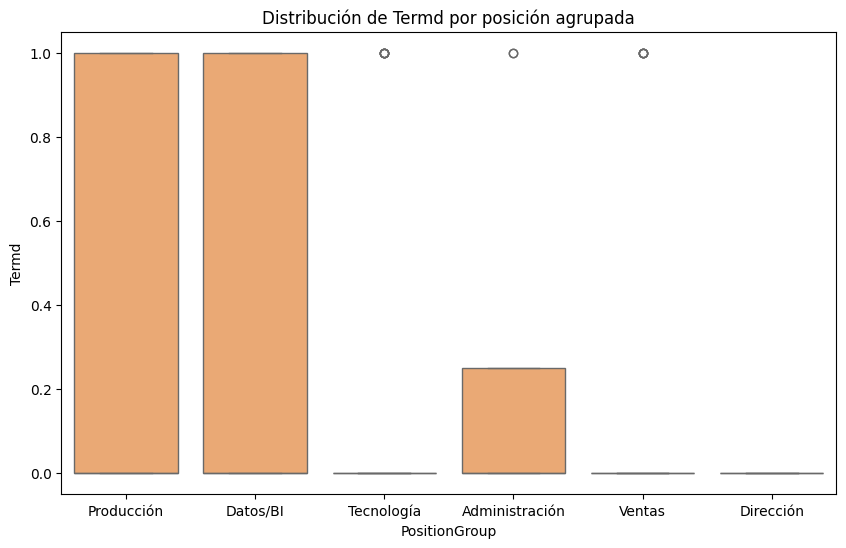

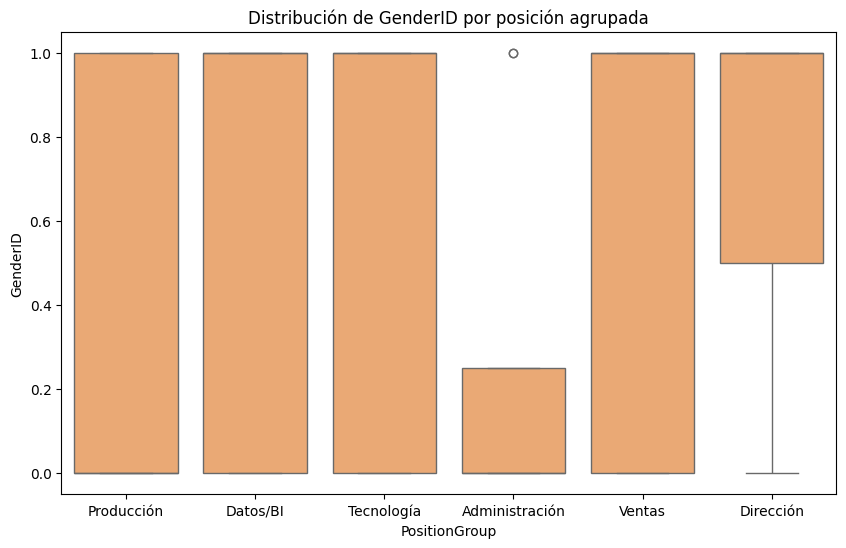

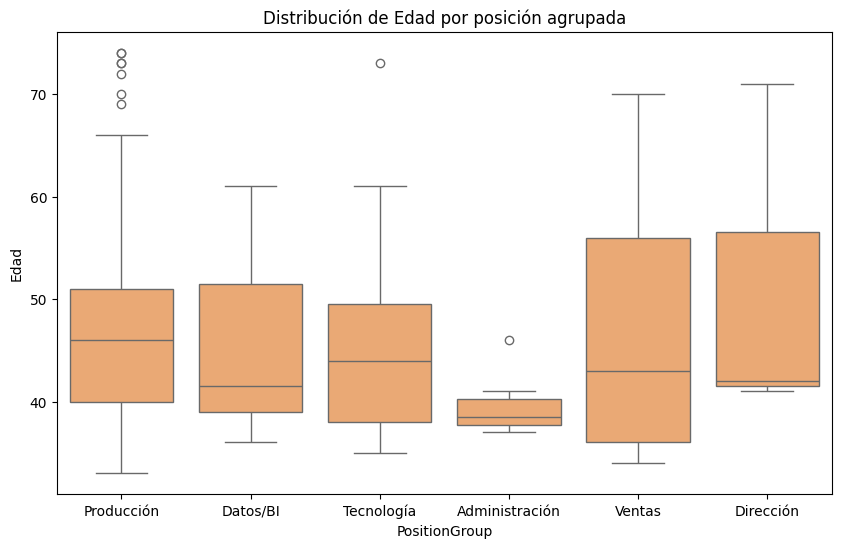

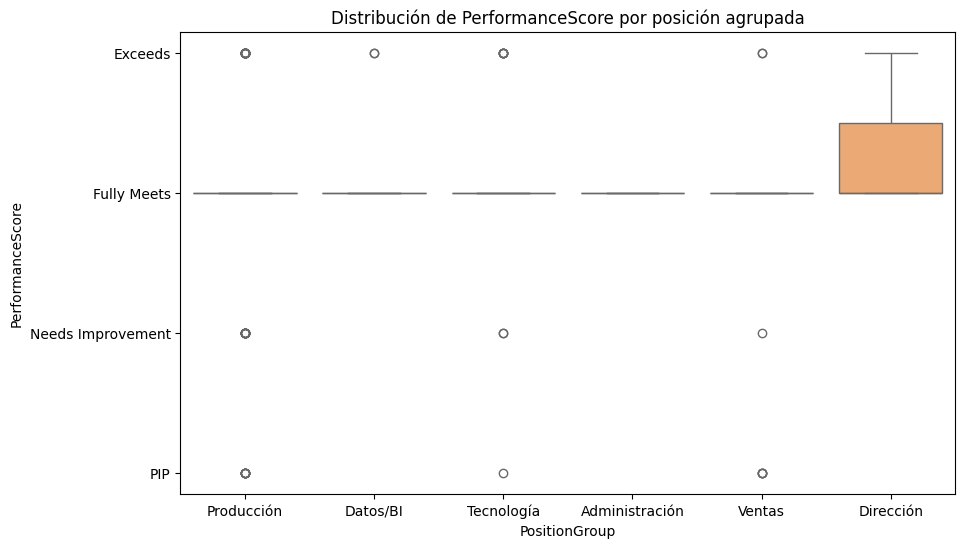

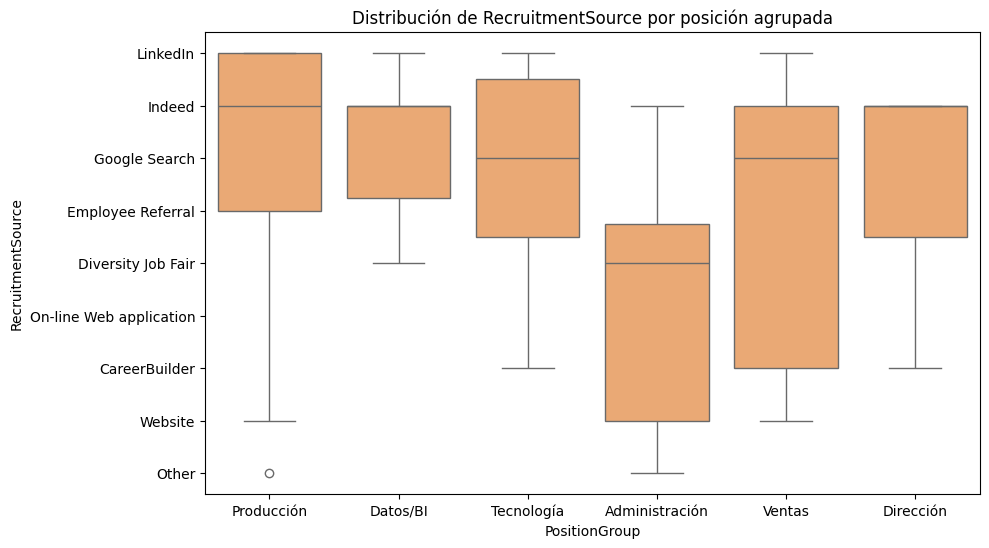

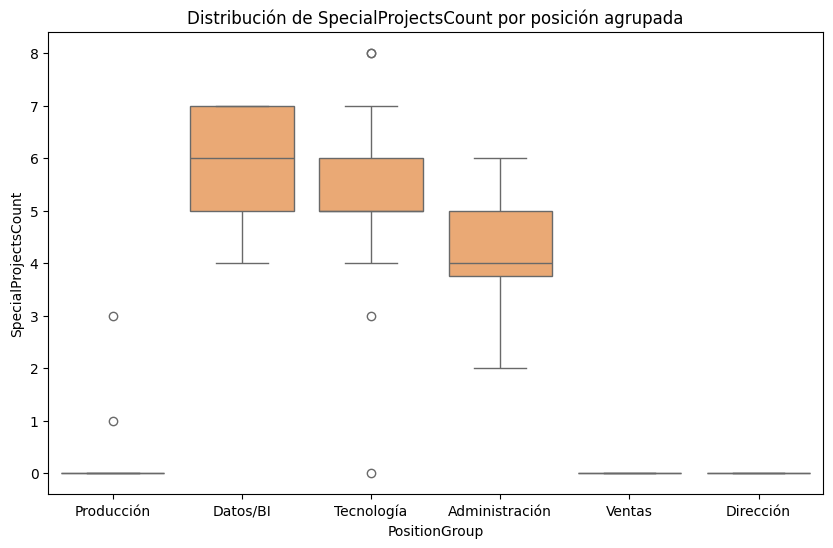

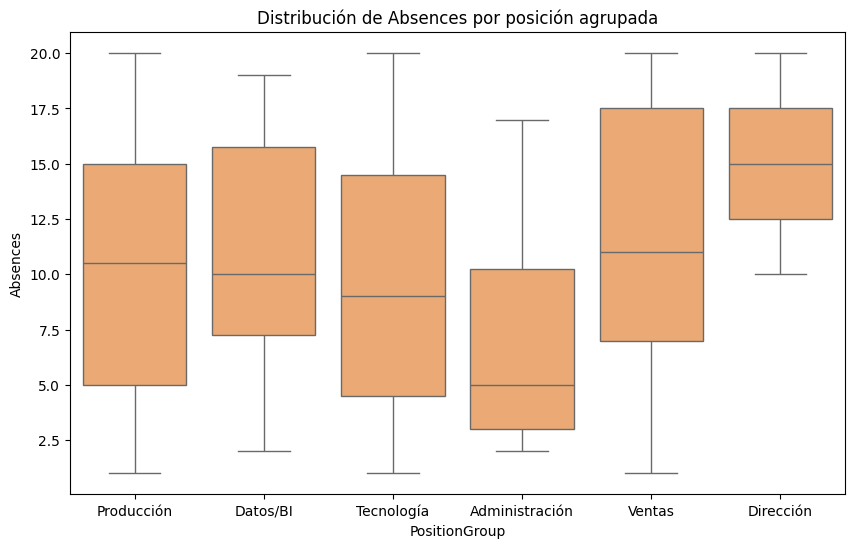

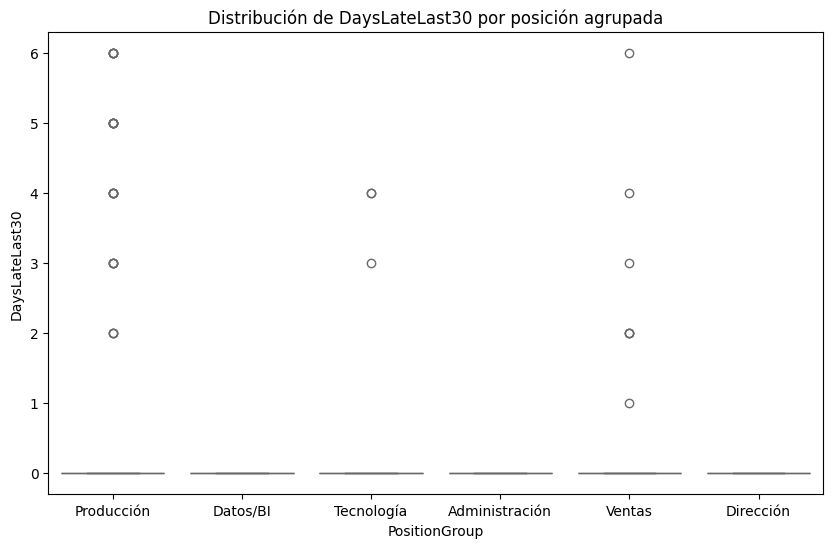

In [ ]:
# Boxplot para comparacion de distribuciones
for var in ["Salary",
            "EngagementSurvey", "EmpSatisfaction",
            "Antiguedad", "Termd",
            "GenderID" , "Edad",
            "PerformanceScore", "RecruitmentSource",
            "SpecialProjectsCount",
            "Absences", "DaysLateLast30"
            ]:
    plt.figure(figsize=(10,6))
    sns.boxplot(x="PositionGroup", y=var, data=hrdataset)
    plt.title(f"Distribución de {var} por posición agrupada")
    plt.xticks(rotation=None)
    plt.show()

In [ ]:
# 3. ANOVA para ver si hay diferencias significativas
for var in ["Salary",
            "EngagementSurvey", "EmpSatisfaction",
            "Antiguedad", "Termd",
            "GenderID" , "Edad",
            "SpecialProjectsCount",
            "Absences", "DaysLateLast30"
            ]:
    groups = [g[var].dropna().values for _, g in hrdataset.groupby("PositionGroup")]
    f_stat, p_val = stats.f_oneway(*groups)
    print(f"{var}: F={f_stat:.3f}, p-value={p_val:.4f}")


Salary: F=60.300, p-value=0.0000
EngagementSurvey: F=1.197, p-value=0.3104
EmpSatisfaction: F=0.680, p-value=0.6391
Antiguedad: F=14.434, p-value=0.0000
Termd: F=2.897, p-value=0.0143
GenderID: F=1.363, p-value=0.2381
Edad: F=1.545, p-value=0.1755
SpecialProjectsCount: F=857.463, p-value=0.0000
Absences: F=1.161, p-value=0.3282
DaysLateLast30: F=1.079, p-value=0.3722


El salario, la antiguedad, la rotacion y el numero de proyectos tienen dependencias significativas con la posición.     
Algunos de los grupos de posición concentran empleados mas antiguos y otros con menos antiguedad.    
La probalbilidad de rotacion camio segun el grupo de posición.    
Por último, la pertenecia a un grupo de posición determina casi por completo cuantos proyectos especiales gestiona un empleado


In [ ]:
# ¿pasaria lo mismo si no agrupamos la posicion?
for var in ["Salary",
            "EngagementSurvey", "EmpSatisfaction",
            "Antiguedad", "Termd",
            "GenderID" , "Edad",
            "SpecialProjectsCount",
            "Absences", "DaysLateLast30"
            ]:
    groups = [g[var].dropna().values for _, g in hrdataset.groupby("Position")]
    f_stat, p_val = stats.f_oneway(*groups)
    print(f"{var}: F={f_stat:.3f}, p-value={p_val:.4f}")

Salary: F=159.517, p-value=0.0000
EngagementSurvey: F=0.854, p-value=0.6898
EmpSatisfaction: F=0.992, p-value=0.4830
Antiguedad: F=3.803, p-value=0.0000
Termd: F=1.213, p-value=0.2114
GenderID: F=1.093, p-value=0.3439
Edad: F=1.536, p-value=0.0407
SpecialProjectsCount: F=210.976, p-value=0.0000
Absences: F=0.831, p-value=0.7218
DaysLateLast30: F=0.521, p-value=0.9832


Anova detecta las diferencias cuando hay mas cardinalidad.      
Sin agrupar las posiciones la rotacion deja de ser importante pero si la edad.      
Pero sigue coincidiendo las relaciones fuertes entre salario, antiguedad y numero de proyectos especiales con la posicion en la que se encuentran el trabajador


In [ ]:
# 4. Correlación con variables dummies
dummies = pd.get_dummies(hrdataset["PositionGroup"], drop_first=True)
corrs = {}
for var in ["Salary",
            "EngagementSurvey", "EmpSatisfaction",
            "Antiguedad", "Termd",
            "GenderID" , "Edad",
            "SpecialProjectsCount",
            "Absences", "DaysLateLast30"
            ]:
    corrs[var] = dummies.corrwith(hrdataset[var])

corrs_df = pd.DataFrame(corrs)
print("\nCorrelaciones posición agrupada vs variables numéricas:")
print(corrs_df)


Correlaciones posición agrupada vs variables numéricas:
              Salary  EngagementSurvey  EmpSatisfaction  Antiguedad     Termd  \
Datos/BI    0.366129          0.028576         0.010781   -0.414697 -0.017102   
Dirección   0.401438          0.012514         0.011886    0.029077 -0.069955   
Producción -0.543086          0.038982        -0.054643    0.287921  0.194683   
Tecnología  0.363076         -0.003483         0.054094   -0.077744 -0.123016   
Ventas      0.000538         -0.122895         0.051896    0.007137 -0.122094   

            GenderID      Edad  SpecialProjectsCount  Absences  DaysLateLast30  
Datos/BI    0.063608 -0.062706              0.610725  0.005594       -0.096936  
Dirección   0.046313  0.057439             -0.051275  0.080432       -0.031674  
Producción -0.114264  0.081745             -0.726645 -0.028637        0.061972  
Tecnología  0.078152 -0.031521              0.626121 -0.016242       -0.027692  
Ventas      0.055080  0.008877             -0.17287

Variables con diferencias claras por grupos de posición:

Hay salarios más bajos en Producción, más altos en Dirección/Tech/BI.

El numero de proymuy coectos especiales esta concentrado en Tecnología y Datos/BI, casi inexistente en Producción.

Rotación esta más alta en Producción, más baja en Ventas/Tecnología.

Hay más hombres en Tecnología/BI/Ventas, más mujeres en Producción.

Con la edad y la antigüedad se ven pequeñas diferencias (Dirección/Producción más mayores, Datos/BI más jóvenes).

### Salario

In [ ]:
hrdataset["Salary"].describe()

,Salary
count,311.000000
mean,69020.684887
std,25156.636930
min,45046.000000
25%,55501.500000
50%,62810.000000
75%,72036.000000
max,250000.000000


In [ ]:
hrdataset["Salary"].unique()

array([ 62506, 104437,  64955,  64991,  50825,  57568,  95660,  59365,
        47837,  50178,  54670,  47211,  92328,  58709,  52505,  57834,
        70131,  59026, 110000,  53250,  51044,  64919,  62910,  66441,
        57815, 103613, 106367,  74312,  53492,  63000,  65288,  64375,
        74326,  63763,  62162,  77692,  72640,  93396,  52846, 100031,
        71860,  61656, 110929,  54237,  60380,  66808,  64786,  64816,
        68678,  64066,  59369,  50373,  63108,  59144,  68051, 170500,
        63381,  83552,  56149,  92329,  65729,  85028,  57583,  56294,
        56991,  55722, 101199,  61568,  58275,  53189,  96820,  51259,
        59231,  61584,  46335,  70621, 138888,  74241,  75188,  62514,
        60070,  48888,  54285,  56847,  60340,  59124,  99280,  71776,
        65902,  57748,  64057,  53366,  58530,  72609,  55965,  70187,
       178000,  99351,  67251,  65707,  52249,  53171,  51337,  51505,
        59370,  54933,  61555, 114800,  74679,  53018,  59892,  68898,
      

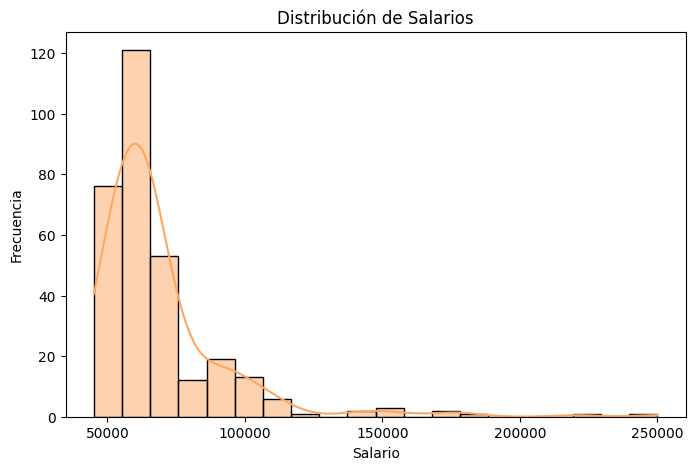

In [ ]:
# Histograma con la frecuencia de los Salarios

plt.figure(figsize=(8,5))  # tamaño del gráfico
sns.histplot(data=hrdataset, x='Salary', bins=20, kde=True)
plt.title("Distribución de Salarios")
plt.xlabel("Salario")
plt.ylabel("Frecuencia")
plt.show()

In [ ]:
# Tabla descriptiva de salario por posición

tabladescriptposition = pd.pivot_table(
    hrdataset,
    values='Salary',
    index='Position',
    aggfunc=['mean', 'median', 'min', 'max', 'count']
)
print(tabladescriptposition)

                                       mean    median     min     max  count
                                     Salary    Salary  Salary  Salary Salary
Position                                                                    
Accountant I                   63507.666667   63003.0   63000   64520      3
Administrative Assistant       52280.000000   51920.0   49920   55000      3
Area Sales Manager             64932.555556   63695.0   55875   74326     27
BI Developer                   95465.000000   96370.0   90100   99020      4
BI Director                   110929.000000  110929.0  110929  110929      1
CIO                           220450.000000  220450.0  220450  220450      1
Data Analyst                   89756.875000   89587.5   83552   93554      8
Data Architect                150290.000000  150290.0  150290  150290      1
Database Administrator        108499.600000  110000.0   97999  114800      5
Director of Operations        170500.000000  170500.0  170500  170500      1

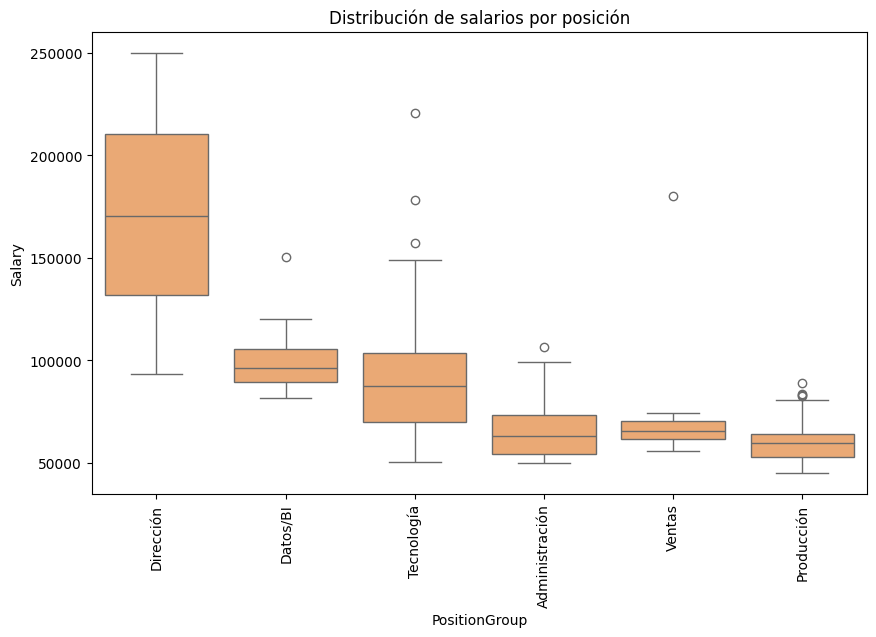

In [ ]:
# Diagrama de caja para ver visualmente la distribución de salarios por posición

# Indicamos el orden y la agrupacion que queremos en el gráfico
orden = hrdataset.groupby('PositionGroup')['Salary'].mean().sort_values(ascending=False).index

# Generamos el gráfico
plt.figure(figsize=(10,6))
sns.boxplot(data=hrdataset, x='PositionGroup', y='Salary', order=orden)
plt.title("Distribución de salarios por posición")
plt.xticks(rotation=90)
plt.show()

In [ ]:
# Resumen de estadísticas de salario por género
salario_genero = hrdataset.groupby('Sex')['Salary'].agg(
    frecuencia='count',       # cantidad de registros por género
    media='mean',         # salario promedio
    mediana='median',     # salario mediano
    mínimo='min',           # salario mínimo
    máximo='max'            # salario máximo
).reset_index()

print(salario_genero)

  Sex  frecuencia         media  mediana  mínimo  máximo
0   F         176  67786.727273  62066.5   45046  250000
1  M          135  70629.400000  63353.0   45115  178000


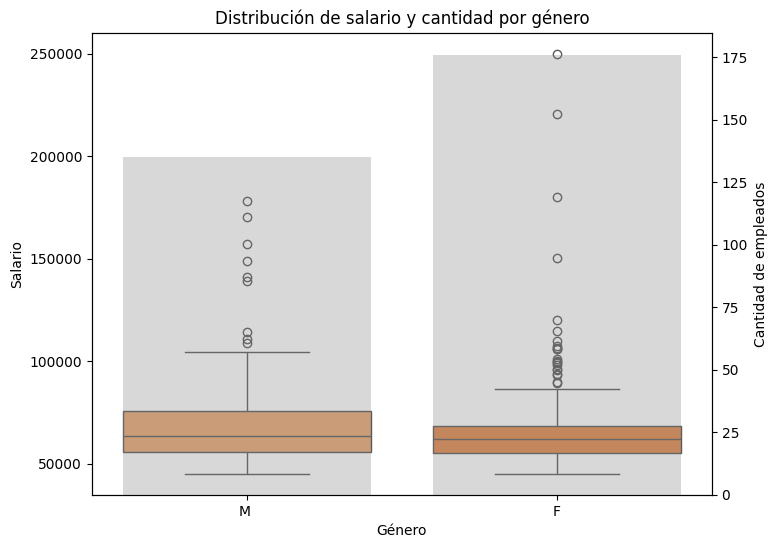

In [ ]:
## Box plot de distribucion y cantidad de salario por genero

# Preparar datos de frecuencia de género
frecuencia = hrdataset['Sex'].value_counts()

# Crear figura y ejes
fig, ax1 = plt.subplots(figsize=(8,6))

# Eje 1: Boxplot de salarios por género
sns.boxplot(data=hrdataset, x='Sex', y='Salary',hue='Sex', ax=ax1, legend=False)
ax1.set_ylabel("Salario")
ax1.set_xlabel("Género")
ax1.set_title("Distribución de salario y cantidad por género")

# Eje 2: Frecuencia de género (como barras)
ax2 = ax1.twinx()  # crea eje Y secundario
sns.barplot(x=frecuencia.index, y=frecuencia.values, alpha=0.3, color='gray', ax=ax2)
ax2.set_ylabel("Cantidad de empleados")

plt.show()

### Manager

In [ ]:
# Array de nombres de los managers
hrdataset["ManagerName"].unique()


array(['Michael Albert', 'Simon Roup', 'Kissy Sullivan', 'Elijiah Gray',
       'Webster Butler', 'Amy Dunn', 'Alex Sweetwater', 'Ketsia Liebig',
       'Brannon Miller', 'Peter Monroe', 'David Stanley', 'Kelley Spirea',
       'Brandon R. LeBlanc', 'Janet King', 'John Smith',
       'Jennifer Zamora', 'Lynn Daneault', 'Eric Dougall',
       'Debra Houlihan', 'Brian Champaigne', 'Board of Directors'],
      dtype=object)

In [ ]:
# Numero total de managers
num_managers = hrdataset['ManagerName'].nunique()

print("Número total de managers:", num_managers)

Número total de managers: 21


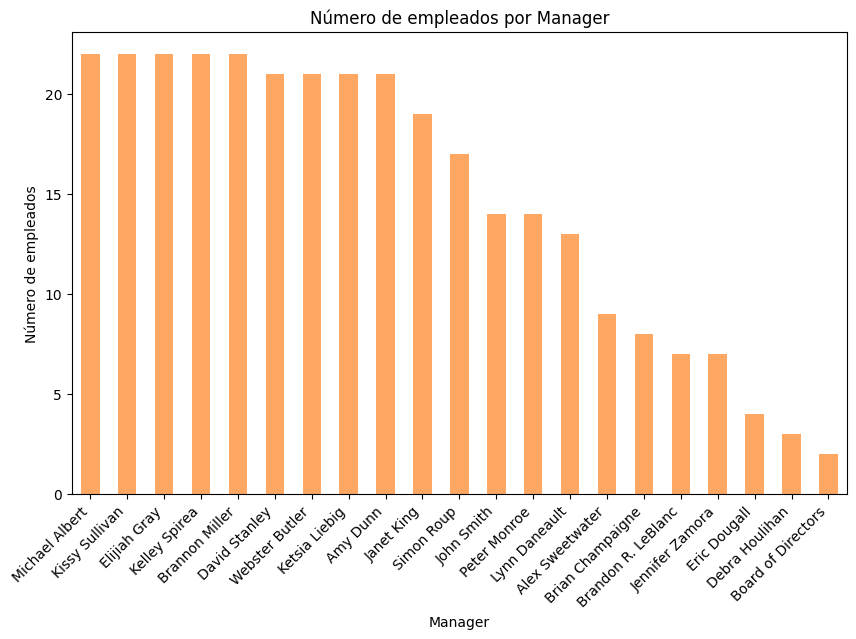

In [ ]:
# Conteo de empleados por Manager

manager_counts = hrdataset["ManagerName"].value_counts()

plt.figure(figsize=(10,6))
manager_counts.plot(kind="bar",)
plt.title("Número de empleados por Manager")
plt.ylabel("Número de empleados")
plt.xlabel("Manager")
plt.xticks(rotation=45, ha="right")
plt.show()

Hay un total de 21 managers y cada manager tiene alrededor de 20 empleados a su cargo.
Se puede ver que hay alrededor de 8 managers gestionando equipo de 20 personas o más, y que hay pocos equipos con menos de 10 personas


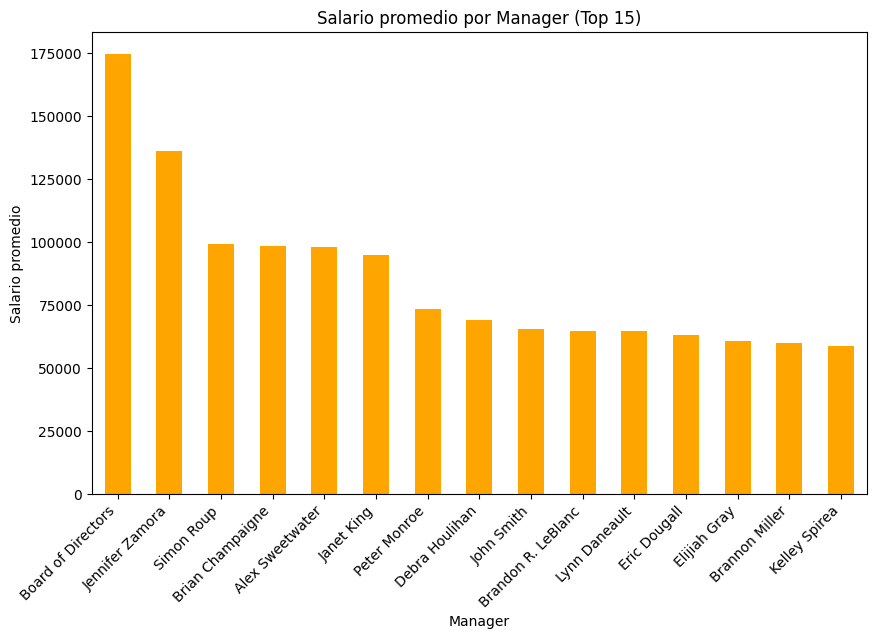

In [ ]:
# Salario promedio de cada Manager

manager_salary = (
    hrdataset.groupby("ManagerName")["Salary"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(10,6))
manager_salary.plot(kind="bar", color="orange")
plt.title("Salario promedio por Manager (Top 15)")
plt.ylabel("Salario promedio")
plt.xlabel("Manager")
plt.xticks(rotation=45, ha="right")
plt.show()

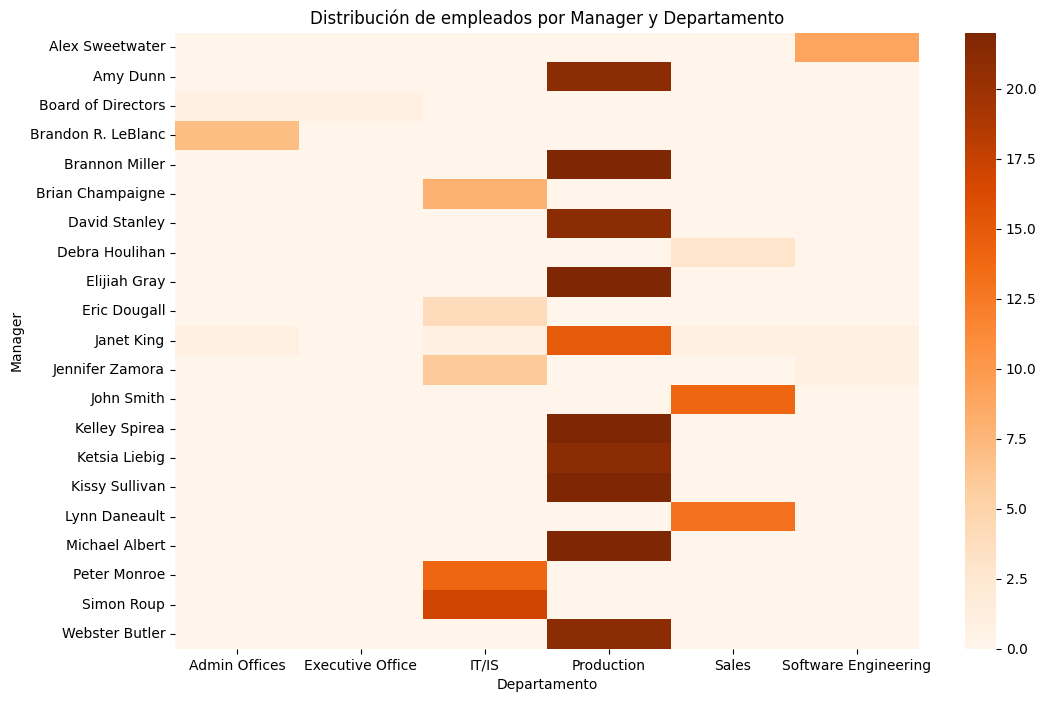

In [ ]:
# Tabla cruzada: cuántos empleados por Manager y Departamento

pivot_dept = pd.crosstab(hrdataset["ManagerName"], hrdataset["Department"])

plt.figure(figsize=(12,8))
sns.heatmap(pivot_dept, cmap="Oranges", cbar=True)
plt.title("Distribución de empleados por Manager y Departamento")
plt.xlabel("Departamento")
plt.ylabel("Manager")
plt.show()


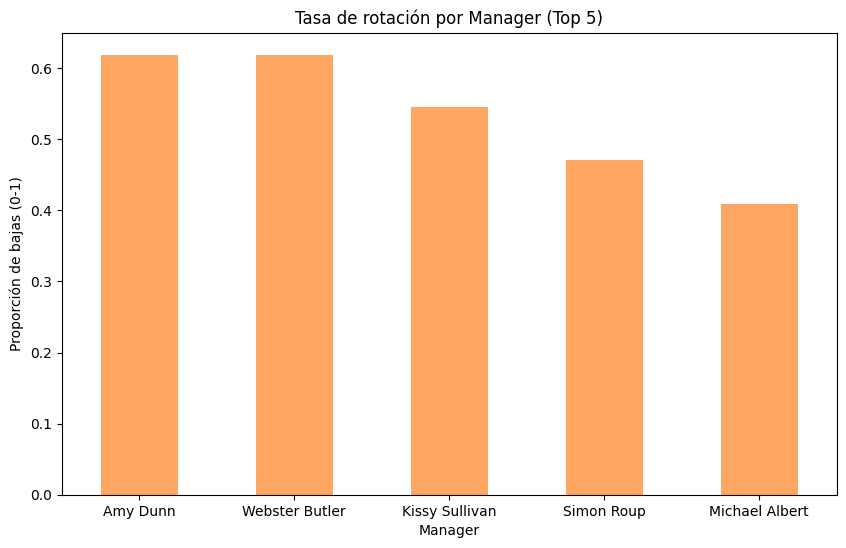

In [ ]:
# Nivel de rotación por manager

manager_turnover = (
    hrdataset.groupby("ManagerName")["Termd"]
    .mean()
    .sort_values(ascending=False)
    .head(5)
)

plt.figure(figsize=(10,6))
manager_turnover.plot(kind="bar")
plt.title("Tasa de rotación por Manager (Top 5)")
plt.ylabel("Proporción de bajas (0-1)")
plt.xlabel("Manager")
plt.xticks(rotation=None)
plt.show()

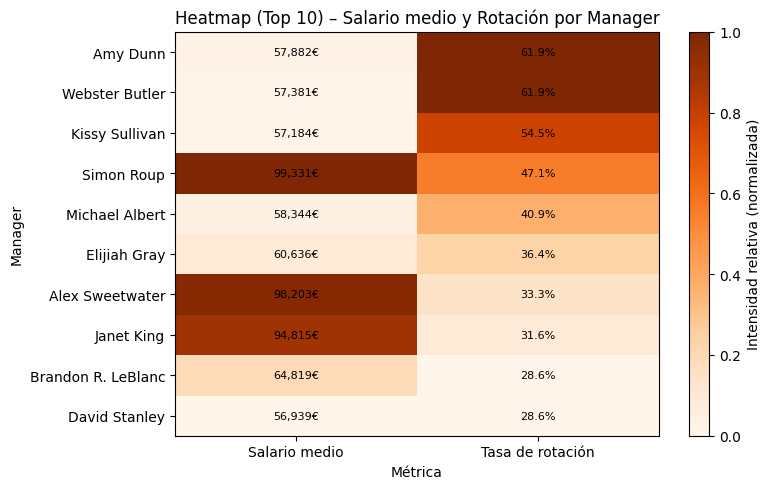

In [ ]:
#### Heatmap de Manager x (Salario medio, Rotación)

# --- Parámetros ---
TOP_N = 10
MIN_TEAM = 5

# --- Preparación ---
df = hrdataset.copy()
df["ManagerName"] = df["ManagerName"].astype("string").str.strip()
df["Salary"] = pd.to_numeric(df["Salary"], errors="coerce")
df["Termd"]  = pd.to_numeric(df["Termd"], errors="coerce")  # 0/1
df = df.dropna(subset=["ManagerName", "Salary", "Termd"])

# --- Agregación por manager ---
agg = (df.groupby("ManagerName")
         .agg(Salary_mean=("Salary","mean"),
              Turnover_rate=("Termd","mean"),
              n=("ManagerName","size"))
         .sort_values("Turnover_rate", ascending=False))

# Filtro por tamaño de equipo y Top N
topN = agg.loc[agg["n"] >= MIN_TEAM].head(TOP_N)
if topN.empty:
    raise ValueError("No hay managers tras el filtro. Ajusta MIN_TEAM/TOP_N.")

# --- Matriz y normalización para el heatmap ---
heat = topN[["Salary_mean","Turnover_rate"]]
norm = (heat - heat.min()) / (heat.max() - heat.min())
norm = norm.fillna(0)

# --- Plot del heatmap (paleta naranja) ---
fig, ax = plt.subplots(figsize=(8, max(4, 0.5 * len(heat))))
im = ax.imshow(norm.values, aspect="auto", cmap=plt.cm.Oranges)

ax.set_title(f"Heatmap (Top {TOP_N}) – Salario medio y Rotación por Manager")
ax.set_xlabel("Métrica")
ax.set_ylabel("Manager")
ax.set_xticks(range(2))
ax.set_xticklabels(["Salario medio", "Tasa de rotación"])
ax.set_yticks(range(len(heat)))
ax.set_yticklabels(heat.index)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Intensidad relativa (normalizada)")

# Etiquetas con valores reales (€, %)
for i in range(heat.shape[0]):
    ax.text(0, i, f"{heat.iloc[i,0]:,.0f}€", ha="center", va="center", fontsize=8)
    ax.text(1, i, f"{heat.iloc[i,1]:.1%}",  ha="center", va="center", fontsize=8)

plt.tight_layout()
plt.show()

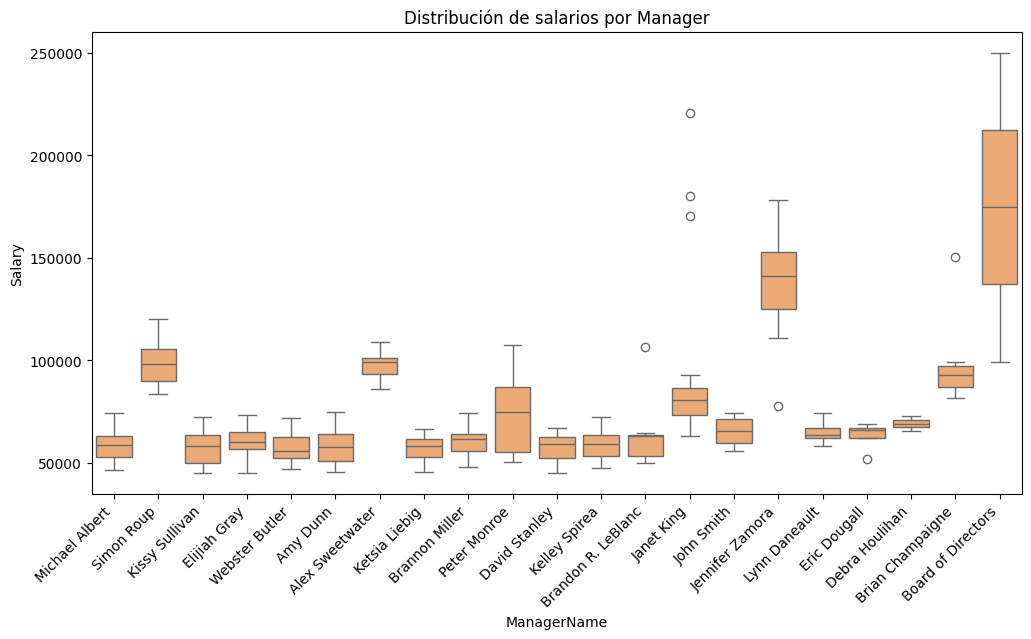

In [ ]:
# Boxplot por salarios por Manager

plt.figure(figsize=(12,6))
sns.boxplot(data=hrdataset, x="ManagerName", y="Salary")
plt.title("Distribución de salarios por Manager")
plt.xticks(rotation=45, ha="right")
plt.show()

In [ ]:
manager_summary = (
    hrdataset
    .groupby(["ManagerName"])
    .agg(
        team_size=("Employee_Name", "count"),
        avg_salary=("Salary", "mean"),
        turnover_rate=("Termd", "mean")
    )
    .reset_index()
)
print(manager_summary)

           ManagerName  team_size     avg_salary  turnover_rate
0      Alex Sweetwater          9   98203.222222       0.333333
1             Amy Dunn         21   57881.857143       0.619048
2   Board of Directors          2  174675.500000       0.000000
3   Brandon R. LeBlanc          7   64818.571429       0.285714
4       Brannon Miller         22   60095.454545       0.272727
5     Brian Champaigne          8   98319.750000       0.000000
6        David Stanley         21   56938.571429       0.285714
7       Debra Houlihan          3   69240.000000       0.333333
8         Elijiah Gray         22   60635.954545       0.363636
9         Eric Dougall          4   63188.750000       0.000000
10          Janet King         19   94814.842105       0.315789
11     Jennifer Zamora          7  136061.142857       0.142857
12          John Smith         14   65350.428571       0.214286
13       Kelley Spirea         22   58912.181818       0.272727
14       Ketsia Liebig         21   5693

### Ausencias

In [ ]:
hrdataset['Absences'].describe()

,Absences
count,311.000000
mean,10.237942
std,5.852596
min,1.000000
25%,5.000000
50%,10.000000
75%,15.000000
max,20.000000


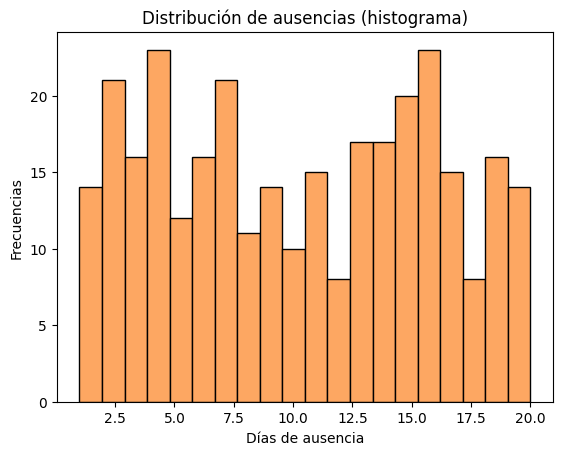

In [ ]:
# Histograma
plt.hist(hrdataset["Absences"], bins=20, edgecolor="black")
plt.xlabel("Días de ausencia")
plt.ylabel("Frecuencias")
plt.title("Distribución de ausencias (histograma)")
plt.show()



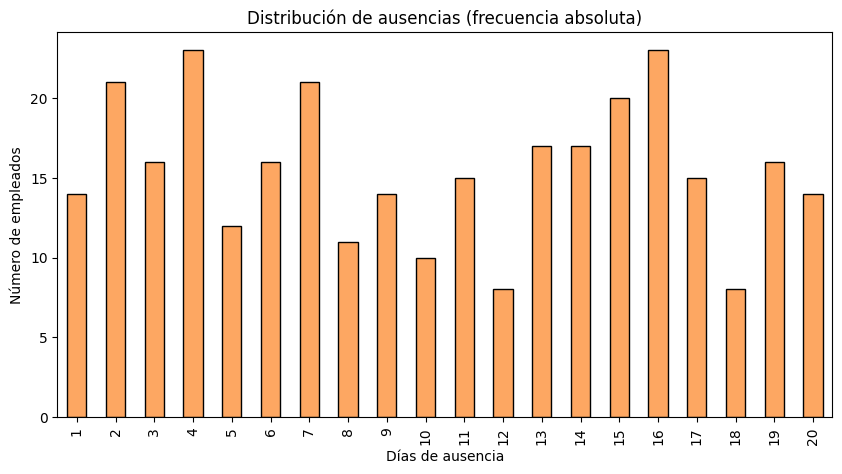

In [ ]:
# Distribución de frecuencias absolutas
freq_absences = hrdataset["Absences"].value_counts().sort_index()

# Barras con frecuencias exactas
freq_absences.plot(kind="bar", figsize=(10,5), edgecolor="black")
plt.xlabel("Días de ausencia")
plt.ylabel("Número de empleados")
plt.title("Distribución de ausencias (frecuencia absoluta)")
plt.show()

En el último año, los trabajadores han faltado al trabajo de media 10 días, por otro lado no han faltado más de 20 días de trabajo.
En el siguiente gráfico vemos que 4 días y 16 días es la frecuencia mayor de ausencias que tienen los trabajadores seguidas de 2 y 7 días.


           ManagerName  count       mean  median       std  total
0      Alex Sweetwater      9   9.777778     9.0  6.942222     88
1             Amy Dunn     21   9.523810     9.0  6.071401    200
2   Board of Directors      2   6.500000     6.5  4.949747     13
3   Brandon R. LeBlanc      7   7.857143     6.0  5.756983     55
4       Brannon Miller     22   9.181818     8.0  6.091652    202
5     Brian Champaigne      8  12.500000    14.5  5.424811    100
6        David Stanley     21  10.380952    10.0  5.826459    218
7       Debra Houlihan      3   8.666667     8.0  7.023769     26
8         Elijiah Gray     22   9.136364     8.5  5.970526    201
9         Eric Dougall      4   9.000000     8.0  8.906926     36
10          Janet King     19  10.210526    11.0  6.285600    194
11     Jennifer Zamora      7   9.285714     8.0  4.461475     65
12          John Smith     14  13.357143    16.0  5.904459    187
13       Kelley Spirea     22  11.363636    12.5  5.694989    250
14       K

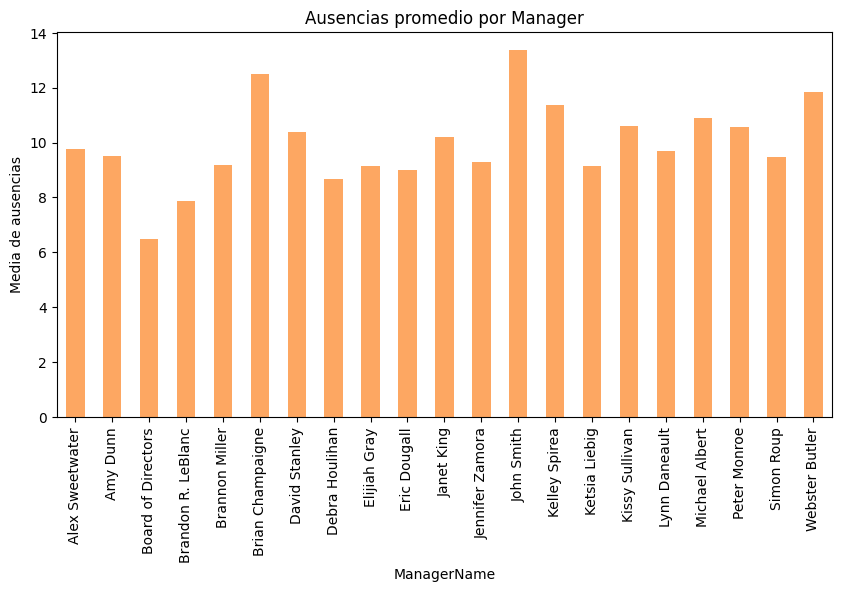

In [ ]:
ausencias_manager = hrdataset.groupby("ManagerName")["Absences"].agg(
    count="count",   # nº empleados por departamento
    mean="mean",     # media de ausencias
    median="median", # mediana
    std="std",       # desviación típica
    total="sum"      # total de ausencias
).reset_index()

print(ausencias_manager)

# Barras con las medias de ausencias por depto
ausencias_manager.plot(
    x="ManagerName", y="mean", kind="bar", legend=False, figsize=(10,5)
)
plt.ylabel("Media de ausencias")
plt.title("Ausencias promedio por Manager")
plt.xticks(rotation=90)
plt.show()

             Department  count       mean  median       std  total
0         Admin Offices      9   8.666667     6.0  6.745369     78
1      Executive Office      1  10.000000    10.0       NaN     10
2                 IT/IS     50  10.440000    10.5  5.624872    522
3            Production    209  10.143541    11.0  5.795262   2120
4                 Sales     31  11.548387    11.0  6.254805    358
5  Software Engineering     11   8.727273     8.0  6.634620     96


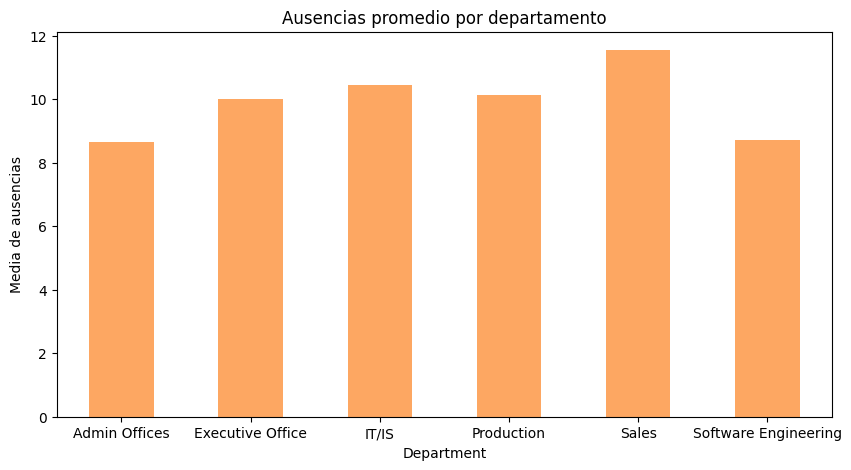

In [ ]:
ausencias_depto = hrdataset.groupby("Department")["Absences"].agg(
    count="count",   # nº empleados por departamento
    mean="mean",     # media de ausencias
    median="median", # mediana
    std="std",       # desviación típica
    total="sum"      # total de ausencias
).reset_index()

print(ausencias_depto)

# Barras con las medias de ausencias por depto
ausencias_depto.plot(
    x="Department", y="mean", kind="bar", legend=False, figsize=(10,5)
)
plt.ylabel("Media de ausencias")
plt.title("Ausencias promedio por departamento")
plt.xticks(rotation=None)
plt.show()

IT/IS (10.5) y especialmente Sales (11) son los que más destacan en ausencias. Puedes que tenga alta carga de trabajo/proyectos y /o presión por resultados.

### Método de reclutamiento

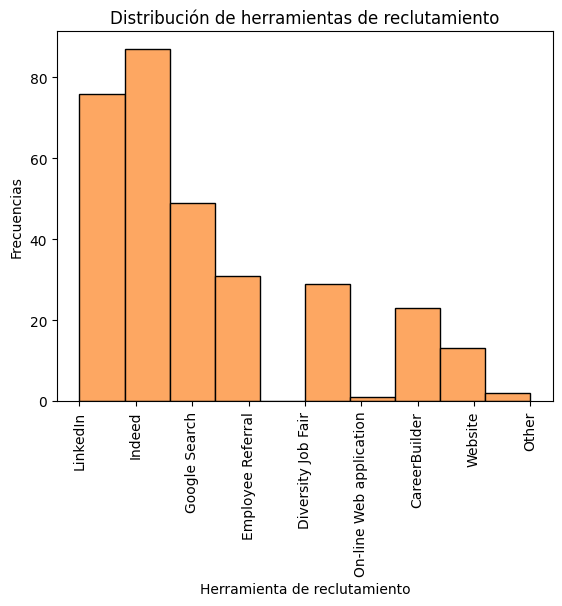

In [ ]:
# Histograma
plt.hist(hrdataset["RecruitmentSource"], bins=10, edgecolor="black")
plt.xlabel("Herramienta de reclutamiento")
plt.ylabel("Frecuencias")
plt.xticks(rotation=90)
plt.title("Distribución de herramientas de reclutamiento")
plt.show()

### Projectos especiales

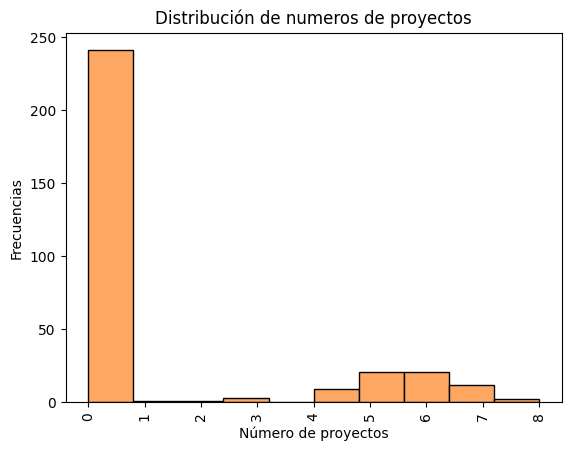

In [ ]:
# Histograma de la distribucion de frecuencias por proyectos
plt.hist(hrdataset["SpecialProjectsCount"], bins=10, edgecolor="black")
plt.xlabel("Número de proyectos")
plt.ylabel("Frecuencias")
plt.xticks(rotation=90)
plt.title("Distribución de numeros de proyectos")
plt.show()

             Department  count      mean  median       std  total
0         Admin Offices      9  3.666667     4.0  1.802776     33
1      Executive Office      1  0.000000     0.0       NaN      0
2                 IT/IS     50  5.920000     6.0  0.944155    296
3            Production    209  0.019139     0.0  0.218424      4
4                 Sales     31  0.000000     0.0  0.000000      0
5  Software Engineering     11  4.181818     4.0  1.662419     46


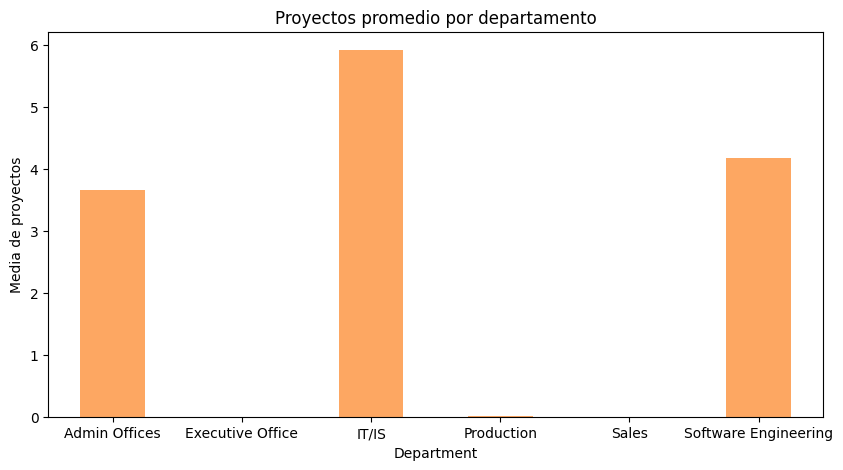

In [ ]:
# Estadisticos descriptivos del nuemro de proyectos especiales por departamento
proyectos_depto = hrdataset.groupby("Department")["SpecialProjectsCount"].agg(
    count="count",   # nº empleados por departamento
    mean="mean",     # media de ausencias
    median="median", # mediana
    std="std",       # desviación típica
    total="sum"      # total de ausencias
).reset_index()

print(proyectos_depto)

# Barras con las medias de ausencias por depto
proyectos_depto.plot(
    x="Department", y="mean", kind="bar", legend=False, figsize=(10,5)
)
plt.ylabel("Media de proyectos")
plt.title("Proyectos promedio por departamento")
plt.xticks(rotation=None)
plt.show()

### Compromiso del empleado

Es de tipo float porque es la media de respuestas en una encuesta realizada a través de un proveedor externo

EngagementSurvey
1.12     0.32
1.20     0.32
1.56     0.32
1.81     0.32
1.93     0.32
        ...  
4.88     0.32
4.90     0.32
4.94     0.32
4.96     0.64
5.00    18.01
Name: proportion, Length: 119, dtype: float64


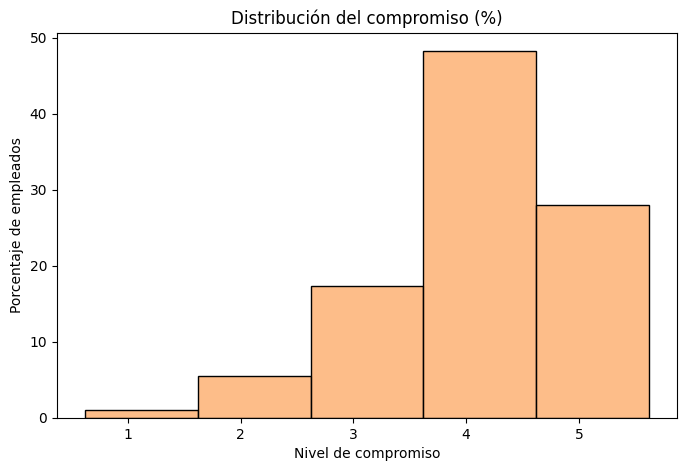

In [ ]:
# Frecuencia relativa del compromiso del empleado y su gráfico
engagement_pct = hrdataset["EngagementSurvey"].value_counts(normalize=True).sort_index() * 100
print(engagement_pct.round(2))

plt.figure(figsize=(8,5))
sns.histplot(data=hrdataset, x="EngagementSurvey", stat="percent", discrete=True)

plt.title("Distribución del compromiso (%)")
plt.xlabel("Nivel de compromiso")
plt.ylabel("Porcentaje de empleados")
plt.show()

Mas de la mitad de la plantilla consigue tener un compromiso alto

### Satisfacción del empleado     

Encuesta de satisfación: 1 (nada satifecho) - 5 (muy satisfecho)




EmpSatisfaction
1     0.64
2     2.89
3    34.73
4    30.23
5    31.51
Name: proportion, dtype: float64


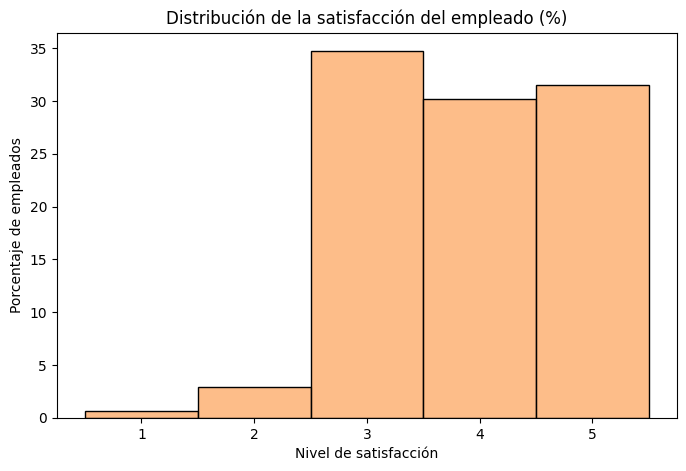

In [ ]:
#Frecuencias relativas de la satisfaccion y su grafico
satisfaction_pct = hrdataset["EmpSatisfaction"].value_counts(normalize=True).sort_index() * 100

print(satisfaction_pct.round(2))
plt.figure(figsize=(8,5))
sns.histplot(data=hrdataset, x="EmpSatisfaction", stat="percent", discrete=True)

plt.title("Distribución de la satisfacción del empleado (%)")
plt.xlabel("Nivel de satisfacción")
plt.ylabel("Porcentaje de empleados")
plt.show()

Hay un alto número de trabajadores que están satisfechos en el trabajo alrededor del 65%, esto refleja un clima laboral mayoritariamente positivo. Pero con un riesgo latente puesto el 35% son neutros (3) en su satisfacción y/o hay insatisfacción.

### Evaluación de desempeño

PerformanceScore
Exceeds              11.90
Fully Meets          78.14
Needs Improvement     5.79
PIP                   4.18
Name: proportion, dtype: float64


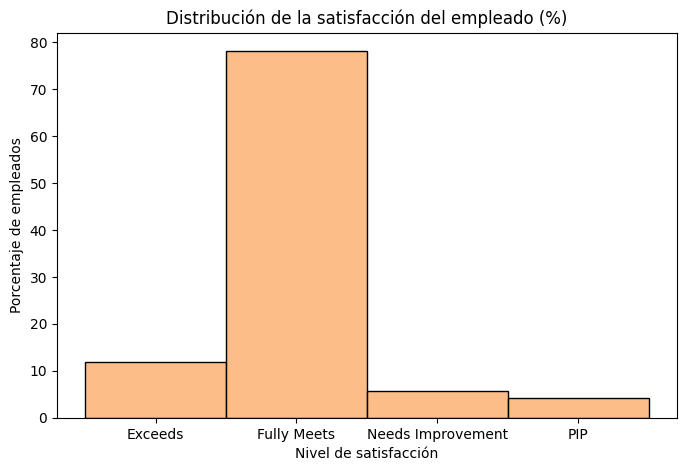

In [ ]:
desempeño_pct = hrdataset["PerformanceScore"].value_counts(normalize=True).sort_index() * 100

print(desempeño_pct.round(2))

plt.figure(figsize=(8,5))
sns.histplot(data=hrdataset, x="PerformanceScore", stat="percent", discrete=True)

plt.title("Distribución de la satisfacción del empleado (%)")
plt.xlabel("Nivel de satisfacción")
plt.ylabel("Porcentaje de empleados")
plt.show()

En general tienen un desempeño positivo alrededor del 90% de la empresa.

## Análisis de correlación entre variables


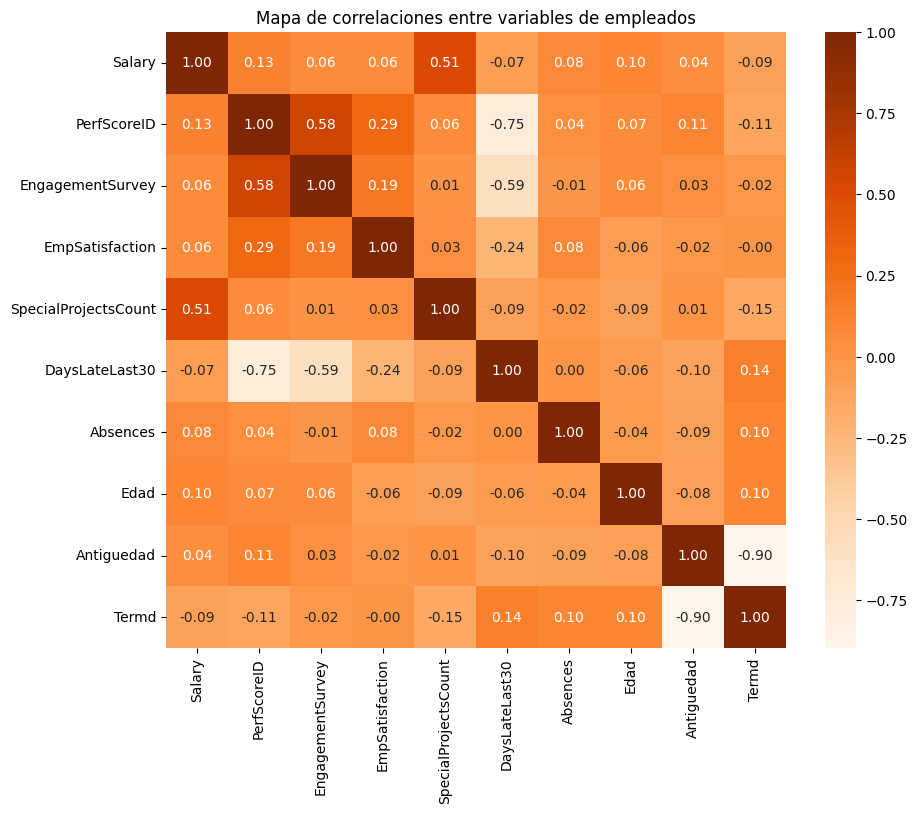

In [ ]:
# Calculamos el tiempo que estuvieron los empleados que ya no estan en la compañia
hrdataset.loc[hrdataset["Termd"]==1, "Antiguedad"] = (hrdataset["DateofTermination"] - hrdataset["DateofHire"]).dt.days // 365

# Selección de numéricas para correlación
num_vars = [
    "Salary", "PerfScoreID", "EngagementSurvey", "EmpSatisfaction",
    "SpecialProjectsCount", "DaysLateLast30", "Absences",
    "Edad", "Antiguedad", "Termd"
]

corr = hrdataset[num_vars].corr(method="pearson")

# --- Heatmap ---
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="Oranges", fmt=".2f")
plt.title("Mapa de correlaciones entre variables de empleados")
plt.show()

Análisis del mapa de correlación:
- El salario se relaciona mas con proyectos especiales antes que con la evaluación de desempeño lo que puede indicar que la empresa beneficia economicamente mejor a los empleados que estan en proyectos extra antes que a los que tienen un buen desempeño.
- Relación fuerte con la encuesta de satisfacción y la evaluación de desempeño; se puede traducir en que los empleados mas comprometidos rinden mejor. Por otro lado relacion muy negatica con DaysLateLast30, es decir que la clasificacion de desempeño esta muy ligada a llegar tarde. Se toma muy en cuenta la puntualidad y el compromiso.

- La satisfaccion del empleado (empSatisfaction) casi no tiene correlacion con nada, puede tener una escala mas subjetiva por lo que no la tomaremos en cuenta en los análisis posteriores.


- Por último, la correlacion negativa de antiguedad y la rotación, nos indica que hay menos probabilidad de que te abandones la empresa si llevas mas tiempo siendo empleado, y tambein que los que llevan poco tiempo son mas propensos a irse. No hay apenas relación con salario, desempeño o satisfaccion en la empresa, por lo que parece que permanecer en ella tiene mas que ver con la permanencia que con el desempeño.

#### Indagamos en las correlaciones mas fuertes que se ven

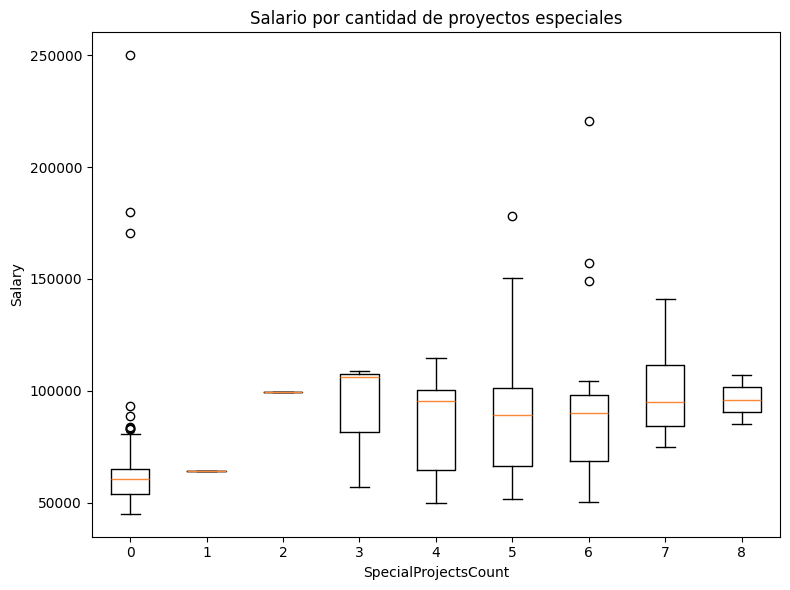

In [ ]:
# ====== 1) BOXPLOT: SALARIO POR SPECIALPROJECTSCOUNT ======
# Preparo listas de salarios por cada valor de proyectos especiales
counts_sorted = sorted(hrdataset["SpecialProjectsCount"].unique())  # valores únicos ordenados de proyectos especiales
salary_groups = [hrdataset.loc[hrdataset["SpecialProjectsCount"] == c, "Salary"].values for c in counts_sorted]  # salarios por grupo

plt.figure(figsize=(8,6))  # inicia figura para el boxplot con tamaño manejable
plt.boxplot(salary_groups, tick_labels=counts_sorted, showfliers=True)  # crea boxplot por cada cantidad de proyectos
plt.xlabel("SpecialProjectsCount")  # etiqueta eje X con nombre de la variable
plt.ylabel("Salary")  # etiqueta eje Y con nombre salario
plt.title("Salario por cantidad de proyectos especiales")  # título descriptivo del gráfico
plt.tight_layout()  # ajusta espacios para evitar solapamientos
plt.show()  # muestra el gráfico en pantalla

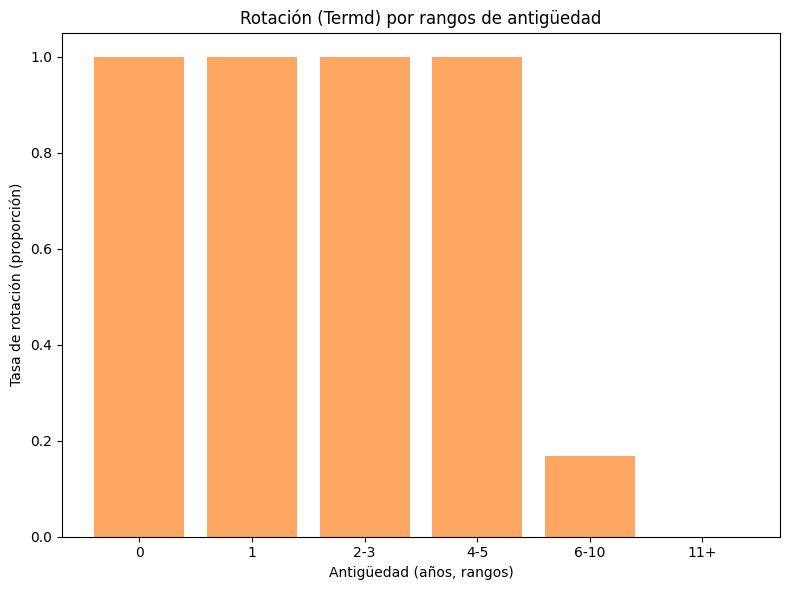

In [ ]:
# ====== 2) BARRAS: TASA DE ROTACIÓN POR RANGOS DE ANTIGÜEDAD ======
# bins (rangos) de antigüedad y cálculo de la tasa de rotación media
bins = [-1, 0, 1, 3, 5, 10, hrdataset["Antiguedad"].max()]  # define cortes de antigüedad razonables en años
labels = ["0", "1", "2-3", "4-5", "6-10", "11+"]  # etiquetas legibles para cada rango definido
hrdataset["TenureBin"] = pd.cut(hrdataset["Antiguedad"], bins=bins, labels=labels)  # asigna cada empleado a un rango
turnover_rate = hrdataset.groupby("TenureBin", observed=False)["Termd"].mean().reindex(labels) # tasa media rotación por rango

plt.figure(figsize=(8,6))  # inicia figura para gráfico de barras
plt.bar(turnover_rate.index.astype(str), turnover_rate.values)  # barras con tasa media por rango
plt.xlabel("Antigüedad (años, rangos)")  # etiqueta eje X indicando rangos de antigüedad
plt.ylabel("Tasa de rotación (proporción)")  # etiqueta eje Y como proporción terminada
plt.title("Rotación (Termd) por rangos de antigüedad")  # título claro del gráfico de rotación
plt.tight_layout()  # ajusta márgenes del gráfico para mejor visibilidad
plt.show()  # renderiza el gráfico en salida


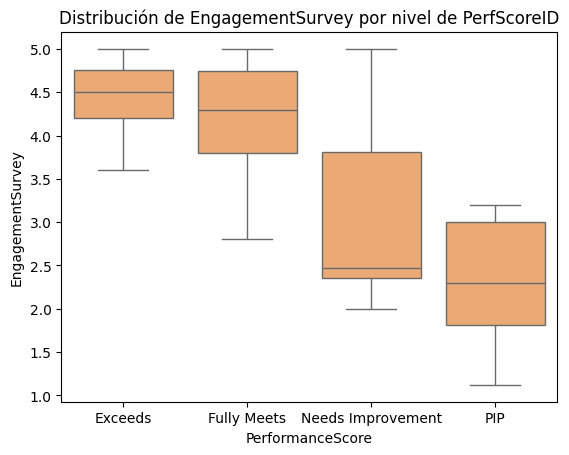

In [ ]:
# ====== 3) BOXPLOT: PERFScoreID VS ENGAGEMENTSURVEY ======

sns.boxplot(x="PerformanceScore", y="EngagementSurvey", data=hrdataset)
plt.title("Distribución de EngagementSurvey por nivel de PerfScoreID")
plt.show()

# Rotación: Quiénes se van vs quiénes se quedan (turnover).

In [ ]:
hrdataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 311 entries, 0 to 310
Data columns (total 46 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   Employee_Name                    311 non-null    object        
 1   EmpID                            311 non-null    int64         
 2   MarriedID                        311 non-null    int64         
 3   MaritalStatusID                  311 non-null    int64         
 4   GenderID                         311 non-null    int64         
 5   EmpStatusID                      311 non-null    int64         
 6   DeptID                           311 non-null    int64         
 7   PerfScoreID                      311 non-null    int64         
 8   FromDiversityJobFairID           311 non-null    int64         
 9   Salary                           311 non-null    int64         
 10  Termd                            311 non-null    int64        

In [ ]:
# Definir variables explicativas evitando identificadores y fuga de datos
num_features = [  # variables numéricas estables y relevantes
    "Salary","EngagementSurvey","EmpSatisfaction",
                  "DaysLateLast30","Absences",
                  "Edad","Antiguedad",
                  "SpecialProjectsCount",
]
cat_features = [  # variables categóricas con lógica de negocio
    "RecruitmentSource","Department","PositionGroup", "PerformanceScore",
]
target = "Termd"  # variable objetivo: rotación binaria 1=se fue, 0=sigue

X = hrdataset[num_features + cat_features].copy()  # matriz de predictores completa
y = hrdataset[target].astype(int)  # vector objetivo como entero binario


In [ ]:
print(X.columns)

Index(['Salary', 'EngagementSurvey', 'EmpSatisfaction', 'DaysLateLast30',
       'Absences', 'Edad', 'Antiguedad', 'SpecialProjectsCount',
       'RecruitmentSource', 'Department', 'PositionGroup', 'PerformanceScore'],
      dtype='object')


In [ ]:
# Preprocesamiento

numeric_transformer = Pipeline(steps=[  # pipeline para numéricas
    ("imputer", SimpleImputer(strategy="median"))  # imputa faltantes con mediana robusta
])
categorical_transformer = Pipeline(steps=[  # pipeline para categóricas
    ("imputer", SimpleImputer(strategy="most_frequent")),  # imputa con moda
    ("onehot", OneHotEncoder(handle_unknown="ignore"))  # convierte a dummies ignorando categorías nuevas
])
preprocess = ColumnTransformer(  # ensambla transformaciones por tipo
    transformers=[
        ("num", numeric_transformer, num_features),  # aplica a numéricas
        ("cat", categorical_transformer, cat_features)  # aplica a categóricas
    ],
    remainder="drop"  # descarta columnas no especificadas
)

In [ ]:
# MODELOS

# Pipeline 1: Regresión Logística con escalado de numéricas
logistic_pre_num = Pipeline([  # sub-pipeline para escalar numéricas
    ("imputer", SimpleImputer(strategy="median")),  # imputar faltantes numéricos
    ("scaler", StandardScaler())  # escalar para estabilizar coeficientes
])
preprocess_for_logistic = ColumnTransformer(  # preprocesamiento específico logística
    transformers=[
        ("num", logistic_pre_num, num_features),  # imputa y escala numéricas
        ("cat", categorical_transformer, cat_features)  # one-hot categóricas
    ]
)
log_reg = Pipeline(steps=[  # pipeline completo logística
    ("prep", preprocess_for_logistic),  # preprocesamiento dedicado
    ("clf", LogisticRegression(max_iter=1000,
                               class_weight=None,
                               n_jobs=None))  # logística robusta
])

# Pipeline 2: Random Forest con preprocesamiento genérico
rf = Pipeline(steps=[  # pipeline completo random forest
    ("prep", preprocess),  # preprocesamiento estándar sin escalado
    ("clf", RandomForestClassifier(
        n_estimators=500,
        max_depth=15,            # profundidad máxima
        min_samples_split=20,    # mínimo para dividir
        min_samples_leaf=10,     # mínimo hojas
        max_features="sqrt",     # nº de features por split
        class_weight=None,
        random_state=42,
        n_jobs=-1  # bosque suficientemente grande
    ))
])

In [ ]:
# Definir K-Fold estratificado (mantiene proporciones de rotación en cada fold)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


scores_log = cross_val_score(log_reg, X, y, cv=cv, scoring="roc_auc")
scores_rf = cross_val_score(rf, X, y, cv=cv, scoring="roc_auc")

print("AUC LogReg:", scores_log.mean())
print("AUC RF:", scores_rf.mean())


AUC LogReg: 1.0
AUC RF: 0.9976881809634423


In [ ]:
# TRAIN/TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

#  ENTRENAMIENTO
log_reg.fit(X_train, y_train)  # entrena regresión logística con datos de entrenamiento
rf.fit(X_train, y_train)  # entrena random forest con datos de entrenamiento

# PREDICCIONES Y MÉTRICAS
def eval_model(model, name):  # función para evaluar y devolver métricas clave
    y_pred = model.predict(X_test)  # predicciones de clase para conjunto prueba
    y_proba = model.predict_proba(X_test)[:, 1]  # probabilidades clase positiva
    metrics = {  # calcula métricas estándar clasificación
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "auc": roc_auc_score(y_test, y_proba)
    }
    return metrics, y_pred, y_proba  # devuelve métricas y vectores necesarios

m_log, y_pred_log, y_proba_log = eval_model(log_reg, "LogisticRegression")  # evalúa logística
m_rf, y_pred_rf, y_proba_rf = eval_model(rf, "RandomForest")  # evalúa random forest

metrics_df = pd.DataFrame([m_log, m_rf])  # tabla comparativa de métricas
print("=== Métricas comparativas ===")  # título de sección de resultados
print(metrics_df.round(3))  # muestra métricas con tres decimales


=== Métricas comparativas ===
                model  accuracy  precision  recall     f1    auc
0  LogisticRegression     0.987        1.0    0.96  0.980  1.000
1        RandomForest     0.962        1.0    0.88  0.936  0.998


La regresión logistica tiene una sensibilidad mas alta que el random forest


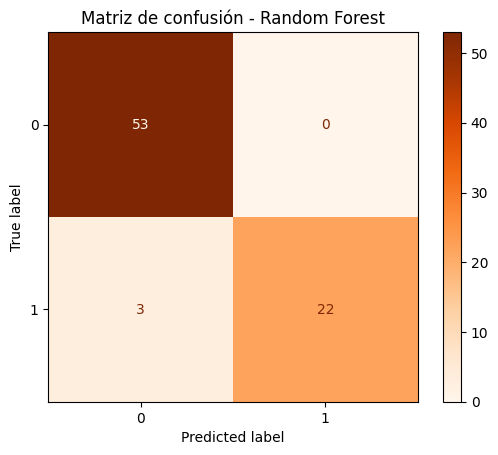

In [ ]:
# Predicciones de Random Forest
y_pred_rf = rf.predict(X_test)

# Mostrar matriz de confusión
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, cmap="Oranges")
plt.title("Matriz de confusión - Random Forest")
plt.show()

Verdaderos negativos (TN = 53):
53 empleados que no rotaban y el modelo acertó en predecir que no rotaban.

Falsos positivos (FP = 0):
Ningún caso en el que el modelo dijera que un empleado iba a rotar cuando en realidad no.

Falsos negativos (FN = 3):
3 empleados que sí rotaban, pero el modelo predijo que no lo harían.

Verdaderos positivos (TP = 22):
22 empleados que rotaban y el modelo los detectó correctamente.

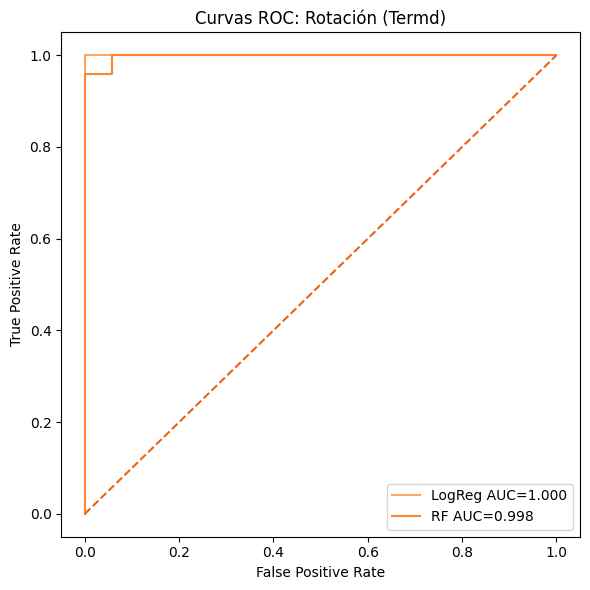

In [ ]:
# CURVAS ROC COMPARATIVAS

fpr_log, tpr_log, _ = roc_curve(y_test, y_proba_log)  # puntos ROC regresión logística
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)  # puntos ROC random forest

plt.figure(figsize=(6,6))  # tamaño de la figura ROC
plt.plot(fpr_log, tpr_log, label=f"LogReg AUC={m_log['auc']:.3f}")  # curva logística
plt.plot(fpr_rf, tpr_rf, label=f"RF AUC={m_rf['auc']:.3f}")  # curva random forest
plt.plot([0,1],[0,1], linestyle="--")  # diagonal referencia azar
plt.xlabel("False Positive Rate")  # etiqueta eje X
plt.ylabel("True Positive Rate")  # etiqueta eje Y
plt.title("Curvas ROC: Rotación (Termd)")  # título del gráfico ROC
plt.legend()  # leyenda con AUC por modelo
plt.tight_layout()  # ajustar márgenes de figura
plt.show()  # mostrar la figura ROC

El modelo es muy bueno detectando a los que NO rotan (clase 0) → 100% de acierto.

También es bastante bueno con los que sí rotan (clase 1), aunque se le escapan 3 casos.

La precisión en la clase positiva es perfecta, pero el recall no llega al 100%, lo que significa que puede subestimar algunos empleados que sí rotarán.

## Probabilidad de rotación por empleado



In [ ]:
hrdataset = hrdataset.copy()

# Hacemos una copia del data set solo teniendo en cuenta los trabajadores activos

hrdataset_activos = hrdataset[hrdataset["EmpStatusID"] == 1].copy()

In [ ]:

# 3) Construye X_activos con LAS MISMAS columnas usadas para entrenar
X_activos = hrdataset_activos[num_features + cat_features].copy()

# Calculo de la  probabilidad base
hrdataset_activos["proba_rotacion"] = rf.predict_proba(X_activos)[:,1]


hrdataset_activos[["Employee_Name", "proba_rotacion"]].head()

,Employee_Name,proba_rotacion
0,"Adinolfi, Wilson K",0.112879
3,"Alagbe,Trina",0.163633
5,"Anderson, Linda",0.194706
6,"Andreola, Colby",0.188618
7,"Athwal, Sam",0.242203


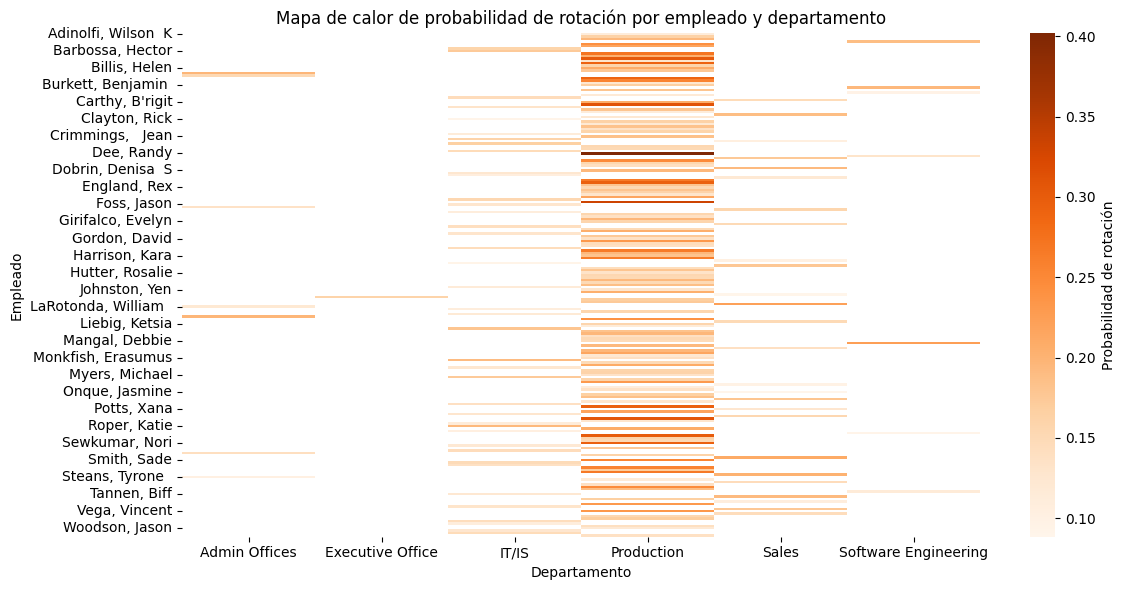

In [ ]:
# Crear tabla pivote: filas = empleados, columnas = departamentos, valores = prob. de rotación
pivot = hrdataset_activos.pivot_table(
    index="Employee_Name",
    columns="Department",
    values="proba_rotacion",
    aggfunc="mean"
)

# Dibujar el heatmap
plt.figure(figsize=(12,6))
sns.heatmap(pivot, cmap="Oranges", annot=False, cbar_kws={'label': 'Probabilidad de rotación'})
plt.title("Mapa de calor de probabilidad de rotación por empleado y departamento")
plt.ylabel("Empleado")
plt.xlabel("Departamento")
plt.tight_layout()
plt.show()

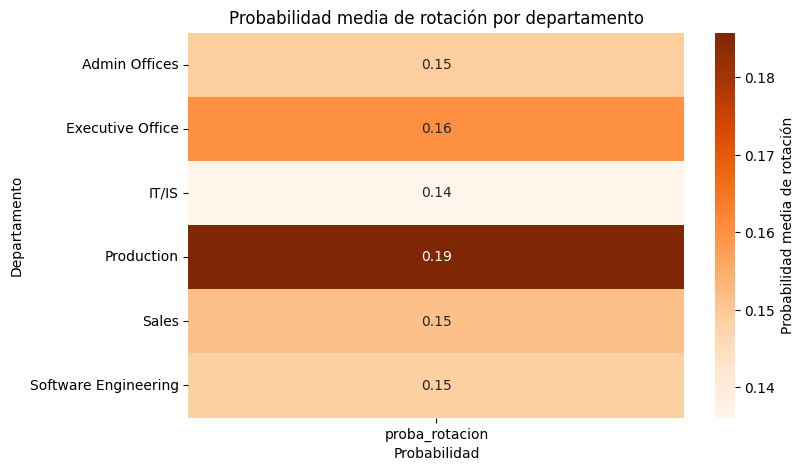

In [ ]:
# Probabilidad media por departamento
dept_pivot = hrdataset_activos.groupby("Department")["proba_rotacion"].mean().reset_index()

# Ordenar para que Producción quede arriba
dept_pivot = dept_pivot.sort_values("Department", ascending=False)

plt.figure(figsize=(8,5))
sns.heatmap(
    dept_pivot.pivot_table(index="Department", values="proba_rotacion"),
    cmap="Oranges", annot=True, fmt=".2f",
    cbar_kws={'label': 'Probabilidad media de rotación'}
)

plt.title("Probabilidad media de rotación por departamento")
plt.xlabel("Probabilidad")
plt.ylabel("Departamento")
plt.show()

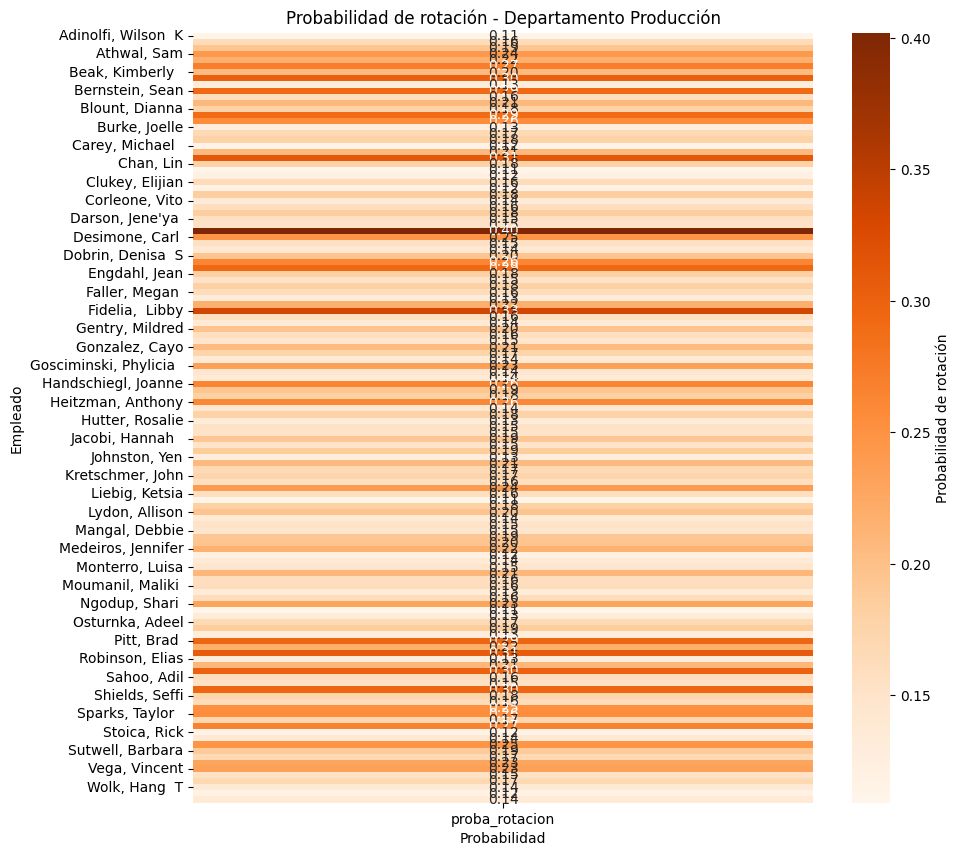

In [ ]:
# Filtrar solo empleados de Producción
prod_df = hrdataset_activos[hrdataset_activos["Department"] == "Production"]

# Ordenar por mayor probabilidad de rotación
prod_df = prod_df.sort_values("proba_rotacion", ascending=False)

# Heatmap de empleados de Producción
plt.figure(figsize=(10,10))
sns.heatmap(
    prod_df.pivot_table(index="Employee_Name", values="proba_rotacion"),
    cmap="Oranges", annot=True, fmt=".2f", cbar_kws={'label': 'Probabilidad de rotación'}
)
plt.title("Probabilidad de rotación - Departamento Producción")
plt.xlabel("Probabilidad")
plt.ylabel("Empleado")
plt.show()

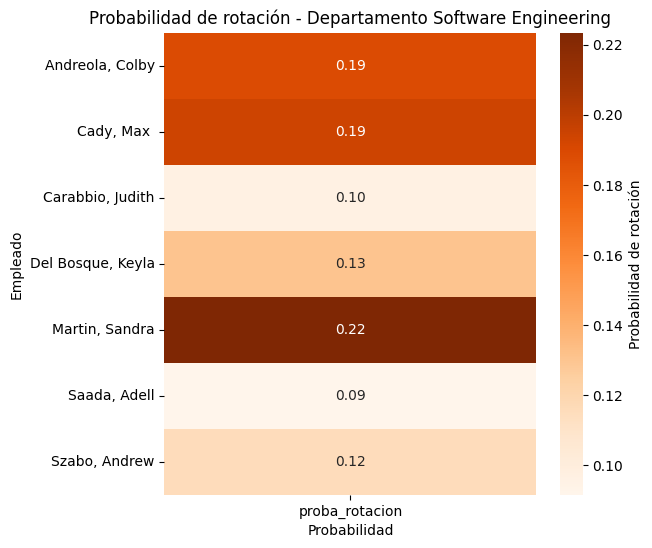

In [ ]:
# Filtrar solo empleados de Producción
prod_df = hrdataset_activos[hrdataset_activos["Department"] == "Software Engineering"]

# Ordenar por mayor probabilidad de rotación
prod_df = prod_df.sort_values("proba_rotacion", ascending=False)

# Heatmap de empleados de Producción
plt.figure(figsize=(6,6))
sns.heatmap(
    prod_df.pivot_table(index="Employee_Name", values="proba_rotacion"),
    cmap="Oranges", annot=True, fmt=".2f", cbar_kws={'label': 'Probabilidad de rotación'}
)
plt.title("Probabilidad de rotación - Departamento Software Engineering")
plt.xlabel("Probabilidad")
plt.ylabel("Empleado")
plt.show()

In [ ]:
# Dashboard  con un gráfico de barras interactivo
# Se muestras nombres de empleados y departamentos

def make_plot(dep_sel, n):
    df = hrdataset_activos.copy()
    if dep_sel != "Todos":
        df = df[df["Department"] == dep_sel]
    top_df = df.sort_values("proba_rotacion", ascending=False).head(n)

    # --- GRÁFICO ---
    fig = px.bar(
        top_df, x="proba_rotacion", y="Employee_Name", color="Department",
        orientation="h",
        title=f"Top {len(top_df)} por prob. de rotación" + (f" – {dep_sel}" if dep_sel != "Todos" else ""),
        labels={"proba_rotacion":"Prob. rotación","Employee_Name":"Empleado"},
        text=top_df["proba_rotacion"].round(2)
    )
    fig.update_layout(yaxis={'categoryorder':'total ascending'}, xaxis=dict(range=[0,1]))

    # --- TABLA (solo columnas relevantes) ---
    tabla = top_df[["Employee_Name", "Department", "proba_rotacion"]].round(3)

    return fig, tabla

departamentos = ["Todos"] + sorted(hrdataset["Department"].dropna().unique().tolist())

demo = gr.Interface(
    fn=make_plot,
    inputs=[
        gr.Dropdown(choices=departamentos, value="Todos", label="Departamento"),
        gr.Slider(5, 30, value=10, step=1, label="Top N")
    ],
    outputs=[
        gr.Plot(label="Top empleados por probabilidad de rotación"),
        gr.Dataframe(label="Detalle empleados")
    ],
    title="Dashboard Rotación RRHH",
    description="Filtra por departamento y ajusta el Top N."
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://e5621122d3d8757f05.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## Probabilidad de rotación por diferentes escenarios

Puesto que el AUC del modelo de regresión denota que hay variables autoexplicativas.
Vamos a generar un modelo donde puedes cambiar el valor de ciertas variables y ver el comportamiento que tienen estas en la rotación

In [ ]:

# Define los escenarios (cada item devuelve un df modificado)

SCENARIOS = {
    "prob_engagement+1": lambda df: df.assign(
        EngagementSurvey=(df["EngagementSurvey"] + 1).clip(upper=5)
    ),
    "prob_engagement0": lambda df: df.assign(
        EngagementSurvey=(df["EngagementSurvey"] == 0).clip(lower=0)
    ),
    "prob_proyectos+1": lambda df: df.assign(
        SpecialProjectsCount=(df["SpecialProjectsCount"] + 1).clip(lower=0)
    ),
    "prob_proyectos-1": lambda df: df.assign(
        SpecialProjectsCount=(df["SpecialProjectsCount"] - 1).clip(lower=0)
    ),
    "prob_salario+10pct": lambda df: df.assign(
        Salary=df["Salary"] * 1.10
    ),
    "prob_salario-10pct": lambda df: df.assign(
        Salary=df["Salary"] * 0.90
    ),
    "prob_perf+1": lambda df: df.assign(
        PerfScoreID=(df["PerfScoreID"] + 1).clip(upper=4)
    ),
    "prob_perf-1": lambda df: df.assign(
        PerfScoreID=(df["PerfScoreID"] - 1).clip(lower=1)
    ),
}

In [ ]:

# Ejecuta los escenarios y guarda prob y delta por empleado

for scen_name, scen_fn in SCENARIOS.items():
    scen_df = scen_fn(hrdataset_activos.copy())
    probs = rf.predict_proba(scen_df[num_features + cat_features])[:, 1]
    hrdataset_activos[scen_name] = probs
    hrdataset_activos[f"delta_{scen_name}"] = hrdataset_activos[scen_name] - hrdataset_activos["proba_rotacion"]

# Selección de columnas para el dashboard y guardado a Excel
cols = (["EmpID"] if "EmpID" in hrdataset_activos.columns else []) + num_features + cat_features + ["proba_rotacion"]
cols += list(SCENARIOS.keys()) + [f"delta_{k}" for k in SCENARIOS.keys()]


# Guardado en Excel para una exportacion mejor de los datos si se quieren plasmar en BI
hrdataset_activos[cols].to_excel("prob_por_empleado_escenarios.xlsx", index=False)
print("Archivo guardado: prob_por_empleado_escenarios.xlsx")

Archivo guardado: prob_por_empleado_escenarios.xlsx


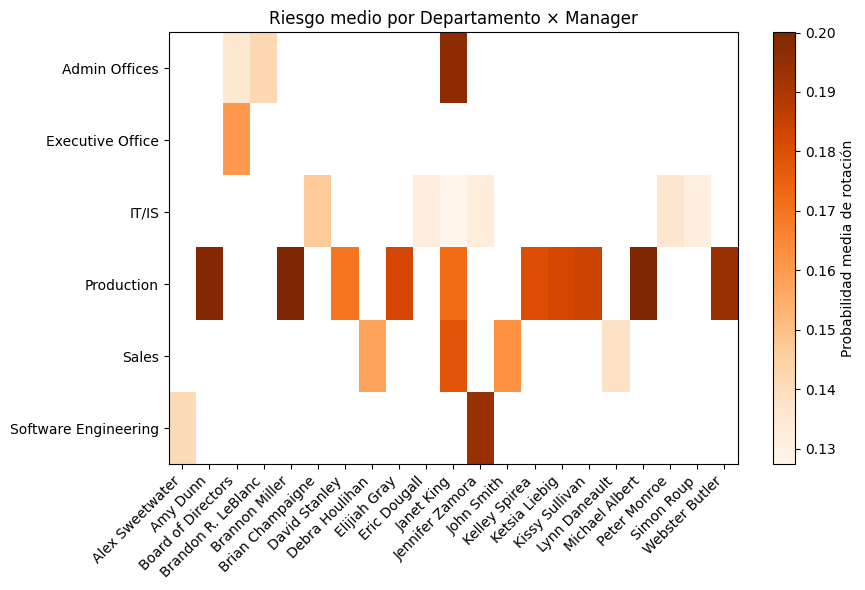

In [ ]:
# Tabla de riesgo medio de rotacion por departamento y manager

tabla = (hrdataset_activos
         .groupby(["Department", "ManagerName"])["proba_rotacion"]
         .mean()
         .unstack())  # filas=Dept, columnas=Manager

plt.figure(figsize=(9,6))
plt.imshow(tabla.values, aspect="auto", origin="upper", cmap="Oranges")  # también vale pcolormesh con índices
cbar = plt.colorbar()
cbar.set_label("Probabilidad media de rotación")

plt.yticks(range(len(tabla.index)), tabla.index)
plt.xticks(range(len(tabla.columns)), tabla.columns, rotation=45, ha="right")
plt.title("Riesgo medio por Departamento × Manager")
plt.tight_layout()
plt.show()

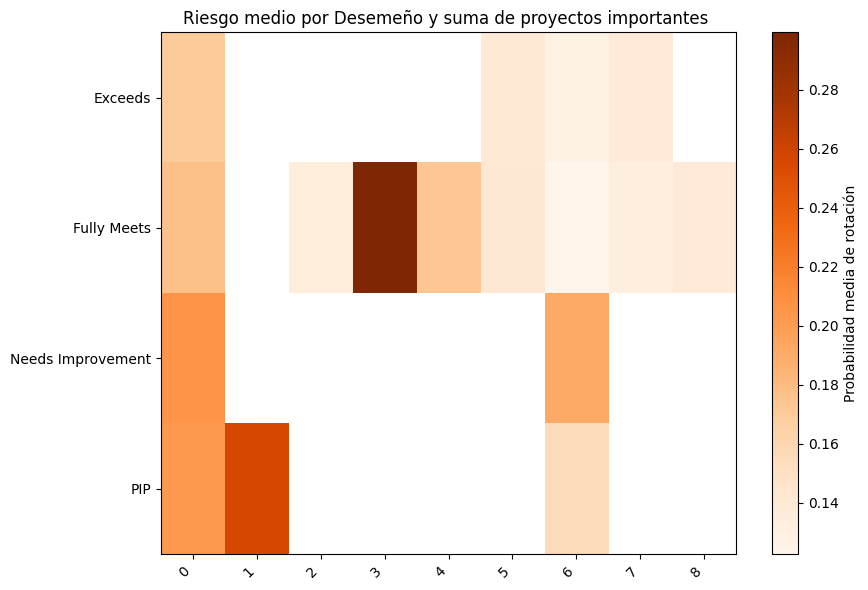

In [ ]:
# Mapa de color del riesgo medio por demepleño y suma de proyectos
tabla = (hrdataset_activos
         .groupby(["PerformanceScore", "SpecialProjectsCount"])["proba_rotacion"]
         .mean()
         .unstack())  # filas=Dept, columnas=Manager

plt.figure(figsize=(9,6))
plt.imshow(tabla.values, aspect="auto", origin="upper", cmap="Oranges")  # también vale pcolormesh con índices
cbar = plt.colorbar()
cbar.set_label("Probabilidad media de rotación")

plt.yticks(range(len(tabla.index)), tabla.index)
plt.xticks(range(len(tabla.columns)), tabla.columns, rotation=45, ha="right")
plt.title("Riesgo medio por Desemeño y suma de proyectos importantes ")
plt.tight_layout()
plt.show()

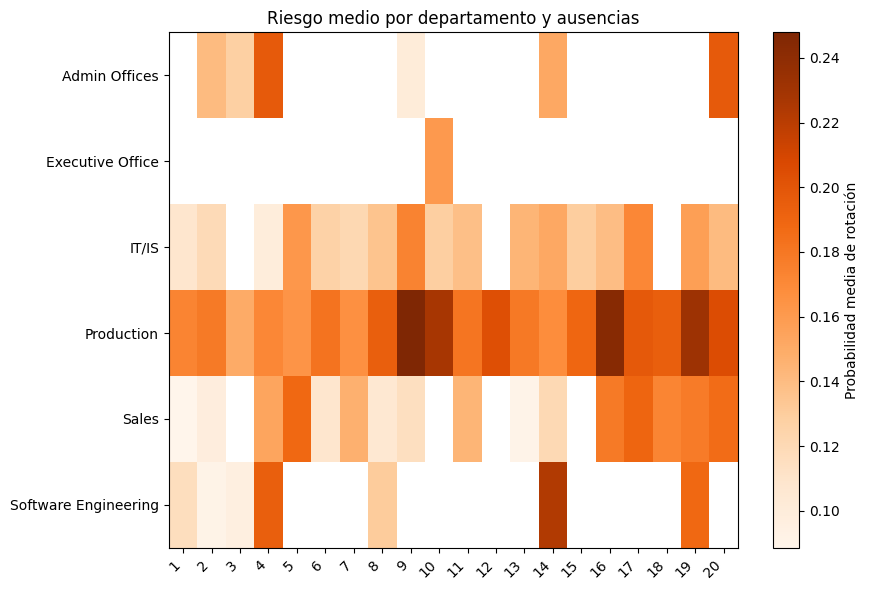

In [ ]:
# Mapa de color del riesgo medio por departamento y ausencias

tabla = (hrdataset_activos
         .groupby(["Department", "Absences"])["proba_rotacion"]
         .mean()
         .unstack())  # filas=Dept, columnas=Manager

plt.figure(figsize=(9,6))
plt.imshow(tabla.values, aspect="auto", origin="upper", cmap="Oranges")  # también vale pcolormesh con índices
cbar = plt.colorbar()
cbar.set_label("Probabilidad media de rotación")

plt.yticks(range(len(tabla.index)), tabla.index)
plt.xticks(range(len(tabla.columns)), tabla.columns, rotation=45, ha="right")
plt.title("Riesgo medio por departamento y ausencias")
plt.tight_layout()
plt.show()

# Predicción del salario: inversión futura que puede tener la empresa


In [ ]:
# =============== Regresion logística ============================

In [ ]:
# SELECCIÓN DE VARIABLES

target = "Salary"  # variable a predecir
num_features = ["Edad","Antiguedad","EngagementSurvey","EmpSatisfaction",
                "SpecialProjectsCount","Absences"]
cat_features = ["Department_sinExec","RecruitmentSource","PerformanceScore"]

X = hrdataset[num_features + cat_features]  # predictores
y = hrdataset[target]  # objetivo (salario)

In [ ]:
# PREPROCESAMIENTO
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),  # rellena faltantes numéricos
    ("scaler", StandardScaler())  # estandariza variables numéricas
])
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),  # rellena faltantes categóricos
    ("onehot", OneHotEncoder(handle_unknown="ignore"))  # convierte a dummies
])
preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_features),
        ("cat", categorical_transformer, cat_features)
    ]
)


In [ ]:
#MODELO

lin_reg = Pipeline(steps=[
    ("preprocess", preprocess),  # aplica transformaciones
    ("model", LinearRegression())  # aplica regresión lineal
])

#  TRAIN/TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# ENTRENAMIENTO
lin_reg.fit(X_train, y_train)  # ajusta el modelo

#  PREDICCIONES
y_pred = lin_reg.predict(X_test)  # predicciones sobre test


In [ ]:
mae = mean_absolute_error(y_test, y_pred)  # error absoluto medio
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)  # raíz error cuadrático medio
r2 = r2_score(y_test, y_pred)  # R² (capacidad explicativa)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 12834.023066537036
RMSE: 20536.574243523137
R²: 0.3916507374421049


MAE: 12.834 € → el error promedio en predicciones de salario.

RMSE: 20536 € → error más sensible a outliers (empleados con sueldos extremos).

R²: 0.39 → el modelo lineal solo explica un 39% de la variabilidad en salarios

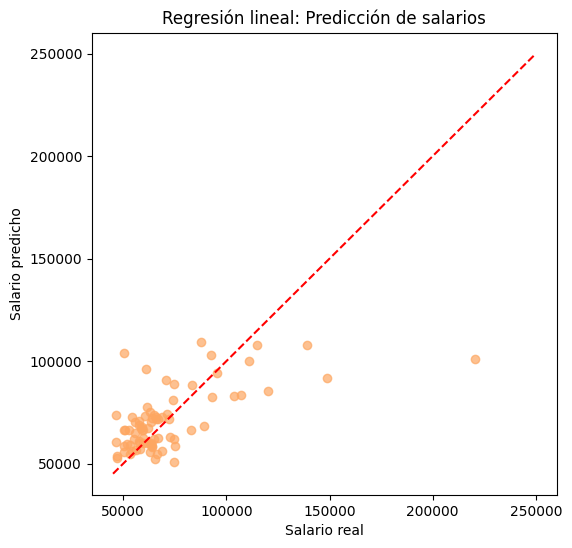

In [ ]:

# VISUALIZACIÓN
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y.min(), y.max()], [y.min(), y.max()], "r--")  # línea identidad
plt.xlabel("Salario real")
plt.ylabel("Salario predicho")
plt.title("Regresión lineal: Predicción de salarios")
plt.show()


In [ ]:
# ================= Gradient Boosting Regressor ==================

In [ ]:
# MODELO

gbr = Pipeline(steps=[  # pipeline completo con preprocesado y modelo final
    ("prep", preprocess),  # primer paso: imputación, escalado, one-hot
    ("model", GradientBoostingRegressor(  # segundo paso: gradient boosting
        n_estimators=500,        # número de árboles aditivos totales
        learning_rate=0.05,      # tamaño de paso por iteración
        max_depth=3,             # profundidad máxima de árboles base
        subsample=0.8,           # usa fracción de muestras por iteración
        random_state=42          # semilla fija para reproducibilidad estable
    ))
])

In [ ]:
# ENTRENAMIENTO
gbr.fit(X_train, y_train)  # ajusta el pipeline completo con datos entrenamiento

# PREDICCIÓN Y MÉTRICAS
y_pred = gbr.predict(X_test)  # predice salarios para conjunto de prueba
mae = mean_absolute_error(y_test, y_pred)  # error absoluto medio en moneda
mse = mean_squared_error(y_test, y_pred)  # error cuadrático medio sin raíz todavía
rmse = np.sqrt(mse)  # raíz del MSE para escala comparable a salario
r2 = r2_score(y_test, y_pred)  # proporción de varianza explicada por el modelo

print(f"MAE: {mae:.1f}")  # imprime error medio absoluto redondeado
print(f"RMSE: {rmse:.1f}")  # imprime raíz error cuadrático medio redondeado
print(f"R²: {r2:.3f}")  # imprime R-cuadrado con tres decimales


MAE: 12273.6
RMSE: 20793.1
R²: 0.376


In [ ]:
# Recuperar nombres de columnas tras one-hot para interpretar importancias

feature_names = gbr.named_steps["prep"].get_feature_names_out()  # nombres post-transformación
importances = gbr.named_steps["model"].feature_importances_  # importancias del boosting entrenado
imp_df = pd.DataFrame({"feature": feature_names, "importance": importances})  # tabla importancias
imp_df = imp_df.sort_values("importance", ascending=False).head(15)  # top quince importantes
print("\nTop 15 importancias:\n", imp_df.to_string(index=False))  # muestra tabla legible


Top 15 importancias:
                                      feature  importance
                                   num__Edad    0.213362
                             num__Antiguedad    0.187726
                       num__EngagementSurvey    0.106560
                   num__SpecialProjectsCount    0.101150
          cat__Department_sinExec_Production    0.082240
                               num__Absences    0.075138
               cat__RecruitmentSource_Indeed    0.049134
               cat__Department_sinExec_IT/IS    0.034515
                        num__EmpSatisfaction    0.033457
     cat__PerformanceScore_Needs Improvement    0.026899
       cat__Department_sinExec_Admin Offices    0.013995
cat__Department_sinExec_Software Engineering    0.010597
               cat__Department_sinExec_Sales    0.010545
        cat__RecruitmentSource_Google Search    0.009289
               cat__PerformanceScore_Exceeds    0.008668


La edad y la antiguedad estan muy ligadas a una retribución económica alta    
Por otro lado, la encuesta de compromiso y la dedicacion a proyectos especiales tambien.      
Se puede pensar que cuando se tiene un mayor salario mas fuerte es tu compromiso porque sientes que tu desempeño esta valorado a nivel economico.     
También se puede analizar que la empresa tiene una politica retributiva en base a la cantidad de proyectos de los que se es responsable.      

En términos departamentales, se observa que Producción, al concentrar el mayor número de empleados, representa una parte importante de la masa salarial de la compañía.      

Finalmente, el análisis sugiere una relación entre ausentismo y nivel salarial, dado que no todas las ausencias se remuneran, lo que introduce un componente adicional de gestión en la compensación.


# Desempeño: ¿Quién promociona?

In [ ]:
# 1. Definir X e y
X = hrdataset[['Salary', 'EngagementSurvey', 'EmpSatisfaction',
               'Absences', 'SpecialProjectsCount', 'Antiguedad']]
y = hrdataset['PerfScoreID']

# 2. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# 3. Entrenar modelo
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

# 4. Evaluación
y_pred = rf.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

# 5. Importancia de variables
importances = pd.Series(rf.feature_importances_, index=X.columns)
print(importances.sort_values(ascending=False))

[[ 1  2  0  0]
 [ 1  1  3  0]
 [ 0  0 61  0]
 [ 0  0  8  1]]
              precision    recall  f1-score   support

           1       0.50      0.33      0.40         3
           2       0.33      0.20      0.25         5
           3       0.85      1.00      0.92        61
           4       1.00      0.11      0.20         9

    accuracy                           0.82        78
   macro avg       0.67      0.41      0.44        78
weighted avg       0.82      0.82      0.77        78

EngagementSurvey        0.367188
Salary                  0.209949
Absences                0.157123
Antiguedad              0.126677
EmpSatisfaction         0.111763
SpecialProjectsCount    0.027301
dtype: float64


In [ ]:
target_col = "PerfScoreID"

# Selección de variables (ajusta a tus columnas reales)
base_num_cols = ['Salary','EngagementSurvey','EmpSatisfaction','Absences',
                 'SpecialProjectsCount','Antiguedad','DaysLateLast30','TrainingTimesLastYear']
base_cat_cols = ['Department','Position','Gender','MaritalStatus','EmploymentStatus']

# Filtra columnas que existan
num_cols = [c for c in base_num_cols if c in hrdataset.columns]
cat_cols = [c for c in base_cat_cols if c in hrdataset.columns]

# Quita filas con y nulo y asegura tipo int
df = hrdataset.dropna(subset=[target_col]).copy()
df[target_col] = df[target_col].astype(int)

X = df[num_cols + cat_cols]
y = df[target_col]

# Train/Test estratificado (muy recomendable en ordinal multiclase)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Preprocesadores
num_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

# OneHotEncoder con salida densa para que 'mord' no se queje de matrices dispersas
cat_transformer = Pipeline(steps=[
    ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", num_transformer, num_cols),
        ("cat", cat_transformer, cat_cols)
    ],
    remainder="drop"
)

# Utilidades de evaluación
def eval_ordinal(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    kappa_q = cohen_kappa_score(y_true, y_pred, weights='quadratic')
    acc_exact = (y_true == y_pred).mean()
    acc_plusminus1 = (np.abs(y_true - y_pred) <= 1).mean()
    rho, _ = spearmanr(y_true, y_pred)
    return {
        "MAE": mae,
        "QWK (kappa cuadrático)": kappa_q,
        "Exactitud": acc_exact,
        "Exactitud ±1 nivel": acc_plusminus1,
        "Spearman ρ": rho
    }

def imprimir_matriz_confusion(y_true, y_pred):
    labels = sorted(np.unique(np.concatenate([y_true, y_pred])))
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    cm_df = pd.DataFrame(cm, index=[f"Real {l}" for l in labels], columns=[f"Pred {l}" for l in labels])
    return cm_df

In [ ]:
# Pipeline: preprocesado + modelo ordinal
ord_model = Pipeline(steps=[
    ("prep", preprocess),
    ("clf", mord.LogisticIT(alpha=1.0))  # alpha regula regularización L2
])

ord_model.fit(X_train, y_train)
y_pred_ord = ord_model.predict(X_test)

# Evaluación
res_ord = eval_ordinal(y_test.to_numpy(), y_pred_ord)
cm_ord = imprimir_matriz_confusion(y_test.to_numpy(), y_pred_ord)

print("=== Ordinal Logistic Regression (mord.LogisticIT) ===")
for k,v in res_ord.items():
    print(f"{k}: {v:.4f}")
print("\nMatriz de confusión:")
print(cm_ord)

=== Ordinal Logistic Regression (mord.LogisticIT) ===
MAE: 0.1667
QWK (kappa cuadrático): 0.7081
Exactitud: 0.8333
Exactitud ±1 nivel: 1.0000
Spearman ρ: 0.6682

Matriz de confusión:
        Pred 1  Pred 2  Pred 3  Pred 4
Real 1       2       1       0       0
Real 2       2       1       2       0
Real 3       0       0      61       0
Real 4       0       0       8       1


MAE = 0.1667 → en promedio el modelo se equivoca menos de 0.2 puntos de nivel, muy bajo.

QWK = 0.7081 → Kappa cuadrático es bastante bueno (valores >0.7 se consideran “fuertes”).

Exactitud = 83.3% → acierta exactamente el nivel en 8 de cada 10 casos.

Exactitud ±1 nivel = 100% → nunca predice un nivel que esté a más de 1 de distancia del real (ejemplo: nunca confunde un “PIP” con un “Exceeds”).

Spearman ρ = 0.6682 → correlación de orden buena entre predicho y real.

In [ ]:
# Pipeline Random Forest
rf_reg = Pipeline(steps=[
    ("prep", preprocess),
    ("reg", RandomForestRegressor(
        n_estimators=400,
        max_depth=None,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ))
])

rf_reg.fit(X_train, y_train)
y_pred_cont = rf_reg.predict(X_test)

# Redondeo y recorte a [1,4] (ajusta si tu escala es distinta)
y_pred_rf = np.rint(y_pred_cont).astype(int)
y_pred_rf = np.clip(y_pred_rf, y_train.min(), y_train.max())

# Evaluación
res_rf = eval_ordinal(y_test.to_numpy(), y_pred_rf)
cm_rf = imprimir_matriz_confusion(y_test.to_numpy(), y_pred_rf)

print("=== Random Forest Regressor + redondeo ===")
for k,v in res_rf.items():
    print(f"{k}: {v:.4f}")
print("\nMatriz de confusión:")
print(cm_rf)

=== Random Forest Regressor + redondeo ===
MAE: 0.1538
QWK (kappa cuadrático): 0.6628
Exactitud: 0.8462
Exactitud ±1 nivel: 1.0000
Spearman ρ: 0.7256

Matriz de confusión:
        Pred 1  Pred 2  Pred 3  Pred 4
Real 1       0       3       0       0
Real 2       0       5       0       0
Real 3       0       1      60       0
Real 4       0       0       8       1


Random Forest es un poco mejor en MAE, exactitud y Spearman (correlación de orden).
Hay un sesgo de frecuancia en la cual todos los predice en la clase 3

In [ ]:
# Extractor de nombres finales de columnas tras el ColumnTransformer
def get_feature_names(ct: ColumnTransformer):
    out = []
    for name, trans, cols in ct.transformers_:
        if name == 'remainder' and trans == 'drop':
            continue
        if hasattr(trans, 'named_steps'):
            last = list(trans.named_steps.values())[-1]
        else:
            last = trans
        if hasattr(last, 'get_feature_names_out'):
            out.extend(last.get_feature_names_out(cols))
        else:
            out.extend(cols)
    return out

rf_fitted = rf_reg.named_steps['reg']
feat_names = get_feature_names(rf_reg.named_steps['prep'])
importances = pd.Series(rf_fitted.feature_importances_, index=feat_names).sort_values(ascending=False)
print(importances.head(20))

DaysLateLast30                             0.644167
EngagementSurvey                           0.110786
Salary                                     0.079480
Absences                                   0.061272
Antiguedad                                 0.039161
EmpSatisfaction                            0.032016
Position_Production Technician II          0.006328
Position_Production Technician I           0.005438
Department_Production                      0.005077
Position_Production Manager                0.003948
EmploymentStatus_Voluntarily Terminated    0.002663
SpecialProjectsCount                       0.002491
Department_Sales                           0.001369
Department_IT/IS                           0.001347
EmploymentStatus_Active                    0.001187
Position_Area Sales Manager                0.001023
Position_Data Analyst                      0.000971
EmploymentStatus_Terminated for Cause      0.000704
Position_IT Support                        0.000254
Position_Sof

DaysLateLast30 (0.64) → con diferencia, la variable más influyente (≈64% del peso).
Esto indica que la puntualidad (o retrasos en el último mes) tiene un impacto enorme en la predicción del desempeño.
Como ya hemos visto con anterioridad hay mucha correlación entre ausencias/tardanzas y performance en el dataset.

EngagementSurvey (compromiso) segundo factor más relevante, coherente: empleados más comprometidos tienden a mejor desempeño

Conclusiones:

El modelo depende fuertemente de una sola variable (DaysLateLast30).

Eso puede generar un riesgo de sobreajuste: si esa variable cambia en el futuro (ej. política de fichajes distinta), el modelo perdería potencia.


### ¿Qué pasa si quitamos la variable DaysLateLast30 del modelo?

In [ ]:
# definir columnas numéricas base SIN 'DaysLateLast30'
base_num_cols_2 = [
    'Salary','EngagementSurvey','EmpSatisfaction','Absences',
    'SpecialProjectsCount','Antiguedad','TrainingTimesLastYear'
]

base_cat_cols_2 = ['Department','Position','Gender','MaritalStatus','EmploymentStatus']

# Filtra columnas que existan en tu dataset
num_cols_2 = [c for c in base_num_cols_2 if c in hrdataset.columns]
cat_cols_2 = [c for c in base_cat_cols_2 if c in hrdataset.columns]

# Dataset limpio tirando del dataset de activos
desempsataset = hrdataset_activos.dropna(subset=[target_col]).copy()
desempsataset[target_col] = desempsataset[target_col].astype(int)

X = desempsataset[num_cols_2 + cat_cols_2]
y = desempsataset[target_col]

# Split train/test estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

In [ ]:

# 7) Preprocesamiento
num_transformer = Pipeline([("scaler", StandardScaler())])
cat_transformer = Pipeline([("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False))])

preprocess = ColumnTransformer(
    transformers=[
        ("num", num_transformer, [c for c in num_cols_2 if c in X.columns]),
        ("cat", cat_transformer, [c for c in cat_cols_2 if c in X.columns]),
    ],
    remainder="drop"
)

In [ ]:
# Modelo ordinal de regresion logistica

ord_model = Pipeline(steps=[
    ("prep", preprocess),
    ("clf", mord.LogisticIT(alpha=1.0))
])

ord_model.fit(X_train, y_train)
y_pred_ord = ord_model.predict(X_test)

print("=== Ordinal Logistic Regression (sin DaysLateLast30) ===")
res_ord = eval_ordinal(y_test.to_numpy(), y_pred_ord)
for k,v in res_ord.items():
    print(f"{k}: {v:.4f}")

print("\nMatriz de confusión:")
print(imprimir_matriz_confusion(y_test.to_numpy(), y_pred_ord))

=== Ordinal Logistic Regression (sin DaysLateLast30) ===
MAE: 0.2115
QWK (kappa cuadrático): 0.3832
Exactitud: 0.8077
Exactitud ±1 nivel: 0.9808
Spearman ρ: 0.3274

Matriz de confusión:
        Pred 1  Pred 2  Pred 3  Pred 4
Real 1       1       0       1       0
Real 2       0       0       2       0
Real 3       0       0      41       0
Real 4       0       0       7       0


In [ ]:
# Modelo de randomForest

rf_reg = Pipeline(steps=[
    ("prep", preprocess),
    ("reg", RandomForestRegressor(
        n_estimators=400,
        max_depth=None,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ))
])

rf_reg.fit(X_train, y_train)
y_pred_cont = rf_reg.predict(X_test)

# Redondeo + clip
y_pred_rf = np.rint(y_pred_cont).astype(int)
y_pred_rf = np.clip(y_pred_rf, y_train.min(), y_train.max())

print("=== Random Forest Regressor + redondeo (sin DaysLateLast30) ===")
res_rf = eval_ordinal(y_test.to_numpy(), y_pred_rf)
for k,v in res_rf.items():
    print(f"{k}: {v:.4f}")

print("\nMatriz de confusión:")
print(imprimir_matriz_confusion(y_test.to_numpy(), y_pred_rf))

=== Random Forest Regressor + redondeo (sin DaysLateLast30) ===
MAE: 0.2115
QWK (kappa cuadrático): 0.4367
Exactitud: 0.8077
Exactitud ±1 nivel: 0.9808
Spearman ρ: 0.3522

Matriz de confusión:
        Pred 1  Pred 2  Pred 3  Pred 4
Real 1       1       0       1       0
Real 2       0       1       1       0
Real 3       0       0      40       1
Real 4       0       0       7       0


## Predicciones por empleado

In [ ]:
#usar modeloo ordinal
desempsataset["Pred_Ordinal"] = ord_model.predict(X)

# Usar el modelo RF Regressor (con redondeo y recorte)
y_pred_cont = rf_reg.predict(X)
desempsataset["Pred_RF"] = np.clip(np.rint(y_pred_cont).astype(int), y.min(), y.max())



In [ ]:
# Ahora df tiene tanto el real como las predicciones
predicciones = desempsataset[[target_col, "Pred_Ordinal", "Pred_RF"]]
predicciones.head(10)

,PerfScoreID,Pred_Ordinal,Pred_RF
0,4,3,4
3,3,4,3
5,4,3,3
6,3,3,3
7,3,3,3
8,3,3,3
9,3,3,3
12,4,3,3
13,3,3,3
16,4,3,3


In [ ]:
predicciones = desempsataset[["EmpID", target_col, "Pred_Ordinal", "Pred_RF"]]
print(predicciones.head())

   EmpID  PerfScoreID  Pred_Ordinal  Pred_RF
0  10026            4             3        4
3  10088            3             4        3
5  10002            4             3        3
6  10194            3             3        3
7  10062            3             3        3


Sigue tirando a la media


# 9 in box matrix

Dado que la evaluación de desempeño comenzó a aplicarse de manera masiva recién en el último año de este dataset, los resultados tienden a concentrarse en la media, lo que refleja la necesidad de contar con más datos, ampliar el rango de valores de la variable desempeño y repetir la medición de forma periódica. En este contexto, resulta clave complementar el análisis incorporando el nivel de compromiso como variable adicional.      
Por ello, se plantea realizar un mapeo de talento a través de la matriz Nine-in-Box, utilizando desempeño y compromiso como ejes.     Esta aproximación permitirá identificar no solo el rendimiento actual de los colaboradores, sino también su grado de vinculación con la organización, generando una visión más estratégica para la toma de decisiones de desarrollo, retención y sucesión.


Matriz 9-Box (conteo de empleados):
Perf_cat    Bajo  Medio  Alto
Engage_cat                   
Alto           3    136    29
Medio          2     26     0
Bajo          11      0     0


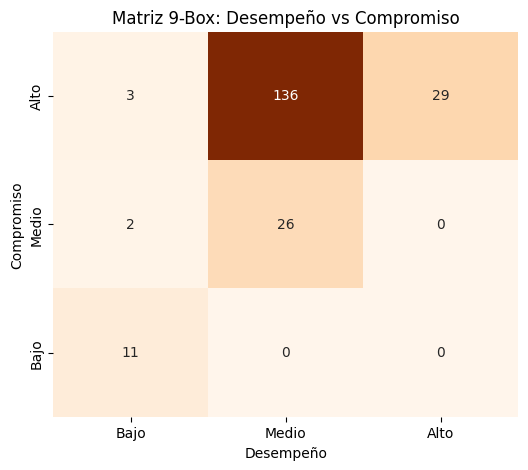

In [ ]:
# REALIZACION DE LA MATRIZ NINE-IN-BOX


# Categorizamos desempeño
hrdataset_activos["Perf_cat"] = pd.cut(hrdataset_activos["PerfScoreID"],
                        bins=[0, 2, 3.5, 5],
                        labels=["Bajo", "Medio", "Alto"],
                        include_lowest=True)

# Categorizamos compromiso
hrdataset_activos["Engage_cat"] = pd.cut(hrdataset["EngagementSurvey"],
                          bins=[0, 2.5, 3.5, 5],
                          labels=["Bajo", "Medio", "Alto"],
                          include_lowest=True)

# Reordenamos para que alto aparezca el primero
hrdataset_activos["Engage_cat"] = hrdataset_activos["Engage_cat"].cat.reorder_categories(
    ["Alto", "Medio", "Bajo"],
    ordered=True
)
# Tabla cruzada (Matriz 9-Box)
nine_box = pd.crosstab(hrdataset_activos["Engage_cat"], hrdataset_activos["Perf_cat"])

print("Matriz 9-Box (conteo de empleados):")
print(nine_box)

# ---- Heatmap visual ----
plt.figure(figsize=(6,5))
sns.heatmap(nine_box, annot=True, fmt="d", cmap="Oranges", cbar=False)
plt.title("Matriz 9-Box: Desempeño vs Compromiso")
plt.xlabel("Desempeño")
plt.ylabel("Compromiso")
plt.show()

La mayoría está en Compromiso Alto + Desempeño Medio → una base muy valiosa para desarrollar.

El talento estrella es el grupo de 29 personas en la esquina superior derecha.

El foco de riesgo son los 11 en Bajo-Bajo.

#Ausentismo: Patrones de ausencias (estacionalidad, departamentos más afectados)

Análisis y predicción de ¿? necesidades de contratacion (no hay formacion ni si se esta actualizando el conocimiento de los trabajadores)
Añadir tu datos aleatorios, en una columna para poder hacer el estudio¿?

## Modelos lineales

In [ ]:
#### MODELO RANDOM FOREST REGRESSOR

# Seleccion de variables
X = hrdataset[["EngagementSurvey", "EmpSatisfaction", "Salary",
               "Antiguedad", "SpecialProjectsCount",
               "DaysLateLast30", "PerfScoreID",
               "GenderID", "MarriedID",
               "DeptID"]]  # predictores
y = hrdataset["Absences"]  # número de días de ausencia

# División train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Entrenar el modelo RandomForest
rf_reg = RandomForestRegressor(n_estimators=200, random_state=42)
rf_reg.fit(X_train, y_train)

# Predicciones
y_pred = rf_reg.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))



MAE: 5.952884615384614
R²: -0.23084968678356477


In [ ]:
### MODELO REGRESION LINEAL

#  Entrenar modelo
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

# Predicciones
y_pred = lin_reg.predict(X_test)

# Métricas
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("R²:", r2)

# Coeficientes
coef_df = pd.DataFrame({
    "Variable": X.columns,
    "Coeficiente": lin_reg.coef_
})
print(coef_df)
print("Intercepto:", lin_reg.intercept_)

MAE: 5.765385923440325
R²: -0.13435282133358806
               Variable  Coeficiente
0      EngagementSurvey    -0.786605
1       EmpSatisfaction     0.238701
2                Salary     0.000039
3            Antiguedad    -0.143417
4  SpecialProjectsCount     0.180513
5        DaysLateLast30     0.013165
6           PerfScoreID     0.837827
7              GenderID     0.289829
8             MarriedID     1.444963
9                DeptID     1.175972
Intercepto: 1.964347183712448


Tus datos muestran que la linealidad no es suficiente para explicar el ausentismo.

El modelo está aprendiendo poco más que la media, lo que confirma que las variables incluidas no predicen bien.    
Vamos a cambiar la categorizacion de la variable objetivo

## Modelos de clasificación

In [ ]:
# Creamos la nueva variable categórica por cuartiles

hrdataset['Absentismo_clas'] = pd.qcut(hrdataset['Absences'], q=4, labels=[0,1,2,3])


Con codificacion de la variable nos daba un Accuracy = 0.23 (23%)
El modelo está prediciendo apenas un poco mejor que el azar (siendo 4 clases, el azar rondaría el 25%).

In [ ]:
# Creamos una variable binaria usando la mediana como umbral

umbral = hrdataset['Absences'].median()
hrdataset['Absentismo_bin'] = (hrdataset['Absences'] > umbral).astype(int)

Accuracy = 0.47 (47%) cuya mediana son 10 día de ausentismo.

Apenas mejor que tirar una moneda (50%). El modelo todavía no logra separar bien alto vs bajo ausentismo.

Vamos a hacer una ultima clasificacion de la variable tomando en cuenta una gestión operativo de personas: el impacto que tiene faltar una semana o mas de una semana.

- menos o igual que 5 días (1 semana): Suele asociarse a enfermedades leves, permisos médicos breves o ausencias puntuales.
Se considera “aceptable” dentro de la dinámica normal de la empresa.

- más 5 días: Indica un patrón de ausentismo relevante, que ya puede afectar la productividad, la planificación de equipos y los costes.

En muchos convenios y métricas de RRHH, más de una semana de ausencias acumuladas al año se clasifica como alto ausentismo.


In [ ]:
# Creamos la variable con la separacion binaria de 5 días
hrdataset['Absentismo_bin5'] = (hrdataset['Absences'] > 5).astype(int)

Volvemos a aplicar los modelos predictivos

In [ ]:
#### MODELO RANDOM FOREST CLASSIFIER


# definición de variables
num_features_abs = [
    "Salary","EngagementSurvey","EmpSatisfaction",
    "DaysLateLast30","Edad","Antiguedad",
    "SpecialProjectsCount", "MarriedID", "GenderID"
]
cat_features_abs = [
    "RecruitmentSource","Department","PositionGroup", "PerformanceScore",
]


X = hrdataset[num_features_abs + cat_features_abs].copy()
y = hrdataset["Absentismo_bin5"].astype(int)

# Preprocesado: imputación y codificación

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])
preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_features_abs),
        ("cat", categorical_transformer, cat_features_abs),
    ],
    remainder="drop"
)

In [ ]:
# Modelo: RandomForest dentro de un Pipeline

clf = Pipeline(steps=[
    ("prep", preprocess),
    ("clf", RandomForestClassifier(
        n_estimators=500,
        max_depth=15,
        min_samples_split=20,
        min_samples_leaf=10,
        max_features="sqrt",
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

=== Métricas Random Forest ===
Accuracy:  0.6154
Precision: 0.7407
Recall:    0.7143
F1:        0.7273
ROC AUC:   0.5933


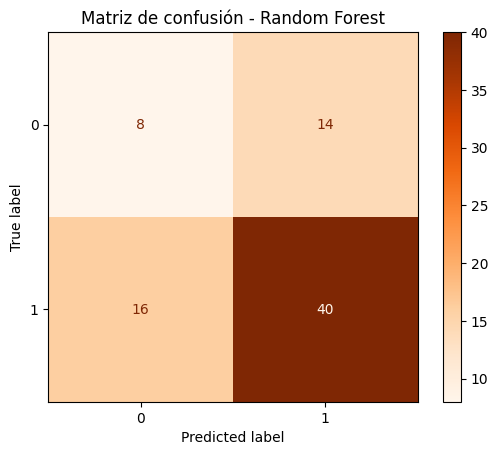

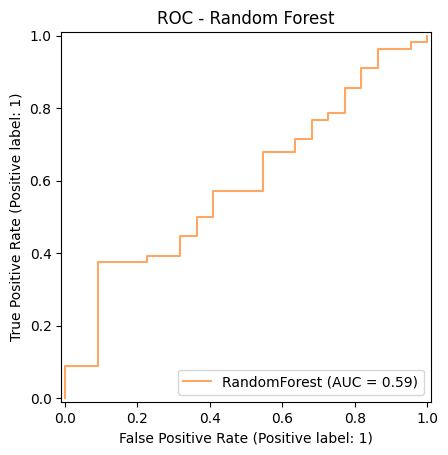

In [ ]:
#  Train/Test split (estratificado)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Entrenamiento
clf.fit(X_train, y_train)

# Predicciones y métricas
y_pred = clf.predict(X_test)
pos_idx = list(clf.named_steps["clf"].classes_).index(1)
y_proba = clf.predict_proba(X_test)[:, pos_idx]

print("=== Métricas Random Forest ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred, zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred, zero_division=0):.4f}")
print(f"F1:        {f1_score(y_test, y_pred, zero_division=0):.4f}")
print(f"ROC AUC:   {roc_auc_score(y_test, y_proba):.4f}")

# Matriz de confusión
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Oranges")
plt.title("Matriz de confusión - Random Forest")
plt.show()

# Curva ROC
RocCurveDisplay.from_predictions(y_test, y_proba, name="RandomForest")
plt.title("ROC - Random Forest")
plt.show()


# Importancias
# Importancia por permutación (interpretable en el espacio original)
perm = permutation_importance(
    clf, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1, scoring="roc_auc"
)
# mapear nombres transformados para mostrar también importancias del modelo
ohe = clf.named_steps["prep"].named_transformers_["cat"].named_steps["onehot"]
cat_out = list(ohe.get_feature_names_out(cat_features_abs))
feat_names_transformed = num_features_abs + cat_out

# Importancias del modelo (feature_importances_ en el espacio transformado)
fi = clf.named_steps["clf"].feature_importances_
fi_df = (pd.DataFrame({"feature": feat_names_transformed, "importance": fi})
         .sort_values("importance", ascending=False))

Con un accuracy del 61% nos muestra que el modelo ya logra clasificar mejor las ausencias.     
El modelo casi nunca falla en identificar a los de alto ausentismo (casos críticos)
Pero confunde casi todos los de bajo ausentismo con alto.    
Desde la óptica de gestión de riesgos, esto puede ser aceptable: prefierimos detectar de más (falsos positivos) que dejar pasar empleados con alto ausentismo (falsos negativos).

### Estimación de la probabilidad de absentismo

   EmpID  Prob_AltoAusentismo
0  10026             0.423344
3  10088             0.622132
5  10002             0.480860
6  10194             0.492307
7  10062             0.488827
Archivo guardado: prob_alto_ausentismo_activos.xlsx


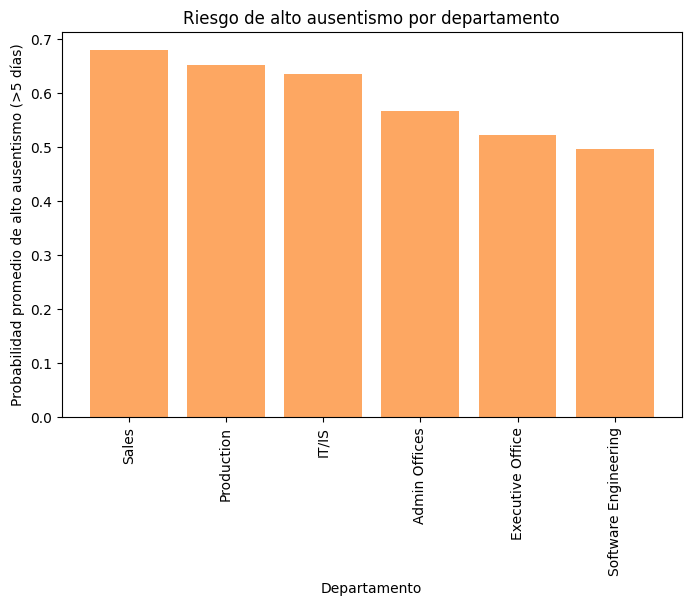

In [ ]:
# Seleccionamos las mismas features
X_activos = hrdataset_activos[num_features_abs + cat_features_abs]

pos_idx = list(clf.named_steps["clf"].classes_).index(1)  # índice clase "alto ausentismo"
hrdataset_activos["Prob_AltoAusentismo"] = clf.predict_proba(X_activos)[:, pos_idx]

# === 4) Revisar resultados ===
print(hrdataset_activos[["EmpID", "Prob_AltoAusentismo"]].head())

# Ordenar por mayor riesgo
hrdataset_activos = hrdataset_activos.sort_values("Prob_AltoAusentismo", ascending=False)

# Gráfico opcional
import matplotlib.pyplot as plt  # librería para graficar
plt.figure(figsize=(8,5))  # tamaño del lienzo
plt.bar(hrdataset_activos["Department"].astype(str), hrdataset_activos["Prob_AltoAusentismo"])  # barras
plt.xlabel("Departamento")  # etiqueta eje X
plt.ylabel("Probabilidad promedio de alto ausentismo (>5 días)")  # eje Y
plt.title("Riesgo de alto ausentismo por departamento")  # título
plt.xticks(rotation=90)  # rotar etiquetas
plt.show()  # mostrar gráfico

Todas las áreas superan el 0.5, lo que indica un riesgo considerable en general. Sales encabeza la lista con la mayor probabilidad, seguida de IT/IS y Executive Office, que también presentan niveles elevados. Production se sitúa en un nivel intermedio, aunque todavía alto, mientras que Software Engineering y Admin Offices destacan con los valores más bajos.

El ausentismo parece estar determinado por factores no capturados en los datos (ejemplo: salud, conciliación, cultura laboral).


### Matriz de riesgos por departamento

     Department_sinExec  Prob_AltoAusentismo  proba_rotacion
0         Admin Offices             0.542787        0.148952
1                 IT/IS             0.504438        0.136105
2            Production             0.514624        0.185769
3                 Sales             0.513238        0.151615
4  Software Engineering             0.473474        0.148592


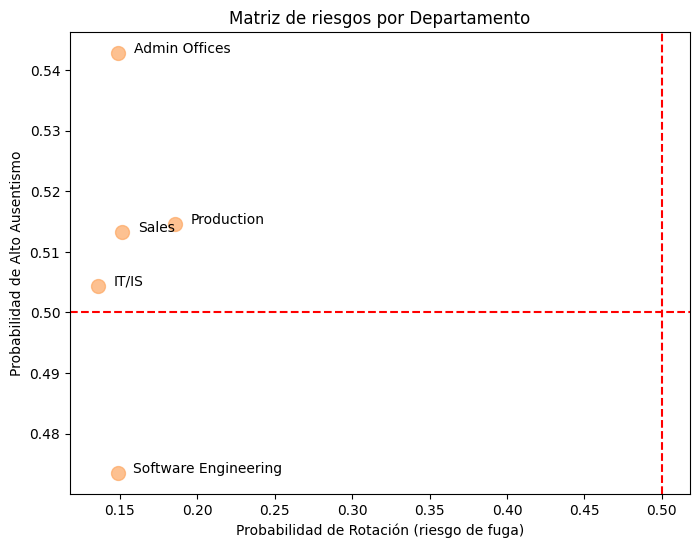

In [ ]:

# Obtener probabilidades individuales
hrdataset_activos["Prob_AltoAusentismo"] = clf.predict_proba(X_activos)[:,1]

# Calcular promedios por departamento
dept_risk = hrdataset_activos.groupby("Department_sinExec")[["Prob_AltoAusentismo", "proba_rotacion"]].mean().reset_index()

print(dept_risk)

# Scatter plot: matriz de riesgos
plt.figure(figsize=(8,6))
plt.scatter(dept_risk["proba_rotacion"], dept_risk["Prob_AltoAusentismo"], s=100, alpha=0.7)

# Etiquetas de cada departamento
for i, row in dept_risk.iterrows():
    plt.text(row["proba_rotacion"]+0.01, row["Prob_AltoAusentismo"], str(row["Department_sinExec"]))

# Líneas de referencia (ej: 0.5 como umbral de riesgo)
plt.axhline(0.5, color="red", linestyle="--")
plt.axvline(0.5, color="red", linestyle="--")

plt.xlabel("Probabilidad de Rotación (riesgo de fuga)")
plt.ylabel("Probabilidad de Alto Ausentismo")
plt.title("Matriz de riesgos por Departamento")
plt.show()

Ningún área supera simultáneamente el umbral crítico de 0.5 en ambos riesgos, lo que es positivo. Admin Offices presenta el ausentismo promedio más alto, aunque con baja rotación. Sales, Production e IT/IS están cerca del umbral de ausentismo, pero con rotación reducida. Software Engineering muestra los niveles más bajos en ambos indicadores, reflejando mayor estabilidad.